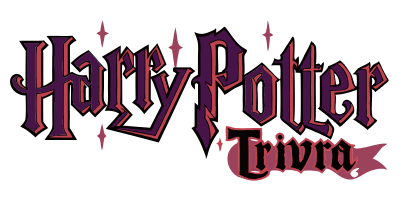

<div style="background-color: #f0e6f7; padding: 10px;">
    <h2 style="text-align:center; color:purple;">Harry Potter Trivia Game</h2>
    <h3 style="text-align:center; color:purple;">Data preparation and EDA</h3>
</div>

# 1. Introduction

Ready your wands! This project aims to conjure an engaging Harry Potter Trivia game. Before the magic can truly begin with the Phase 1 CLI-MVP, we must first understand the key ingredient - the trivia dataset. This notebook covers the foundational step of cleaning and performing Exploratory Data Analysis (EDA) on the public dataset that powers the game. The main objective here is to understand the data's characteristics and produce a clean, processed CSV file ready for the Phase 1 command-line interface (CLI) MVP; it will also inform subsequent NLP work in Phase 2.

A public dataset of trivia questions from Huggingface is used here. The dataset was downloaded using the `download_data.py` script, the train and test split were combined and stored as a single csv file from [saracandu/harry-potter-trivia-human](https://huggingface.co/datasets/saracandu/harry-potter-trivia-human/tree/main) on January 25, 2025. 

#### Workflow Summary

The main stages covered in this notebook include:
1. **Data Preparation:** Cleaning and preparing the raw trivia data (handling nulls, duplicates, types, feature selection).
2. **Basic Exploratory Data Analysis (EDA):** Initial analysis and visualization of the questions and answers in the cleaned dataset.
3. **Keyword Generation:** Tokenizing question and answer text using lemmatization to create keyword features.
3. **In-depth EDA:** Grandular analysis and visualization of the cleaned dataset with the generated keywords.
4. **Finalize dataset for CLI-MVP:** Create a clean dataset csv file that can be used in the phase-1, CLI-MVP version of the game.  Provide a basis for expanding the trivia question and answer dataset in future development phases.


# Table of Contents

1. [Introduction](#1-Introduction)<br>
2. [Glossary of key terms](#2-Glossary-of-key-terms)<br>
3. [Setup and imports](#3-Setup-and-imports)<br>
4. [Data preparation](#4-Data-preparation)<br>

**PART-1**: Basic EDA<br>

5. [Basic Exploratory Data Analysis (EDA)](#5-Basic-EDA-of-the-cleaned-dataset)<br>
    5.1. [Overview](#51-Overview)<br>
    5.2. [Answer lengths](#52-Answer-lengths)<br>
    5.3. [Question lengths](#53-Question-lengths)<br>
    5.4. [Question and answer length correlations](#54-question-and-answer-length-correlation)<br>

**PART-2**: Feature engineering<br>

6. [Keyword feature engineering](#6-Keyword-feature-engineering) <br>

**PART-3**: In-depth EDA based on question keywords and N-grams <br>

7. [EDA based on keywords](#7-EDA-based-on-keywords)<br> 
    7.1. [Unique keyword frequency](#71-unique-keyword-frequency) <br>
    7.2. [Factual recall questions](#72-factual-recall-questions)<br>
    7.3. [Questions that do not have factual recall keywords](#73-questions-that-do-not-have-factual-recall-keywords)<br>
    7.4. [Correlation summary: Q&A lengths by question keyword](#74-Corrleation-summary-qa-lengths-filtered-by-question-keyword)<br>
    7.5. [Common N-grams in the dataset](#75-Common-n-grams-in-the-dataset)<br>

8. [Content Similarity Analysis](#8-content-similarity-analysis)<br>
    8.1. [Question-Answer pariwise comparison](#81-question-answer-q-a-pairwise-comparison)<br>
    8.2. [Question-Question comparison](#82-question-question-q-q-comparison)<br>
    8.3. [Answer-Answer comparison](#83-answer-answer-a-a-comparison)<br>

9. [Feature Engineering based on in-depth EDA Findings](#9-Feature-engineering-from-in-depth-eda-findings)<br>
    9.1. [Dataset cleaning based on findings from the in-depth EDA](#91-Dataset-cleaning-based-on-findings-from-in-depth-eda)<br>
    9.2. [Add question type tags to the dataset](#92-Add-question-type-tags-to-dataset)<br>

**PART-4**: Quality assurance and finalization <br>

10. [Data quality assurance and finalization](#10-Data-quality-assurance-and-finalization)<br>
    10.1. [Automated heuristics](#101-Automated-heuristics)<br>
    10.2. [Manual review](#102-Manual-review)<br>
    10.3. [Status map of dataset](#103-Status-map-of-the-dataset)<br>

11. [Summary and key findings](#10-summmary-and-key-findings)<br>
    11.1. [Summary](#111-Summary)<br>
    11.2. [Key findings](#112-key-findings)<br>

**PART-5**: Dataset preparation for export to CLI-MVP<br> 

12. [Data dictionary](#12-Data-dictionary)<br>
13. [Next steps and data export](#13-Next-steps-and-data-export)<br>

# 2. Glossary of key terms

To ensure clarity and consistency, the following terms are defined within the context of this analysis:

|Term | Abbreviation | Description|
|-|-|-|
|Factual Recall (Question) | FR | Question seeking specific objective info (name, date, place, etc.). Identified by keywords such as 'What', 'Who', etc. |
| Open-Ended Question| OEQ| Question seeking explanation, opinion, or procedure, often identified by keywords like 'Why' or 'How'.|
| Not Applicable | N/A | Not Assigned / Not Applicable (in context). Used in columns like factual_recall_keyword to label questions not initially matched with a primary factual-recall keyword. These were subsequently analyzed as 'Non-Factual Recall' or other types.| 
| Question Type| QT | Classification assigned (e.g., Factual-Recall, Open-Ended) based primarily on keywords/phrasing, answer type |
| Question Keyword | QK | Lemmatized token from question text used for analysis/filtering (standard stopwords removed, interrogatives kept). |
| MVP of game| CLI-MVP | The first phase prototype of the Harry Potter Trivia game (Command Line Interface - Minimum Viable Product) |  

# 3. Setup and imports

Import the necessary external packages as well as internal project environment configuration and custom helper and utility methods from project modules.

In [1]:
# External libraries and packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import re
from collections import Counter, OrderedDict
from nltk import pos_tag
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from word2number import w2n
from pprint import pprint
import networkx as nx
from IPython.core.display import Markdown
from IPython.display import display

# Import the project environment configurations and load them.
import dotenv
dotenv.load_dotenv()  

# Import custom methods from project scripts
from utils import utils_paths as up
import eda_scripts as eda

<a href="#Table-of-Contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

# 4. Data preparation

To start, the dataset quality needs be to checked and addressed suitably. These involves checking the size of the dataset to make sure there are enough questions, as well as missing data (nulls) and duplicates. 

In [2]:
# convert csv file to dataframe
project_root = up.find_project_root()
rawcsv_path = project_root / "data" / "original_dataset_DONT_TOUCH"/"harry_potter_trivia_questions_HFdataset.csv"
raw_df = pd.read_csv(rawcsv_path)
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1279 entries, 0 to 1278
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  1279 non-null   object
 1   answer    1279 non-null   object
 2   text      1279 non-null   object
dtypes: object(3)
memory usage: 30.1+ KB


The dataset has 1279 rows and 3 columns. 

In [3]:
raw_df.sample(5)

,question,answer,text
896,Which Quidditch team only has female players?,Holyhead Harpies,<s>[INST] Which Quidditch team only has female...
558,Kneazles are most similar to what animal?,Cat,<s>[INST] Kneazles are most similar to what an...
397,Which of these is needed for successful broom ...,Balance,<s>[INST] Which of these is needed for success...
960,What did Professor Snape tell Harry could Deto...,Bezoar,<s>[INST] What did Professor Snape tell Harry ...
482,What was Gilderoy Lockhart's best Spell?,Obliviate,<s>[INST] What was Gilderoy Lockhart's best Sp...


The question and answers are in the first two columns. The third `text` column looks like it is the question and answers tokenized for LLM modelling.  Let's look a the full entry of the `text` column in the first row to see if it can be useful.

In [4]:
# Look at the contents of the first row, third column record (i.e. text column) without being clipped.
print(raw_df.iloc[0,2])  

<s>[INST] What are the three European wizarding schools that participate in the Triwizard Tournament? [/INST] Hogwarts, Beauxbatons, and Durmstrang. </s>


This confirms that the third column combines the question and answer with tokens for prompting an LLM model. It is not needed for this project, so the third column can be removed.

In [5]:
# Drop the `text` column:
raw_df = raw_df.drop(columns=['text'])
# Sanity check - confirm column has been dropped
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1279 entries, 0 to 1278
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  1279 non-null   object
 1   answer    1279 non-null   object
dtypes: object(2)
memory usage: 20.1+ KB


We can now check if there are any nulls in the dataset?

In [6]:
# Sanity check: 
raw_df.isna().sum()

question    0
answer      0
dtype: int64

Good news - no missing data. The next step is to check for duplicated rows.

In [7]:
# check for duplicates
raw_df.duplicated().sum()

np.int64(194)

There are 194 duplicates in the dataset. We can confirm this by taking a closer look at the rows and how many times they appear in the dataset and then delete them.

In [8]:
# Find duplicates based on all columns
duplicates = raw_df[raw_df.duplicated(keep=False)]
# Count occurrences of each duplicate row
duplicate_counts = duplicates.groupby(duplicates.columns.tolist()).size().reset_index(name='Count')
# Display the counts of each duplicate
print(duplicate_counts)

                                             question           answer  Count
0                       A Firebolt is a type of what?            Broom      5
1                         A Nimbus is a type of what?            Broom      5
2   According to Madam Hooch, which of the followi...        Long hair      5
3   Before Dumbledore, who was Headmaster of Hogwa...   Armando Dippet      2
4        Catching what object ends a Quidditch match?    Golden Snitch      5
..                                                ...              ...    ...
64  Who previously held Snape's post as Potions Ma...  Horace Slughorn      2
65                  Who previously held Snape's post?  Horace Slughorn      2
66  Who was the first witch or wizard to hatch a b...   Herpo the Foul      2
67        Why would you need to switch brooms midair?    Broom failure      5
68  You wouldn't know anything about this. Name a ...     Using polish      5

[69 rows x 3 columns]


So let's go ahead and delete the unnecessary duplicate rows.

In [9]:
trivia_df = raw_df.drop_duplicates(keep='first').reset_index(drop=True)
trivia_df.shape

(1085, 2)

After dropping the duplicates, we have 1085 unique questions and answer pairs in the dataset. A decent size for the MVP.
Finally, let's convert the `question` and `answer` columns to `str` for clarity, type safety, and make sure the `str` methods are available for them.

In [10]:
# convert columns from 'object` to `str`
trivia_df = trivia_df.astype({
    'question': 'string',
    'answer': 'string'})
print("\nData types after conversion:")
trivia_df.info()


Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1085 entries, 0 to 1084
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  1085 non-null   string
 1   answer    1085 non-null   string
dtypes: string(2)
memory usage: 17.1 KB


We can have a quick look at the state of the cleaned dataframe, save as a csv, and move on to exploration. 

In [11]:
trivia_df.head()

,question,answer
0,What are the three European wizarding schools ...,"Hogwarts, Beauxbatons, and Durmstrang."
1,When was Hogwarts founded?,10th century
2,What is a Wronski Feint?,Pretending to dive for the Snitch
3,You wouldn't know anything about this. Name a ...,Using polish
4,Harry first took the Knight Bus in The Prisone...,14 sickles.


---

#### 💾 Checkpoint 1: saving clean dataset
<details>
<summary> Click here for checkpoint details and <b>warning!</b> </summary>

The DataFrame is now cleaned and ready for EDA. Saving the current state.
<br>
> **⚠️ Caution: Manual Intervention Required for Saving Files**
>
> Please be aware that the `save_dataframe_to_csv` utility is designed to prevent accidental data loss. It **does not automatically overwrite** previously saved files.
>
> If you run a cell that calls this function and the output file (based on `filename_base`, `version`, and `subfolder`) already exists, the save operation will be skipped. You will see a message indicating this.
>
> **To save your latest data, you must manually intervene by either:**
> 1.  Deleting the older version of the CSV file from the file system.
> 2.  Modifying the `version` argument (or `filename_base`) in your function call to create a new, unique filename.

The following code saves the cleaned DataFrame to <code>data/project_datasets/</code> based on the selecte saved arguments.
</div>
</details>

In [12]:
# Using utils.paths.py module -> prevents overwritting csv file unless manually done.

# Save arguments
dataframe_to_save = trivia_df
name_for_csvfile = 'clean_trivia_dataset'
csv_version = 'v0'
csv_subfolder = 'project_datasets'

# Save csv  file with custom functions and defined save arguments
up.save_dataframe_to_csv(dataframe_to_save, name_for_csvfile, csv_version, csv_subfolder)

File already exists at: data/project_datasets/clean_trivia_dataset_v0.csv. Skipping save.


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

---

<div align="center" style="background-color: #f0e6f7; padding: 10px;">
    <span style="color:purple; font-size:32px;">Part-1: Basic Exploratory Data Analysis (EDA)</span>
</div>

# 5. Basic EDA of the cleaned dataset

We need to inspect and understand the dataset to decide whether it is suitable for the trivia game. Some questions we can  consider:
- Are there enough quality and diverse questions and answers?
- Does it cover a wide-enough range of Harry Potter content to make the game interesting?
- How verbose are the questions and answers? Are they grammatically correct and easy to understand?
- Are there various degrees of difficulty to the questions? 
- Could the length give an idea of the difficulty of the questions? What else?
- Do longer questions result in longer answers? 
- What type of questions are there? What about the answers? is categorization possible?
- Are there other patterns we can discern?

We can start the data exploration by looking at the questions and answer columns analytically. One characteristic they have in common is length (ie. word count). We can look at the descriptive statistics and distributions of the lengths. We can tokenize the words and look at question types and N-grams to get contextual understanding of the questions and answers. And we can also look at the relationship between questions and answers. 

## 5.1. What can we learn from the question and answer lengths?

In [13]:
# extract the length of each question and answer using the helper function from the eda_scripts module
question_lengths = eda.get_clean_word_counts(trivia_df, "question")
answer_lengths = eda.get_clean_word_counts(trivia_df, "answer")

length_analysis = pd.DataFrame({"question": question_lengths, "answer": answer_lengths}).describe()
print(length_analysis)

          question       answer
count  1085.000000  1085.000000
mean      9.851613     2.659908
std       4.326515     2.657494
min       3.000000     1.000000
25%       7.000000     1.000000
50%       9.000000     2.000000
75%      12.000000     3.000000
max      31.000000    25.000000


The answers are generally shorter then the questions. Most answers are about 1 to 3 words while most questoins are about 9 words. 

We can also look at the distributions visually.

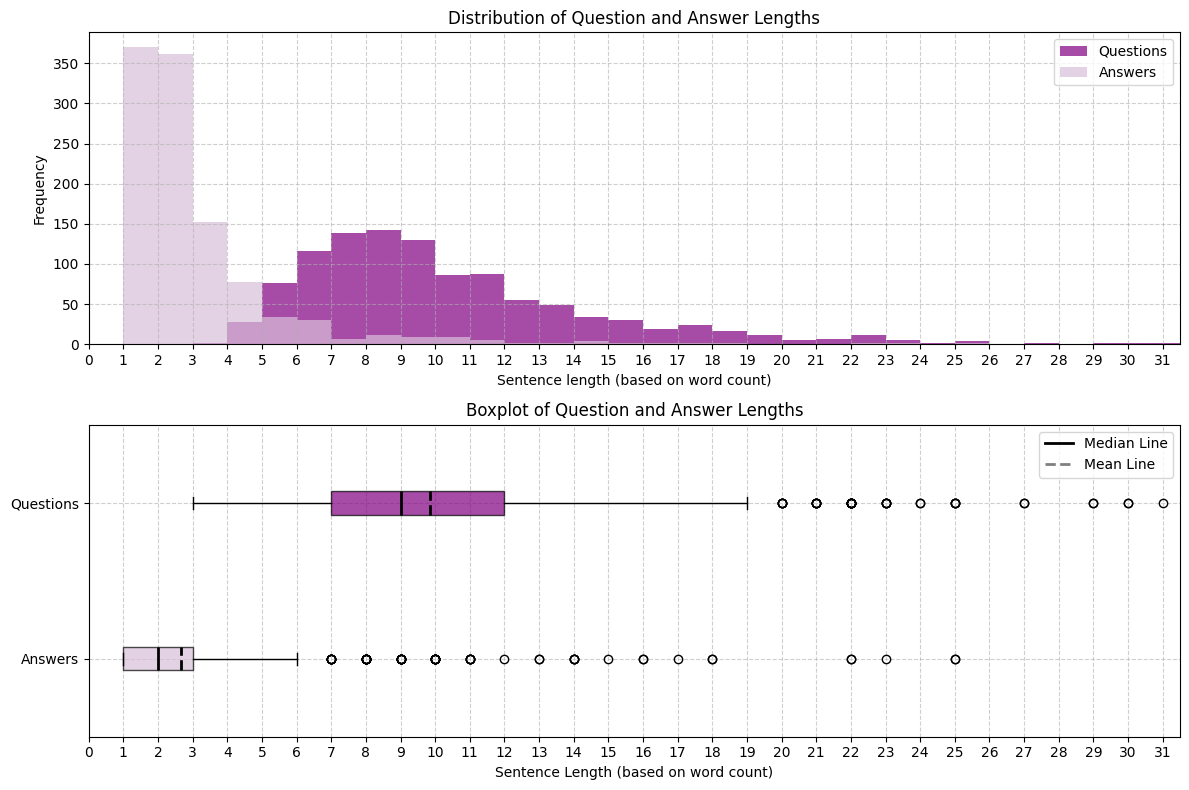

In [14]:
# let's plot the distribution of lengths of questions and answers
eda.plot_qa_len_distributions(question_lengths, answer_lengths)

From the plot above:
- Both questions and answers have longer sentences as outliers, perhaps they can be made more concise / clearer?
- The questions looks like a right-skewed normal distribution
- Most questions are ~12 words or less (75% percentile)
- Most questions fall between 7 and 12 words (inter-quartile range), with a mean of 9 words.
- The answers is also a very right-skewed distribution with a rapid decay.
- Most answers are ~3 words or less (75% percentile)
- One word answers are the most common.
- So the answers are generally short words that should make answer checking simpler.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

### 5.1.1 Answer lengths

An analysis of answer lengths within the dataset helps set expectations for complexity in player response within the trivia game. The distribution of word counts indicates whether typical player input is likely to be short (mirroring the dataset's concentration of 1-3 word answers) or will sometimes include much longer responses (reflecting the dataset's long tail).Establishing a clear definition for 'short' and 'long' answers, based on the dataset's statistical properties, enables a structured analysis. 

 The descriptive statistics in [section 5.1](#51-overview) show 75% of answers have 3 words or fewer (Q3 is 3 words) and an interquartile range (IQR) of 2 words. The outlier threshold (Q3 + 1.5*IQR = 6) provides a suitable cutoff such that: 
- *answers qualify as "short" with 6 or fewer words*, 
- *answers qualify as "long" with 7 or more words*.

Beyond length, examining the diversity in answers is also crucial. This can influences gameplay engagement and the requirements for the answer-checking system. 
- A diverse answer set indicates it covers a good range of the Harry Potter universe (characters, spells, places etc.) and less  repetition which will make the in-game experience more immersive and engaging. 
- Along with length, the type and obscurity of the answer can help determine the range of difficulty within the dataset.
- High diversity could also mean that the same thing is being said in different ways. For example a question with the answer "Professor Albus Dumbledore" could have synonym like answers such as "Albus", "Albus Dumbledore", "the headmaster" etc. This would inform the design considerations for semantic-similarity analysis in later project phases.
- Ultimately, this analysis of answer characteristics contributes to a fuller understanding of the dataset, helping confirm its suitability for the MVP by verifying content variety and informing the design scope for answer evaluation.

In [15]:
# Total number of answers:
total_answers = len(answer_lengths)

# Categorize word counts into bins:
bin_edges = [0, 3, 11, np.inf]
bin_labels = ['1-3 words', '4-11 words', '12+ words']
answer_length_bins = pd.cut(answer_lengths, bins=bin_edges,labels=bin_labels,right=True, # (x, y], upper limit is inclusive, lower is not
                            include_lowest=False) # Exclude 0 as wordcount

# Calculate frequencies and percentages for these bins
binned_counts = answer_length_bins.value_counts().sort_index()
binned_percentages = (binned_counts / total_answers) * 100
# Create a DataFrame for cleaner display of binned results
summary_bin_df = pd.DataFrame({'Count': binned_counts,'Percentage (%)': binned_percentages.round(2) })

# Display summary
print(" Summary of answer length frequencies:\n",
      '-'*60)
print(f'\nTotal number of answers analyzed: {total_answers}')
count_more_than_3 = binned_counts.get('4-11 words', 0) + binned_counts.get('12+ words', 0)
print(f'The number of answers with a word count more than 3: {count_more_than_3}')
print("\nAnswer Length Distribution by Bins:")
display(summary_bin_df)
# Verify percentages add to ~100%
print(f'\nTotal Percentage (check): {binned_percentages.sum():.2f}%')

 Summary of answer length frequencies:
 ------------------------------------------------------------

Total number of answers analyzed: 1085
The number of answers with a word count more than 3: 201

Answer Length Distribution by Bins:


,Count,Percentage (%)
answer,,
1-3 words,884,81.47
4-11 words,183,16.87
12+ words,18,1.66



Total Percentage (check): 100.00%


Majority (81%) of the answers are short (1 to 3 words). The interquaritile range is between 1 to 3 words. The distribution is right-skewed with a rapid decay. About 17% has answer lengths between 4 to 11 words while the remaining 2% have a word count of 12 or more. The maximum answer length is 25 words.
 - For analysis, answers with a word count of 6 (Q3 + 1.5* IQR) was used as cutoff for categorizing answers into short (wc <= 6) and long answers (wc > 6).
- The short anwerer are generally unique indicating there is good variety. The short answer will also simplify checking answers. 
   

**Short answers**:

In [16]:
# We will set a threshold for length: Answers length <= 6 are short, rest are long.
ans_len_threshold = 6
# create a dict of with answer len as key
answer_n_wc = {n: trivia_df[answer_lengths == n] for n in range(1,ans_len_threshold+1,1)}
# create a nested dict so that we can include percentage of small ans to each wordcount
unique_answers_dict = {
    n: {
        'num_unique': (num_unique := answer_n_wc[n]['answer'].nunique()),
        'total_answers': (total := answer_n_wc[n]['answer'].count()),
        'percentage': round(num_unique / total * 100, 2)
    }
    for n in range(1, 7)
 }
unique_answers_df = pd.DataFrame(unique_answers_dict).T
unique_answers_df['percentage'] = unique_answers_df['percentage'].round(0).astype(int)
unique_answers_df[['num_unique','total_answers']] = unique_answers_df[['num_unique','total_answers']].astype(int)  
unique_answers_df

,num_unique,total_answers,percentage
1,310,370,84
2,304,362,84
3,141,152,93
4,73,78,94
5,34,34,100
6,29,30,97


We can see that most of the short-word answers have a hight count of unique values for a given length; we can infer that there is not a lot of repitition. This is a good high level confirmation that there is diversity in the dataset but we will have to take a closer look to actually confirm if this true. For example `Albus` and `Dumbledore` are unique terms  but refer to the same person. We will need more granual and contextual understanding to fully understand the diversity of the dataset.

**Long answers:**

In [17]:
# display the full content of all columns without truncation
pd.set_option('display.max_colwidth', None)

# filter for long answers
long_answers= trivia_df[answer_lengths > ans_len_threshold]

# Display results
print(f"There are {long_answers['answer'].count()} answers with a word count greater than {ans_len_threshold}\n\n")
print(long_answers['answer'].sample(10))

There are 59 answers with a word count greater than 6


669                                                            He works as an Auror for the Ministry of Magic.
940                                Cornelius Fudge, Rufus Scrimgeour, Pius Thicknesse and Kingsley Shacklebolt
882           While thinking about what you need the room to become, walk past where it should be three times.
151                                                                 In Madame Malkin’s Robes for All Occasions
309    Tom Riddle’s Diary, Nagini, the giant ring, the Hufflepuff cup, Slytherin Locket, and Ravenclaw diadem.
837                    Ron blames Hermione’s cat, Crookshanks, for the disappearance of his pet rat, Scabbers.
824                                                                             The first time he rode a broom
706                                             He grabs Fawkes’s tail, and they disappear in a flash of fire.
392                                            Ordinary 

**Notes**:
- Some of the longest (including the most long) answers are lists.
- A few answers are just wordy.
- Others need to be long to give the full answer.

In [18]:
# Let's look at long answer outliers:
long_answers= trivia_df[answer_lengths >= 17]

# Display the number of unique words in the one-word answers and total number of one-word answers
print(f"The number of outlier long answers: {long_answers.shape[0]}\n",
      f"\n The outlier long answers are:\n\n{long_answers['answer']}")

The number of outlier long answers: 8
 
 The outlier long answers are:

316                                                                                     38. It was 36 (one less than last year), but then Mrs. Dursley bought him two new presents to make up for it.
414                                                                                                                                    6-2-4-4-2. (Bonus: This spells M-A-G-I-C on a phone's keypad.)
490                                                                     “Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you very much.”
581                                                                                                 He uses the Patronus Charm in front of a Muggle (Dudley, and only because there were Dementors!).
627                                                                      In the book, the mummy trips on its wrappings. In the movie, it

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

### 5.1.2. Question lengths

**What are the main trends in question lengths?**


In [19]:
q1 = question_lengths.quantile(0.25)
q3 = question_lengths.quantile(0.75)
iqr = q3 - q1

short_questions = trivia_df[question_lengths < q1]
common_len_questions = trivia_df[(question_lengths >= q1)&(question_lengths<= q3)]
outlier_threshold = q3 + 1.5*iqr
long_questions= trivia_df[(question_lengths > q3) & (question_lengths <= outlier_threshold)]
vlong_outlier_questions = trivia_df[question_lengths > outlier_threshold]

print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}, Long outlier threshold: {outlier_threshold}")
print(f"Number of short questions (< Q1): {len(short_questions)}")
print(f"Number of common length questions (Q1-Q3): {len(common_len_questions)}")
print(f"Number of long questions (long outlier threshold < word count< Q3): {len(long_questions)}")
print(f"Number of very long (outlier) questions (> Q3 + 1.5*IQR): {len(vlong_outlier_questions)}")

Q1: 7.0, Q3: 12.0, IQR: 5.0, Long outlier threshold: 19.5
Number of short questions (< Q1): 222
Number of common length questions (Q1-Q3): 638
Number of long questions (long outlier threshold < word count< Q3): 184
Number of very long (outlier) questions (> Q3 + 1.5*IQR): 41


In [20]:
# what do the short questions look like? 
short_questions.sample(10)

,question,answer
372,What is an animagus?,A person with an animal form
768,Which species commandeered the Giant Wars?,Giants
445,Which was my Tonks favourite band?,The Weird Sisters
531,Who sent Harry his Firebolt?,Sirius Black
1049,What is a secret keeper?,A person entrusted with a secret
638,Who wrote Magical Draughts and Potions?,Arsenius Jigger
295,When do Puffskeins hum?,When they're content.
456,Who is the Divination professor?,Professor Trelawney
724,Myomancy involves observation of which creatures?,Mice and rats
238,What is Professor McGonagall’s animagus?,Silver tabby cat


In [21]:
# What are the shortest questions like? do they make sense?
short_questions.loc[question_lengths==question_lengths.min()]

,question,answer
352,Who kills Dobby?,Bellatrix Lestrange
881,What is arithmancy?,Numerology


The short questions are very concise and specific typically asking for facts so their answers seem to be equally short and precise. The shortest questions, with a wordcount, seem to be the same.  
What about the common length questions, that fall within the inter-quartile range?

In [22]:
common_len_questions.sample(10)

,question,answer
1035,"In Book 4, which two teams compete for the Quidditch World Cup?",Bulgaria and Ireland.
509,What do the students call the Gryffindor ghost?,Nearly Headless Nick.
892,What is Dean Thomas's favorite sport?,Football (soccer)
882,How do you get into the Room of Requirement?,"While thinking about what you need the room to become, walk past where it should be three times."
493,What two creatures are Hippogriffs a mix of?,Horses and eagles
879,Which of these being does not live on the Hogwarts grounds?,Goblins
917,Who is the house ghost of Hufflepuff?,The Fat Friar
207,What was Elfric the Eager's uprising?,A revolt.
1050,Which Hogwarts house does Luna Lovegood belong to?,Ravenclaw
1047,Which of these words best describes Slytherin House?,Resourceful


The questions follow the pattern of the short questions and are generally to the point and concise. However, there are few samples that showed truncated multiple choice questions (for example Q.175, Q.630, Q.327) - these should be looked at closer later and addressed in the [data quality section](#9-Data-quality-assurance-and-finalization). Again these are factual questions, with generally short (1 to 3 word) answers.

In [23]:
long_questions['question'].sample(5)

751    What does Harry do to impress Professor McGonagall enough that she gets him on the Gryffindor Quidditch team?
478                       According to Hagrid, which is the safest place in the Wizarding World other than Hogwarts?
815                           In the Chamber of Secrets, the tears of the Phoenix cured the Poison of what creature?
986                                          An Infusion of Wormwood is NOT an ingredient in which of these potions?
718                                           How do first years get from the Hogsmeade train station to the castle?
Name: question, dtype: string

In [24]:
vlong_outlier_questions['question'].sample(5)

385    Lily Potter once gave Professor Slughorn a bowl with a lily that turned into a goldfish. What was the goldfish’s name?
288                           In the epilogue to the book, who says, “Don’t let it worry you. It’s me, I’m extremely famous.”
708                 What was the name of the house where the Weasleys once lived, which became a second home to Harry Potter?
554          Who is the giant three-headed dog that guards the trapdoor leading to the Philosopher's Stone in the first book?
812         This real-life library served as the restricted section of the Hogwarts library in the film version. Which is it?
Name: question, dtype: string

In [25]:
vlong_outlier_questions.sample(5)

,question,answer
404,What is the name of the three-headed dog guarding the trapdoor in Harry Potter and the Sorcerer's Stone?,Fluffy
568,"What do Harry, Ron and Hermione find in the locked cabinet of a writing desk at the Order of the Phoenix Headquarters?",A Boggart
16,Cedric Diggory let Harry use the prefect's bathroom in The Goblet of Fire. What man's statue is next to the special lavatory entrance?,Boris the Bewildered.
614,What creature sat in the corner of Professor Lupin's office the first time Harry Potter visited him at Hogwarts?,Grindylow
957,Hermione places a jinx on the piece of parchment members of Dumbledore’s Army sign. What happens to those who betray the group?,Pustules will form the word sneak across their foreheads.


>📝  **Notes**:
>1. Majority of the answers are short words (75% of words are 3 words or less). This would make checking answers for these questions relatively straight forward.
>2. There are 179 answers that are longer then 3 word. A lot of them can be shortened to fewer ones. Can write a script with NER to update these later on to have a cleaner dataset.
>3. There are 7 outlier questions, some of which can be simpliefied.
>4. The questions are
> 
> Overall we can consider the quality of the questions and answer to be good with a good sized dataset for the the trivia game and a nice variety in those questions. It will be interesting to see what the difficulty of those questions are like.
> <br>


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 5.2. Question and answer length correlation

A key part of the analysis is to explore whether there is a statistically significant relationship between the question and answer lengths. We can start with a high-level (entire dataset) perspective and see if there is any general linear trend between how long a question is and how long its answer is. This can give us a baseline idea of any trend that we can fine-tune as we dive further into the EDA.

We can frame this by first testing our null hypothesis:

- *Null hypothesis ($H_0$):* There is no statistically significant relationship between the length of a question and the length of its answer.
- *Alternative hypothesis ($H_1$):* There is a relationship between the lengths of questions and their answers.

Since this is an aggregated view, there might be hidden underlying patterns that can't be discerned yet. This is investigated at a more granular level in the in-depth EDA ([section 6](#6-eda-based-on-keywords).)




Correlation between all question and answer lengths:
----------------------------------------------------------------------
* r-value: 0.09, p-value: 0.002
* Interpretation: Statistically significant (correlation is Very Weak)
----------------------------------------------------------------------


Scatter Plot with Regression Line:


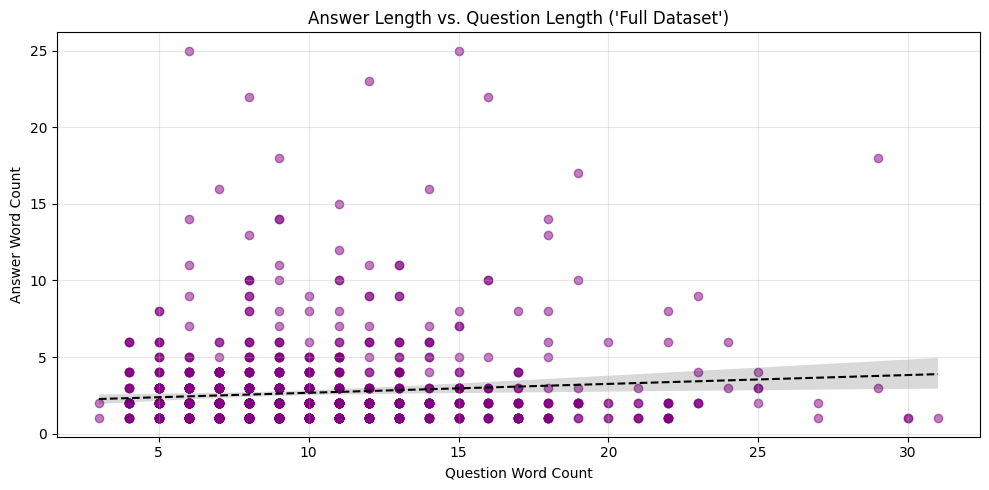

In [26]:
# Use the custom helper functions from the eda_scripts module:
# 1. Calculate r and p-values  
r_all, p_all = eda.calculate_correlation(question_lengths, answer_lengths)
# 2. Interpret the correlation and print results
corr_interpretation, r_strength = eda.interpret_correlation(r_all, p_all)
print(f"\nCorrelation between all question and answer lengths:\n"
      f"{'-'*70}\n"
      f"* r-value: {r_all:.2f}, p-value: {p_all:.3f}\n"
      f"* Interpretation: {corr_interpretation}\n"
      f"{'-'*70}\n")
# 3. Create a scatter plot of the correlation
eda.create_correlation_scatterplot(question_lengths, answer_lengths, "Full dataset" )

- There is a statistically significant (p: 0.002 < 0.05 ) relationship between the answer length and the question length. The null hypothesis can be rejected.
- The relationship is positive but weak (r = 0.094). This can be expected since the question length *alone* is not a strong predictor of the answer length.
- This is visually demonstrated in the scatter plot and its trend line. Most of the answers are short but there is a slight positive, linear relationship to the question length.
- More granular assessment could give an idea of which questions types are predictive of the answer length and which ones are not.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

<div align="center" style="background-color: #f0e6f7; padding: 10px;">
    <span style="color:purple; font-size:32px;">Part-2: Feature engineering</span>
</div>

# 6. Keyword feature engineering

### Custom tokenizer
We can augment this list using a custom-designed tokenizer.

In [27]:
# create a copy of trivia_df
trivia_keywords_df = trivia_df.copy()

lemmatizer = WordNetLemmatizer()
ENGLISH_STOP_WORDS = set(stopwords.words('english'))

# Function to convert POS tags for better lemmatization
def get_wordnet_pos(nltk_tag):
    if nltk_tag.startswith('J'):
        return wordnet.ADJ
    elif nltk_tag.startswith('V'):
        return wordnet.VERB
    elif nltk_tag.startswith('N'):
        return wordnet.NOUN
    elif nltk_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # Default to noun

# Custom tokenizer with lemmatization
def tokenize_text(text):
    '''
    Takes a sentence:
    - Removes punctuation
    - Converts to lowercase
    - Tokenizes into words
    - Removes stopwords
    - Lemmatizes each word based on POS tagging
    
    Returns list of lemmatized tokens.
    '''
    
    # Keep only letters and spaces, removing numbers and punctuatio
    text = re.sub(r'[^a-zA-Z\s]', '', text).lower()

    # Tokenize the text
    tokens = word_tokenize(text)
    
    # Remove stopwords and single letter words before POS tagging for efficiency.
    # Exclude words from the stop words list that can help understand the questions in EDA
    custom_stopwords = ENGLISH_STOP_WORDS - set(eda.INTERROGATIVE_KEYWORDS_LIST)
    filtered_tokens = [word for word in tokens if (word not in custom_stopwords) and (len(word) > 1)]

    # POS tagging
    pos_tags = pos_tag(filtered_tokens)

    # Lemmatize each word
    lemmatized_words = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in pos_tags]

    return lemmatized_words

In [28]:
# Create unique 'keywords' column by tokenizing 'question', 'answer', and combined (question, answer) with the custom tokenizer using a custom method from eda_scripts
trivia_keywords_df = eda.create_token_columns(trivia_keywords_df, tokenizer=tokenize_text)

# Display the updated DataFrame
trivia_keywords_df.head()

,question,answer,question tokens,answer tokens,combined_unique_tokens
0,What are the three European wizarding schools that participate in the Triwizard Tournament?,"Hogwarts, Beauxbatons, and Durmstrang.","[what, be, three, european, wizarding, school, participate, triwizard, tournament]","[hogwarts, beauxbatons, durmstrang]","[what, be, three, european, wizarding, school, participate, triwizard, tournament, hogwarts, beauxbatons, durmstrang]"
1,When was Hogwarts founded?,10th century,"[when, be, hogwarts, found]","[th, century]","[when, be, hogwarts, found, th, century]"
2,What is a Wronski Feint?,Pretending to dive for the Snitch,"[what, be, wronski, feint]","[pretend, dive, snitch]","[what, be, wronski, feint, pretend, dive, snitch]"
3,You wouldn't know anything about this. Name a method to make your broom go faster.,Using polish,"[wouldnt, know, anything, name, method, make, broom, go, faster]","[use, polish]","[wouldnt, know, anything, name, method, make, broom, go, faster, use, polish]"
4,Harry first took the Knight Bus in The Prisoner of Azkaban. How much does a ticket cost if it includes hot chocolate?,14 sickles.,"[harry, first, take, knight, bus, prisoner, azkaban, how, much, do, ticket, cost, include, hot, chocolate]",[sickle],"[harry, first, take, knight, bus, prisoner, azkaban, how, much, do, ticket, cost, include, hot, chocolate, sickle]"


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

<div align="center" style="background-color: #f0e6f7; padding: 10px;">
    <span style="color:purple; font-size:32px;">Part-3: In-depth EDA with question keywords and N-grams</span>
</div>

# 7. EDA based on keywords

Now that we have a list of unique keywords for each record, we can gather them together and analyze them. First let's look at the frequency that keywords appear across the dataset.

## 7.1. Unique keyword frequency

Currently the questions and answers are tokenized but multiple words can pop up in the list for a given record. As you can recall, each record has a column for keywords within the question, the answer, and a third with them combined. In order to calculate the frequencies:
- Convert the `combined keyword` column to drop repated tokens and rename it as `combined_unique_keywords`.
- Then we can gather all the keywords from the 'combined_unique_keywords` column in a list.
- The we use the `Counter` method to create a list of tuples of each keyword along with a count of how many times it appears in the list. 
- The Counter object can then be converted into a data frame  for easier data manipulation.

This will give us an overall keyword frequency count for the dataset.

In [29]:
# # Extract unique tokens for each row in the 'keywords' column
# trivia_keywords_df['combined_unique_tokens'] = trivia_keywords_df['combined tokens'].apply(lambda x: list(OrderedDict.fromkeys(x)))  # Already done in tokenization
# trivia_keywords_df.drop(columns=['combined tokens'], inplace=True)  # Drop the original 'keywords' column

# Flatten the list of all tokens to count their occurrences across the DataFrame
all_tokens = [token for sublist in trivia_keywords_df['combined_unique_tokens'] for token in sublist]

# Count the frequency of each token across all rows
token_counts = Counter(all_tokens)

# 1. Show the top `n` most common items
n = 20  
top_keywords = token_counts.most_common(n)
# display results:
print(f"The {n} most common unique tokens (in the questions and answers combined) are:")
print(top_keywords)

The 20 most common unique tokens (in the questions and answers combined) are:
[('be', 554), ('what', 532), ('do', 266), ('which', 194), ('who', 167), ('harry', 125), ('name', 118), ('hogwarts', 89), ('how', 70), ('use', 65), ('spell', 63), ('potion', 63), ('where', 63), ('potter', 60), ('when', 57), ('charm', 51), ('first', 50), ('magical', 46), ('quidditch', 46), ('professor', 45)]


In [30]:
# 2. Convert into a data frame for easier handling
keyword_count_df = pd.DataFrame(token_counts.items(), columns=['Keyword', 'Frequency'])
keyword_count_df = keyword_count_df.sort_values(by = 'Frequency', ascending=False)
keyword_count_df.head(20)


,Keyword,Frequency
1,be,554
0,what,532
41,do,266
52,which,194
102,who,167
32,harry,125
24,name,118
9,hogwarts,89
39,how,70
30,use,65


In [31]:
# Filter the DataFrame to include only rows where count is greater than 20
frequency_cutoff = 20
filtered_keyword_count_df = keyword_count_df[keyword_count_df['Frequency'] > 20]

print(f"There are {filtered_keyword_count_df.shape[0]} keywords with a frequency more then {frequency_cutoff}.")

There are 44 keywords with a frequency more then 20.


Visualizing the results as a bar chart will make the comparison a lot easier.

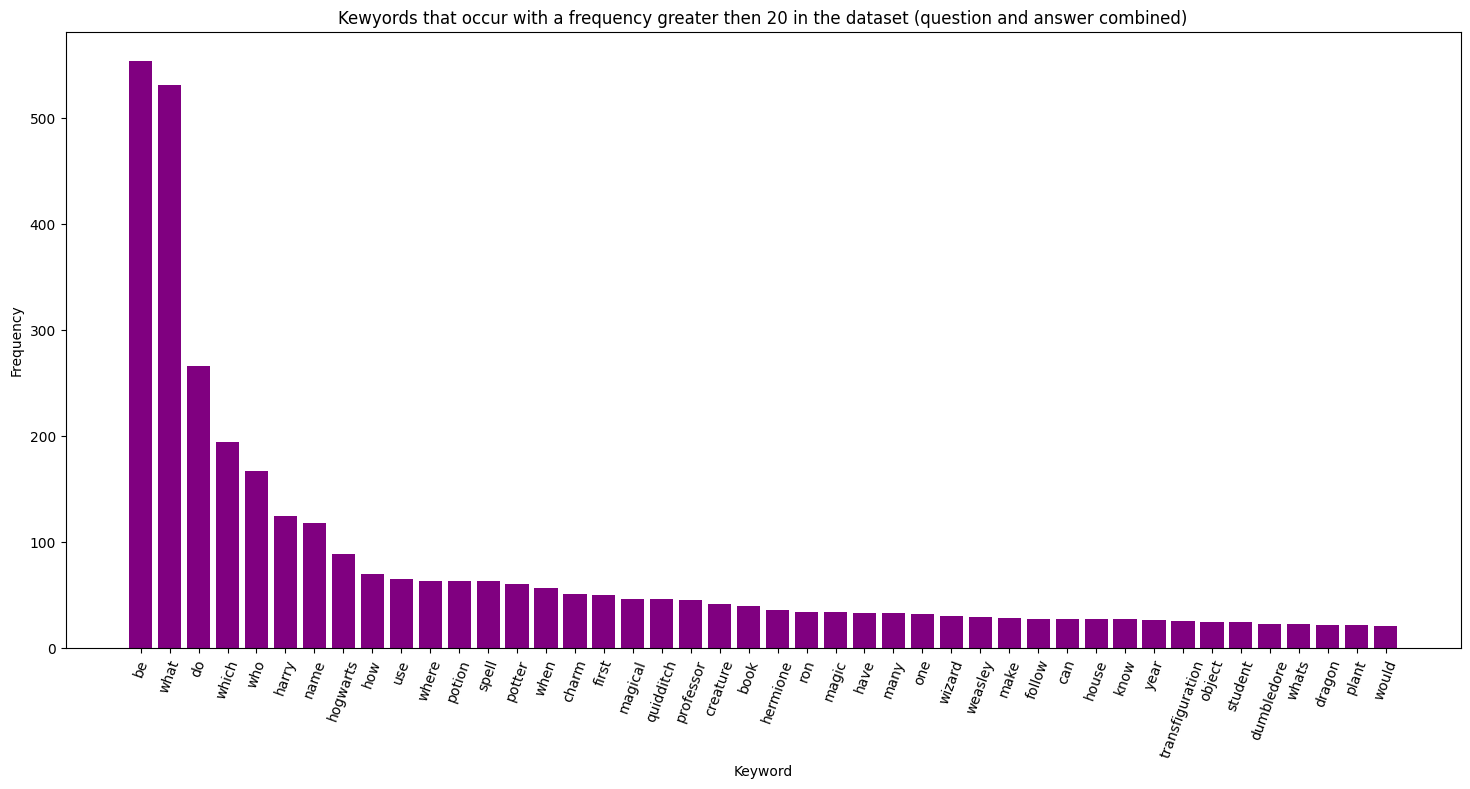

In [32]:
plt.figure(figsize=(18,8))

plt.bar(filtered_keyword_count_df['Keyword'], filtered_keyword_count_df['Frequency'], color="purple")

plt.xlabel('Keyword')
plt.ylabel('Frequency')
plt.title(f"Kewyords that occur with a frequency greater then {frequency_cutoff} in the dataset (question and answer combined)")
plt.xticks(rotation=70)
plt.show()

**Notes on keyword frequency**
1. The `what`, `which`, `who`, `name`, `how` and `where` are in top 10 of the frequency counts, so it looks like majority questions are likely to be factual types. These questions in all likelihood should have short answers. We can take a closer look at the dataset to confirm. `What` by far is the most common type of question keyword.
2. Its not a suprise that `harry` and `hogwarts` are also in the top - they would be the most common contextual keyword.
3. `spell` also might be a factual question? what kind of spell - may be check if all occurrence of spell are the factual question keywords? The same logic would be for `potion` and `charm`. 
4. There are some very wordy answers, it'll be interesting to look at their question format / type.
5. Note - `whats` and `would` also appear near the tail end of the graph although `would` questions could be quite open-ended?

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 7.2. Factual recall questions

In trivia, some of the most common questions are usually concerned with recalling specific facts to test the player. These questions typically ask about names, places, events, or spells. 

From the figure above, we can see that the top interrogative keywords like 'what', 'which', 'who', along with frequent subject-related keywords like 'harry' and 'name', dominate. This strongly suggests that many questions could be *factual recall* types. So, we can expect these questions to have typical formats such 'What is Albus Dumbledore's full name?" or "Where did Harry live during the summer holidays?".  We can assess the occurence of such typical keywords in the `question keywords` along with their frequency. These keywords could be:

- "Who...?" -> related to a character name.
- "What...?" -> an object, fact, event
- "Where...?" -> a location
- "When...?" / "In what year...?" -> would relate a timing of an event (books timeline)
- "How many...?" -> Number (although 'how' on its own can be open-ended. so might have to check for presence of both)
- "Name the..." -> a list / name(s)
<br>

**Methodology for analysis**:

First frequency of occurence of the "factual recall keywords" was determined based on a predefined list that was iteratively updated based on the analysis ([section 6.2.1](#621-Distribution-of-factual-recall-type-questions)). Then a more granular analysis was done by filtering and analysing questions for each question keyword ([section 6.2.2](#622-what-do-the-what-questions-look-like) to [section 6.2.5](#625-what-do-when-questions-look-like)).

A set of custom functions were developed to assess these keyword questions in a systematic, efficient, and standardized way. These functions are located in the `eda_scripts.py` module and imported into the notebook. The main steps for analyzing questions by 'factual recall' keywords (e.g. "what", "where") is to use the:

1. `eda.get_question_type_info(df_for_analysis,q_keyword, n_samples)` method to obtain summary analysis. This method uses the occurence of the keyword in the `question keyword` column to filter the relevant record. This includes:
    - the number (and percentage) of questions in the dataset with the selected "keyword" in it, 
    - the maximum, minimum, and descriptive statistics for the answer lengths associated with the question,
    - a sample of the filtered dataframe used by the method.
2. `eda.create_ans_len_boxplot(df_for_analysis,q_keyword)` method to generate side-by-side box plots of the filtered "keyword" questions and associated answers.
3.  `eda.print_keyword_ngrams(df_for_analysis['question'],keyword,(min_ngram_size, max_ngram_size))` to find n-grams in the raw question string in the `question` column, a custom list of stop words (default is None), and a range of n-gram size that are of iterest. By default the method looks at the top 10 but this parameter can also be changed. N-grams allow contextual understanding of the question, e.g. confirm it is a factual recall type? with stop words filtering it gives more information on the harry potter context and shows how the keywords are frequently chained together.

### Section 7.2 quick links

[7.2.1. Distribution of factual recall type questions](#721-Distribution-of-factual-recall-type-questions)<br>
[7.2.2. What do the "what" questions look like?](#722-What-do-the-what-questions-look-like)<br>
[7.2.3. What do the "who" questions look like? ](#723-What-do-the-who-questions-look-like)<br>
[7.2.4. What do the "where" questons look like?](#724-What-do-the-where-questions-look-like)<br>
[7.2.5. What do the "when" questions look like?](#725-what-do-when-questions-look-like)<br>

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

### 7.2.1. Distribution of factual recall type questions 

Now let's take a wider look at the dataset and see how many answers we can consider to be *factual recall* . We can create a list of words to look for. The list might not be exhaustive but will gives us a good sense of the dataset.

In [33]:
# list of words to look for when identifying 'factual recall' questions 
factual_recall_list = ['what', 'name', 'who', 'where', 'when', 'whats']

trivia_keywords_df = eda.tag_questions_by_keyword_list(
    df=trivia_keywords_df,
    keyword_column='question tokens', # Make sure this is the correct column name
    trigger_keyword_list=factual_recall_list,
    new_column_name='factual_recall_keyword'
)

In [34]:
# Sanity check
trivia_keywords_df.head()

,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword
0,What are the three European wizarding schools that participate in the Triwizard Tournament?,"Hogwarts, Beauxbatons, and Durmstrang.","[what, be, three, european, wizarding, school, participate, triwizard, tournament]","[hogwarts, beauxbatons, durmstrang]","[what, be, three, european, wizarding, school, participate, triwizard, tournament, hogwarts, beauxbatons, durmstrang]",[what]
1,When was Hogwarts founded?,10th century,"[when, be, hogwarts, found]","[th, century]","[when, be, hogwarts, found, th, century]",[when]
2,What is a Wronski Feint?,Pretending to dive for the Snitch,"[what, be, wronski, feint]","[pretend, dive, snitch]","[what, be, wronski, feint, pretend, dive, snitch]",[what]
3,You wouldn't know anything about this. Name a method to make your broom go faster.,Using polish,"[wouldnt, know, anything, name, method, make, broom, go, faster]","[use, polish]","[wouldnt, know, anything, name, method, make, broom, go, faster, use, polish]",[name]
4,Harry first took the Knight Bus in The Prisoner of Azkaban. How much does a ticket cost if it includes hot chocolate?,14 sickles.,"[harry, first, take, knight, bus, prisoner, azkaban, how, much, do, ticket, cost, include, hot, chocolate]",[sickle],"[harry, first, take, knight, bus, prisoner, azkaban, how, much, do, ticket, cost, include, hot, chocolate, sickle]",N/A


The main analysis parameters going forward are defined here for ease of use and error management. This includes:
- `df_for_analysis`: The cleaned and processed copy of the dataset that is the same across the analysis but called multiple times in functions.
- `n_samples`: The number of random samples to display from the dataframe filtered by keyword (the methods have built-in corrections if the dataframe size is smaller then n_samples).

In [35]:
# Parameters for analysis:
df_for_analysis = trivia_keywords_df.reset_index(names='original_question_id').copy()  # using a copy to keep the original intact and keep the original question id as a column
n_samples = 5

In [36]:
df_for_analysis.head()

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword
0,0,What are the three European wizarding schools that participate in the Triwizard Tournament?,"Hogwarts, Beauxbatons, and Durmstrang.","[what, be, three, european, wizarding, school, participate, triwizard, tournament]","[hogwarts, beauxbatons, durmstrang]","[what, be, three, european, wizarding, school, participate, triwizard, tournament, hogwarts, beauxbatons, durmstrang]",[what]
1,1,When was Hogwarts founded?,10th century,"[when, be, hogwarts, found]","[th, century]","[when, be, hogwarts, found, th, century]",[when]
2,2,What is a Wronski Feint?,Pretending to dive for the Snitch,"[what, be, wronski, feint]","[pretend, dive, snitch]","[what, be, wronski, feint, pretend, dive, snitch]",[what]
3,3,You wouldn't know anything about this. Name a method to make your broom go faster.,Using polish,"[wouldnt, know, anything, name, method, make, broom, go, faster]","[use, polish]","[wouldnt, know, anything, name, method, make, broom, go, faster, use, polish]",[name]
4,4,Harry first took the Knight Bus in The Prisoner of Azkaban. How much does a ticket cost if it includes hot chocolate?,14 sickles.,"[harry, first, take, knight, bus, prisoner, azkaban, how, much, do, ticket, cost, include, hot, chocolate]",[sickle],"[harry, first, take, knight, bus, prisoner, azkaban, how, much, do, ticket, cost, include, hot, chocolate, sickle]",N/A


In [37]:
## How many of the records have vs. don't have a 'N/A' tag for the 'factual_recall_keyword'?

# where 'factual_recall_keyword' is N/A
not_factual_q_count = trivia_keywords_df[trivia_keywords_df['factual_recall_keyword']=='N/A']['question'].count()
not_factual_q_percentage = (not_factual_q_count / trivia_keywords_df.shape[0]) * 100
# where 'factual_recall_keyword' is not N/A
factual_q_count = trivia_keywords_df.shape[0] - not_factual_q_count
factual_q_percentage = 100 - not_factual_q_percentage

# display results
print("Factual recall questions:\n",
      f"- There are at least {factual_q_count} questions ({factual_q_percentage: .0f}% of total count) that can be considered factual recall types.\n",
      f"- There are {not_factual_q_count} questions ({not_factual_q_percentage: .0f}% of total count) that can be considered as not being factual recall types."
)

Factual recall questions:
 - There are at least 802 questions ( 74% of total count) that can be considered factual recall types.
 - There are 283 questions ( 26% of total count) that can be considered as not being factual recall types.


In [38]:
## How are the factual questions distributed?

# 1. Create a dictionary to store values for easy plotting
factq_dict = {}
total = trivia_keywords_df.shape[0]

for keyword in factual_recall_list:
    # check if keyword contains a list and then if keyword is in the list:
    filter_condition = lambda x: keyword in x if isinstance(x, list) else False
    count = trivia_keywords_df[trivia_keywords_df['factual_recall_keyword'].apply(filter_condition)].shape[0]
    factq_dict[keyword] = {
        'count': count,
        'percentage of total': (count / total) * 100
    }


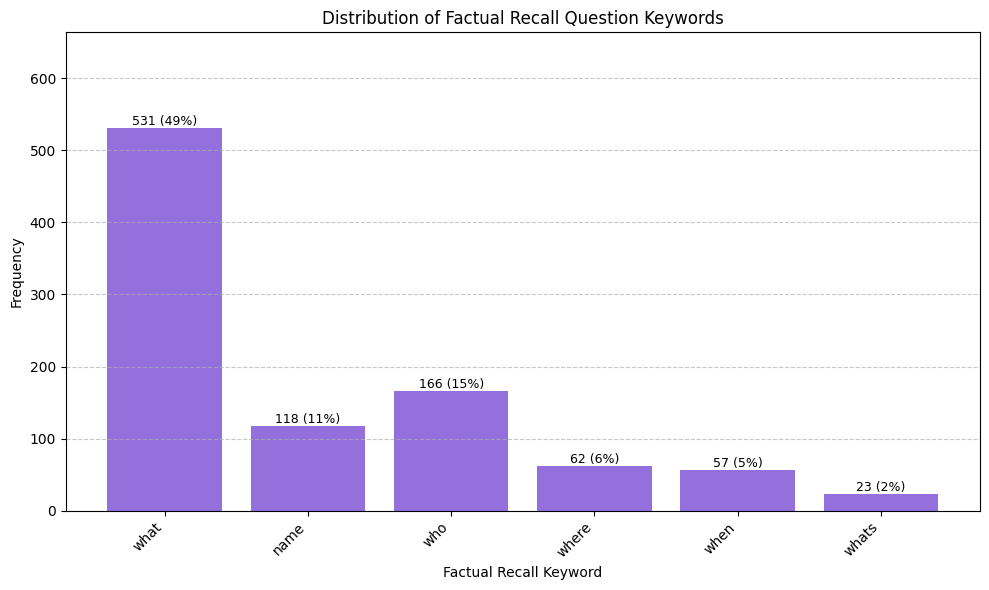

In [39]:
# 2. Visualize as a barchart 

factq_counts_series = pd.Series({k: v['count'] for k, v in factq_dict.items()})
total_questions = trivia_keywords_df.shape[0]

eda.plot_categorical_distribution(factq_counts_series, total_questions,
                              "Distribution of Factual Recall Question Keywords",
                              "Factual Recall Keyword")

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-62-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.2 Quick Links</a>

### 7.2.2 What do the `"what"` questions look like?

Let's start by looking at "What" type questions as they are the most common (as per figure 3).

## Analysis for Keyword: 'WHAT'

Number of Questions: 531 (48.9% of total)

Descriptive Statistics for Question and Answer lengths (word count):


,Question Length,Answer Length
Mean,10.10,2.55
Median,9.00,2.00
Std Dev,4.61,2.37
Min,3.00,1.00
Max,30.00,22.00
Skew,1.46,3.54



Correlation between Question and Answer Length:
* Interpretation: Not statistically significant (r=0.076)
* Pearson's r = 0.076, P-value = 0.078

Scatter Plot with Regression Line:


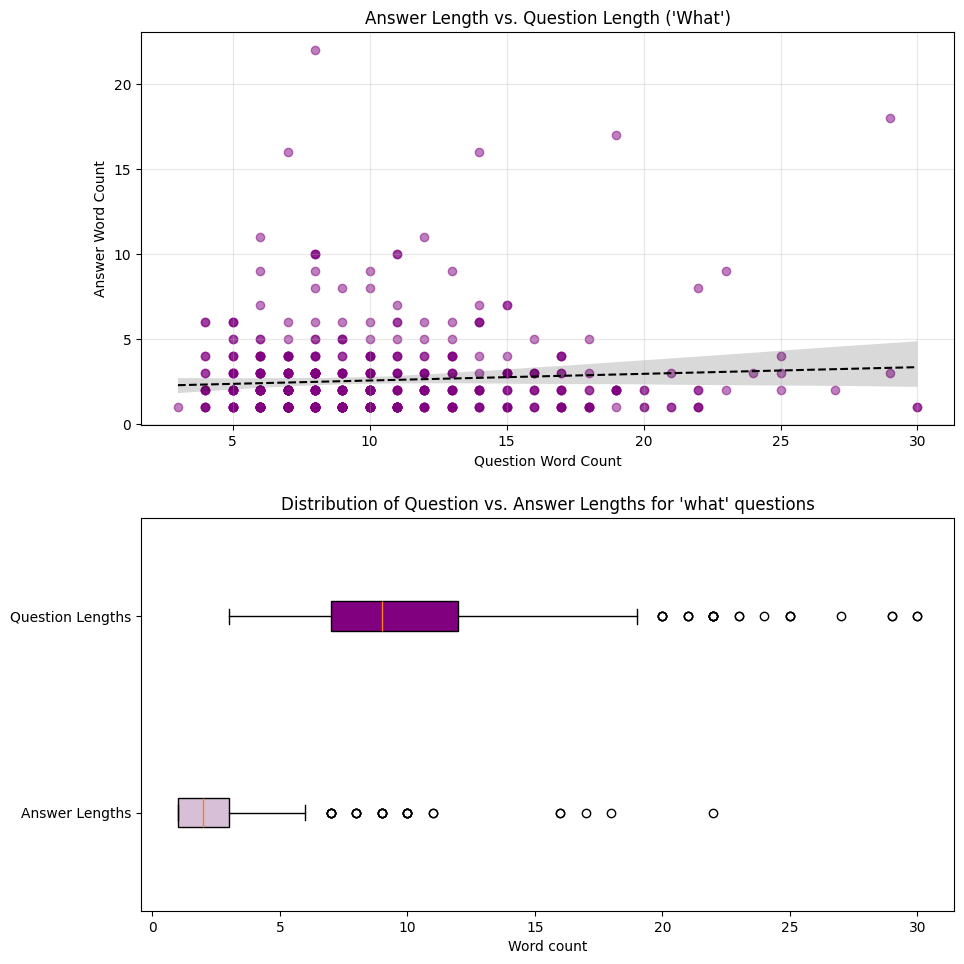


Random Sample (5) of 'what' Questions:


,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword
596,596,What position does Harry play in Quidditch?,Seeker,"[what, position, do, harry, play, quidditch]",[seeker],"[what, position, do, harry, play, quidditch, seeker]",[what]
988,988,What is the purpose of the spell Finite Incantatem?,Stop spells,"[what, be, purpose, spell, finite, incantatem]","[stop, spell]","[what, be, purpose, spell, finite, incantatem, stop]",[what]
38,38,What is the name of the house-elf that belongs to the Malfoy family?,Dobby,"[what, be, name, houseelf, belongs, malfoy, family]",[dobby],"[what, be, name, houseelf, belongs, malfoy, family, dobby]","[what, name]"
525,525,What is the term for a witch or wizard who can see the future?,Seer,"[what, be, term, witch, wizard, who, can, see, future]",[seer],"[what, be, term, witch, wizard, who, can, see, future, seer]","[what, who]"
976,976,What is Draco Malfoy's wand made of?,Hawthorne,"[what, be, draco, malfoys, wand, make]",[hawthorne],"[what, be, draco, malfoys, wand, make, hawthorne]",[what]


----------------------------------------------------------------------


In [40]:
q_keyword = "what"
what_q_metrics = eda.calculate_keyword_metrics(q_keyword, df_for_analysis)
eda.display_keyword_analysis(what_q_metrics, n_samples)

Ok, there is quite a range in answer length and we can't make any generalization about them. 

In [41]:
eda.print_keyword_ngrams(df_for_analysis['question'],'what',(2,5))


Analyzing common phrases (n-grams) starting with 'what' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'what':
- 'what is': 174
- 'what is the': 111
- 'what does': 50
- 'what is the name': 46
- 'what is the name of': 46
- 'what was': 27
- 'what did': 24
- 'what does the': 21
- 'what was the': 18
- 'what are': 17


In [42]:
# let's remove 'is', 'the', 'are', 'was' as our custom stop word list:
stop_words = ['is', 'the', 'are', 'was', 'does', 'did', 'do', 'kind', 'of', 'for','type'] 
eda.print_keyword_ngrams(df_for_analysis['question'],'what',(2,5), 10, stop_words)


Analyzing common phrases (n-grams) starting with 'what' in this set of questions:
Using stop_words: ['is', 'the', 'are', 'was', 'does', 'did', 'do', 'kind', 'of', 'for', 'type']
Top 10 common n-grams starting with 'what':
- 'what name': 63
- 'what spell': 17
- 'what magical': 16
- 'what creature': 15
- 'what incantation': 13
- 'what harry': 10
- 'what potion': 9
- 'what magical creature': 8
- 'what animal': 6
- 'what charm': 6


These N-grams also indicate that the "what" questions are asking for factual details.

Now let's also look at `name` keyword, it is the second-most frequent keyword but there might be an overlap with the `what` questions.

In [43]:
## What do questions with the 'name' keyword look like?

# Filter question that the word 'name' in them
name_questions = df_for_analysis.loc[df_for_analysis['question tokens'].apply(lambda x: keyword in x)]

# Now filter that subset of question to find the occurence of "name" without "what" / "what's" present.
name_nowhat_questions = name_questions[
    ~name_questions['question tokens'].apply(lambda x: 'what' in x or 'whats' in x)
]
# display results
print("Occurence of 'name' without 'what' in the trivia questions: ",name_nowhat_questions.shape[0])

Occurence of 'name' without 'what' in the trivia questions:  0


It look like that in this dataset "name" always appears with "what". So we don't have to consider them separately for now. However, it is entirely possible to phrase the question with just "name", e.g. "Name the characters from ....." and can be possible when the dataset is expanded.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-62-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.2 Quick Links</a>

### 7.2.3. What do the `"who"` questions look like?

Let's start by looking at "What" type questions as they are the most common (as per figure 3).

## Analysis for Keyword: 'WHO'

Number of Questions: 166 (15.3% of total)

Descriptive Statistics for Question and Answer lengths (word count):


,Question Length,Answer Length
Mean,9.57,2.52
Median,8.00,2.00
Std Dev,4.73,1.86
Min,3.00,1.00
Max,31.00,11.00
Skew,1.71,3.25



Correlation between Question and Answer Length:
* Interpretation: Not statistically significant (r=0.104)
* Pearson's r = 0.104, P-value = 0.184

Scatter Plot with Regression Line:


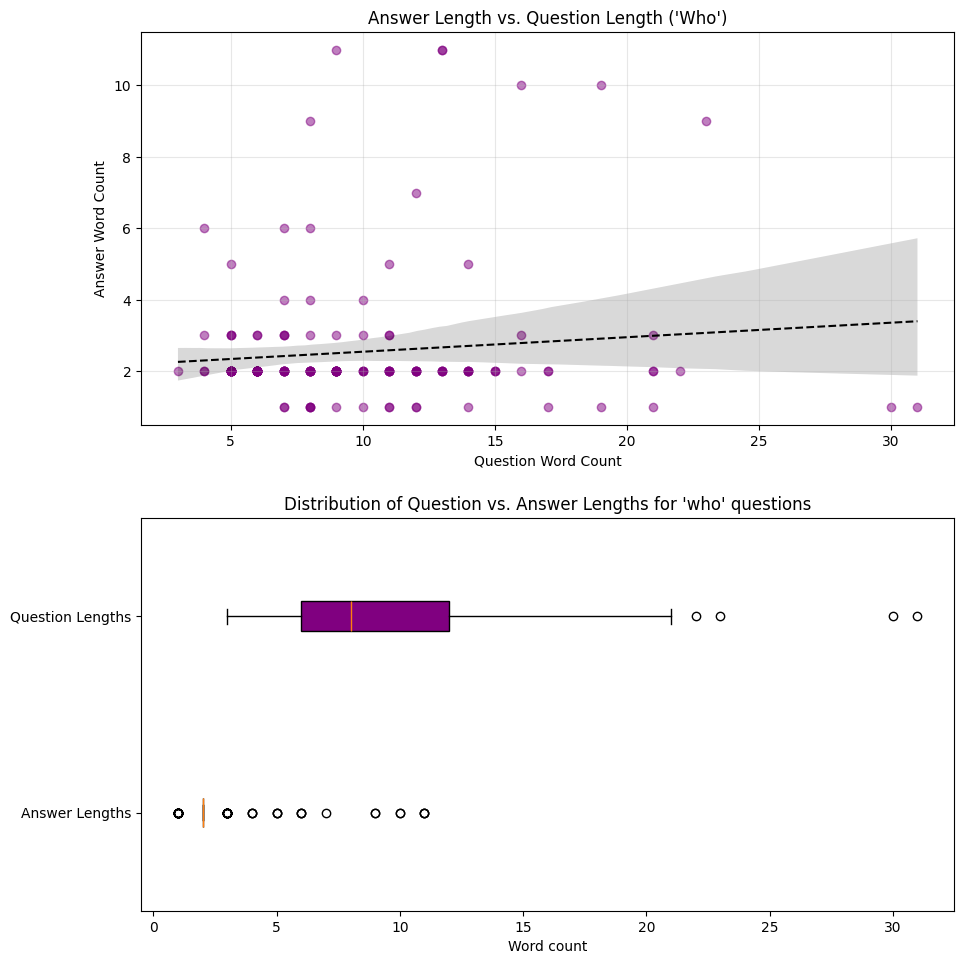


Random Sample (5) of 'who' Questions:


,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword
200,200,Who does Hermione impersonate using the Polyjuice Potion in the second book of the Harry Potter series?,Millicent Bulstrode,"[who, do, hermione, impersonate, use, polyjuice, potion, second, book, harry, potter, series]","[millicent, bulstrode]","[who, do, hermione, impersonate, use, polyjuice, potion, second, book, harry, potter, series, millicent, bulstrode]",[who]
917,917,Who is the house ghost of Hufflepuff?,The Fat Friar,"[who, be, house, ghost, hufflepuff]","[fat, friar]","[who, be, house, ghost, hufflepuff, fat, friar]",[who]
350,350,Who is the sister of Death Eater Bellatrix Lestrange?,Narcissa Malfoy,"[who, be, sister, death, eater, bellatrix, lestrange]","[narcissa, malfoy]","[who, be, sister, death, eater, bellatrix, lestrange, narcissa, malfoy]",[who]
82,82,Who created the Sorcerer's Stone?,Nicolas Flamel,"[who, create, sorcerer, stone]","[nicolas, flamel]","[who, create, sorcerer, stone, nicolas, flamel]",[who]
130,130,Who is the author of 'Fantastic Beasts and Where to Find Them'?,Newt Scamander,"[who, be, author, fantastic, beast, where, find]","[newt, scamander]","[who, be, author, fantastic, beast, where, find, newt, scamander]","[who, where]"


----------------------------------------------------------------------


In [44]:
q_keyword = "who"
who_q_metrics = eda.calculate_keyword_metrics(q_keyword, df_for_analysis)
eda.display_keyword_analysis(who_q_metrics, n_samples)

**Note**: Although we know there is considerable overlap between 'what' and 'name' - 'name' remains in assessment for completeness.

In [45]:
# With no stop_words considered:
eda.print_keyword_ngrams(df_for_analysis['question'],"who", (2,5))


Analyzing common phrases (n-grams) starting with 'who' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'who':
- 'who is': 56
- 'who is the': 38
- 'who was': 20
- 'who was the': 12
- 'who wrote': 8
- 'who does': 7
- 'who invented': 5
- 'who is harry': 4
- 'who teaches': 4
- 'who created': 3


In [46]:
# Using a custom list of stop words.
stop_words = ['is', 'was', 'does', 'the', 'of', 'in']
eda.print_keyword_ngrams(df_for_analysis['question'],"who", (3,7), stop_words=stop_words)


Analyzing common phrases (n-grams) starting with 'who' in this set of questions:
Using stop_words: ['is', 'was', 'does', 'the', 'of', 'in']
Top 10 common n-grams starting with 'who':
- 'who headmaster hogwarts': 6
- 'who harry potter': 3
- 'who harry potter godfather': 3
- 'who original owner': 3
- 'who created sorcerer': 2
- 'who created sorcerer stone': 2
- 'who destroyed horcrux': 2
- 'who destroyed horcrux helga': 2
- 'who divination professor': 2
- 'who flying instructor': 2


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-62-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.2 Quick Links</a>

### 7.2.4. What do the "where" questions look like? 

## Analysis for Keyword: 'WHERE'

Number of Questions: 62 (5.7% of total)

Descriptive Statistics for Question and Answer lengths (word count):


,Question Length,Answer Length
Mean,9.45,3.18
Median,9.00,3.00
Std Dev,3.99,2.40
Min,4.00,1.00
Max,22.00,14.00
Skew,0.96,2.61



Correlation between Question and Answer Length:
* Interpretation: Not statistically significant (r=0.236)
* Pearson's r = 0.236, P-value = 0.064

Scatter Plot with Regression Line:


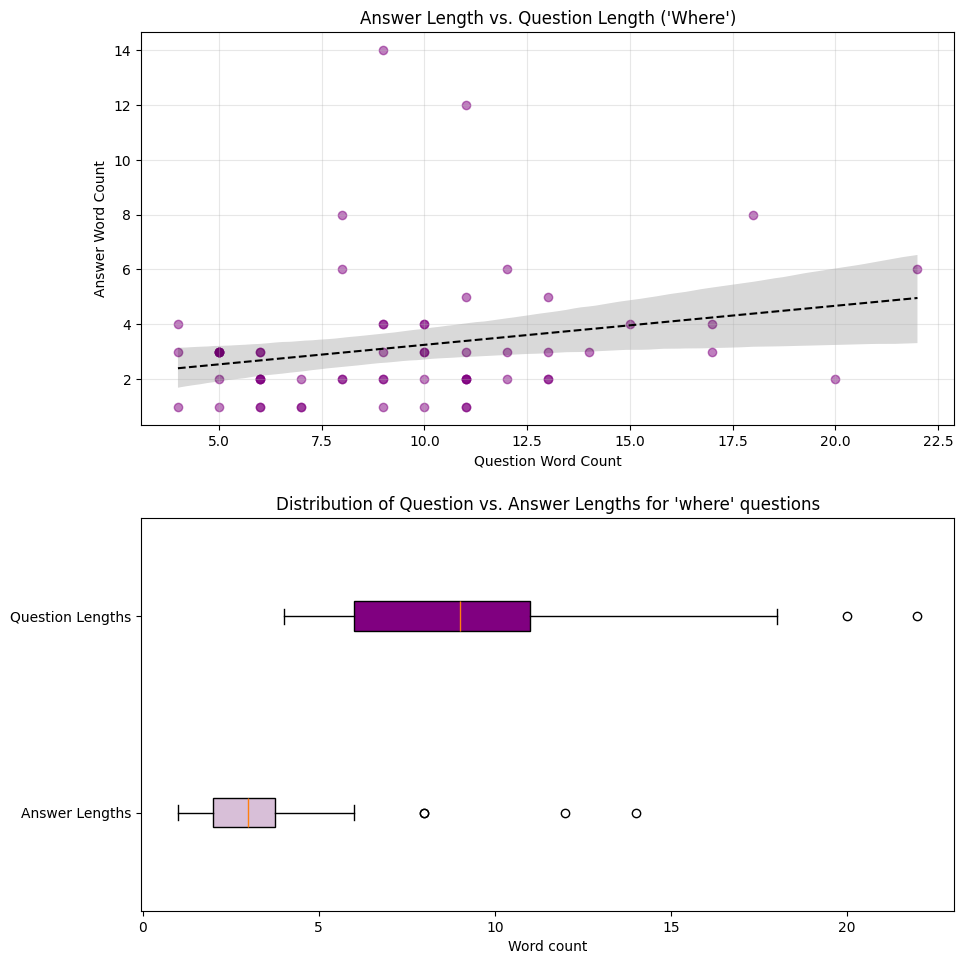


Random Sample (5) of 'where' Questions:


,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword
662,662,Where is the entrance to the Chamber of Secrets?,"In the second-floor girl's bathroom, also known as Moaning Myrtle's bathroom.","[where, be, entrance, chamber, secret]","[secondfloor, girl, bathroom, also, know, moan, myrtle]","[where, be, entrance, chamber, secret, secondfloor, girl, bathroom, also, know, moan, myrtle]",[where]
655,655,What is the platform at King's Cross Station where Hogwarts students catch the Hogwarts Express called?,Platform 9 ¾,"[what, be, platform, king, cross, station, where, hogwarts, student, catch, express, call]",[platform],"[what, be, platform, king, cross, station, where, hogwarts, student, catch, express, call]","[what, where]"
1060,1060,Where in Kings Cross Station does the Hogwarts Express stop?,Platform 9 and ¾.,"[where, king, cross, station, do, hogwarts, express, stop]",[platform],"[where, king, cross, station, do, hogwarts, express, stop, platform]",[where]
869,869,"In the book, where do Hermione Granger’s parents move to?",Australia,"[book, where, do, hermione, granger, parent, move]",[australia],"[book, where, do, hermione, granger, parent, move, australia]",[where]
65,65,Where can dark cloud constellations be most easily seen?,The Southern Hemisphere.,"[where, can, dark, cloud, constellation, easily, see]","[southern, hemisphere]","[where, can, dark, cloud, constellation, easily, see, southern, hemisphere]",[where]


----------------------------------------------------------------------


In [47]:
q_keyword = "where"
where_q_metrics = eda.calculate_keyword_metrics(q_keyword, df_for_analysis)
eda.display_keyword_analysis(where_q_metrics, n_samples)

In [48]:
eda.print_keyword_ngrams(df_for_analysis['question'], "where")


Analyzing common phrases (n-grams) starting with 'where' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'where':
- 'where is': 14
- 'where is the': 12
- 'where did': 9
- 'where do': 8
- 'where does': 8
- 'where was': 5
- 'where are': 4
- 'where can': 3
- 'where was harry': 3
- 'where are the': 2


In [49]:
# Using a custom list of stop words.
stop_words = ['is', 'did', 'do', 'does', 'was', 'are', 'can', 'the', 'to']
eda.print_keyword_ngrams(df_for_analysis['question'], "where",stop_words=stop_words)


Analyzing common phrases (n-grams) starting with 'where' in this set of questions:
Using stop_words: ['is', 'did', 'do', 'does', 'was', 'are', 'can', 'the', 'to']
Top 10 common n-grams starting with 'where':
- 'where harry': 8
- 'where harry potter': 5
- 'where entrance': 4
- 'where entrance chamber': 3
- 'where best': 2
- 'where best place': 2
- 'where dumbledore': 2
- 'where find': 2
- 'where find them': 2
- 'where first': 2


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-62-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.2 Quick Links</a>

### 7.2.5. What do "when" questions look like?

## Analysis for Keyword: 'WHEN'

Number of Questions: 57 (5.3% of total)

Descriptive Statistics for Question and Answer lengths (word count):


,Question Length,Answer Length
Mean,11.96,2.82
Median,11.00,2.00
Std Dev,6.15,2.52
Min,4.00,1.00
Max,27.00,13.00
Skew,0.74,2.19



Correlation between Question and Answer Length:
* Interpretation: Not statistically significant (r=0.092)
* Pearson's r = 0.092, P-value = 0.498

Scatter Plot with Regression Line:


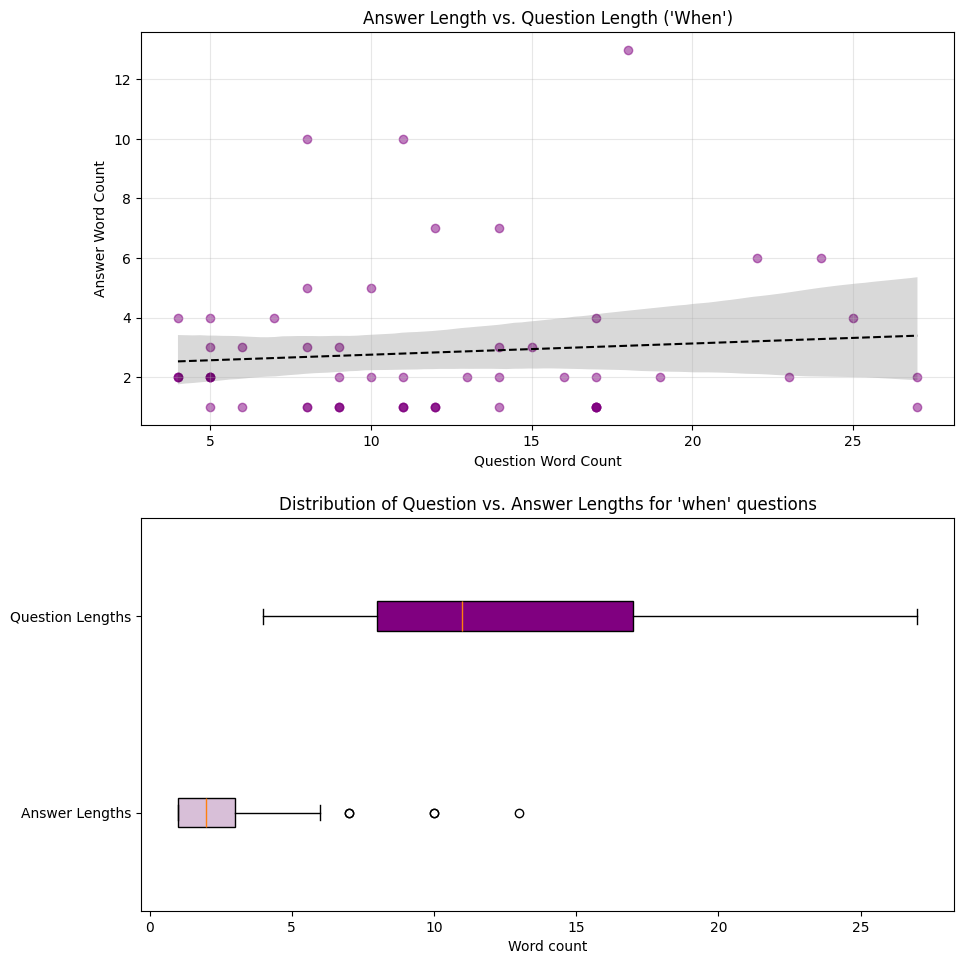


Random Sample (5) of 'when' Questions:


,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword
1,1,When was Hogwarts founded?,10th century,"[when, be, hogwarts, found]","[th, century]","[when, be, hogwarts, found, th, century]",[when]
730,730,What kind of pest repellant was Hagrid looking for when saw Harry in Knockturn Alley?,Flesh-Eating Slugs,"[what, kind, pest, repellant, be, hagrid, look, when, saw, harry, knockturn, alley]","[flesheating, slug]","[what, kind, pest, repellant, be, hagrid, look, when, saw, harry, knockturn, alley, flesheating, slug]","[what, when]"
806,806,What happens when you touch a Wiggentree?,Protection from Dark Creatures,"[what, happen, when, touch, wiggentree]","[protection, dark, creature]","[what, happen, when, touch, wiggentree, protection, dark, creature]","[what, when]"
237,237,When was the Golden Snidget first introduced into the game of Quidditch?,1269,"[when, be, golden, snidget, first, introduce, game, quidditch]",[],"[when, be, golden, snidget, first, introduce, game, quidditch]",[when]
275,275,When is Neville's birthday?,July 30,"[when, be, nevilles, birthday]",[july],"[when, be, nevilles, birthday, july]",[when]


----------------------------------------------------------------------


In [50]:
q_keyword = "when"
when_q_metrics = eda.calculate_keyword_metrics(q_keyword, df_for_analysis)
eda.display_keyword_analysis(when_q_metrics, n_samples)

In [51]:
eda.print_keyword_ngrams(df_for_analysis['question'], "when")


Analyzing common phrases (n-grams) starting with 'when' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'when':
- 'when was': 10
- 'when he': 7
- 'when did': 6
- 'when harry': 6
- 'when is': 3
- 'when was the': 3
- 'when did the': 2
- 'when harry arrives': 2
- 'when he decided': 2
- 'when is harry': 2


In [52]:
# Using a custom list of stop words.
stop_words = ['was', 'he', 'did', 'is', 'the', 'it', 'got', 'they']
eda.print_keyword_ngrams(df_for_analysis['question'], "when",stop_words=stop_words)


Analyzing common phrases (n-grams) starting with 'when' in this set of questions:
Using stop_words: ['was', 'he', 'did', 'is', 'the', 'it', 'got', 'they']
Top 10 common n-grams starting with 'when':
- 'when harry': 9
- 'when decided': 2
- 'when decided to': 2
- 'when first': 2
- 'when harry arrives': 2
- 'when harry birthday': 2
- 'when magical': 2
- 'when magical creature': 2
- 'when neville': 2
- 'when added': 1


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-62-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.2 Quick Links</a>

## 7.3 Questions that do not have factual recall keywords

The 'factual recall keywords' is not exhaustive. So looking at the questions with an 'N/A' tag can help us:
1. Determine if any other keywords should be added to the list added to the list that we might not have caught this time.
2. Is there a pattern in the remaining questions? what kind of questions are they? 
3. Are these open-ended type questions? e.g."Why....?" or "Would...?"

We can start looking at the tokens specific to this subset of the data frame and how frequently they occur.

#### Section 7.3 quick links

[7.3.1. What do the "which" questions look like?](#731-what-do-the-which-questions-look-like)<br>
[7.3.2. What do the "who" questions look like?](#732-what-do-the-why-questions-look-like)<br>
[7.3.3. What do the "how" questions look like?](#733-what-do-the-how-type-questions-look-like)<br>
[7.3.4. How many questions contain multiple keywords? ](#734-how-many-questions-contain-multiple-keywords)<br>
[7.3.5. What do the remaining "N/A" questions look like? ](#735-what-do-the-remaining-na-questions-look-like)<br>
[7.3.6. Plan of action ](#736-plan-of-action)

In [53]:
# What are the common tokens in the N/A tagged questions?

# A. Filter the relevant questions where the 'factual_recall_keyword' is 'N/A'
q_filtered_df = trivia_keywords_df[trivia_keywords_df['factual_recall_keyword']=='N/A']
q_filtered_df.sample(10)

,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword
898,Which spell causes objects to swell in size?,Engorgio,"[which, spell, cause, object, swell, size]",[engorgio],"[which, spell, cause, object, swell, size, engorgio]",N/A
748,Which Ghost haunts the Girls' Bathroom at Hogwarts?,"""Moaning"" Myrtle Warren","[which, ghost, haunt, girls, bathroom, hogwarts]","[moan, myrtle, warren]","[which, ghost, haunt, girls, bathroom, hogwarts, moan, myrtle, warren]",N/A
952,Ron was jealous because Hermione went to the Yule Ball with whom?,Viktor Krum,"[ron, be, jealous, hermione, go, yule, ball, whom]","[viktor, krum]","[ron, be, jealous, hermione, go, yule, ball, whom, viktor, krum]",N/A
382,How long did the longest Quidditch game last?,Six months,"[how, long, do, quidditch, game, last]","[six, month]","[how, long, do, quidditch, game, last, six, month]",N/A
508,Why would you cast Alohomora?,Unlock a door.,"[why, would, cast, alohomora]","[unlock, door]","[why, would, cast, alohomora, unlock, door]",N/A
453,How should your completed Scintillation Solution look?,Sparkling.,"[how, should, complete, scintillation, solution, look]",[sparkle],"[how, should, complete, scintillation, solution, look, sparkle]",N/A
135,"On his first ride aboard the Hogwarts Express, whose card did Harry get with his chocolate frog?",Dumbledore,"[first, ride, aboard, hogwarts, express, whose, card, do, harry, get, chocolate, frog]",[dumbledore],"[first, ride, aboard, hogwarts, express, whose, card, do, harry, get, chocolate, frog, dumbledore]",N/A
322,Which incantation cancels all spell effects?,Finite Incantatem,"[which, incantation, cancel, spell, effect]","[finite, incantatem]","[which, incantation, cancel, spell, effect, finite, incantatem]",N/A
40,How is Quodpot different from Quidditch?,The ball explodes,"[how, be, quodpot, different, quidditch]","[ball, explodes]","[how, be, quodpot, different, quidditch, ball, explodes]",N/A
369,How does one ward off a Dementor?,The Patronus Charm.,"[how, do, one, ward, dementor]","[patronus, charm]","[how, do, one, ward, dementor, patronus, charm]",N/A


In [54]:
# B. Count the occurence of each question token

# 1. create a copy so original df is not modified.
na_frq_df = q_filtered_df[['question', 'question tokens']].copy()

# 2. Use  the explode method to expand the list into individual column entries:
na_q_df = na_frq_df.explode('question tokens')

# 3. Now we can count values of the each token occurence in the `question tokens` column:
na_q_counts = na_q_df['question tokens'].value_counts()

# 3. print results
# Rename the index and values columns for clarity:
na_q_counts.index.name = "keyword"
na_q_counts.name = "Frequency"
total_na_q = q_filtered_df.shape[0]

print(f'* There are a total of {total_na_q} questions that are tagged as "N/A" in the "factual_recall_keywords" column.\n')
print("* Summary of the 'N/A' question keyword tokens (cutoff to display only with counts > 10): \n")
print(na_q_counts[na_q_counts>10])

# print percentage of 'which' and 'why' keywords:
which_q_percent_of_na = (na_q_counts['which'] / total_na_q) * 100
why_q_percent_of_na =  (na_q_counts['why'] / total_na_q) * 100

print(f"\n* Percentage of 'which' questions in the 'N/A' filtered dataset: {which_q_percent_of_na: .1f}%")
print(f"* Percentage of 'why' questions in the 'N/A' filtered dataset: {why_q_percent_of_na: .1f}%")

* There are a total of 283 questions that are tagged as "N/A" in the "factual_recall_keywords" column.

* Summary of the 'N/A' question keyword tokens (cutoff to display only with counts > 10): 

keyword
which        188
be           123
do            67
how           61
many          30
spell         25
use           25
hogwarts      22
harry         22
follow        22
quidditch     21
potion        21
charm         15
would         14
why           12
one           12
have          11
first         11
plant         11
Name: Frequency, dtype: int64

* Percentage of 'which' questions in the 'N/A' filtered dataset:  66.4%
* Percentage of 'why' questions in the 'N/A' filtered dataset:  4.2%


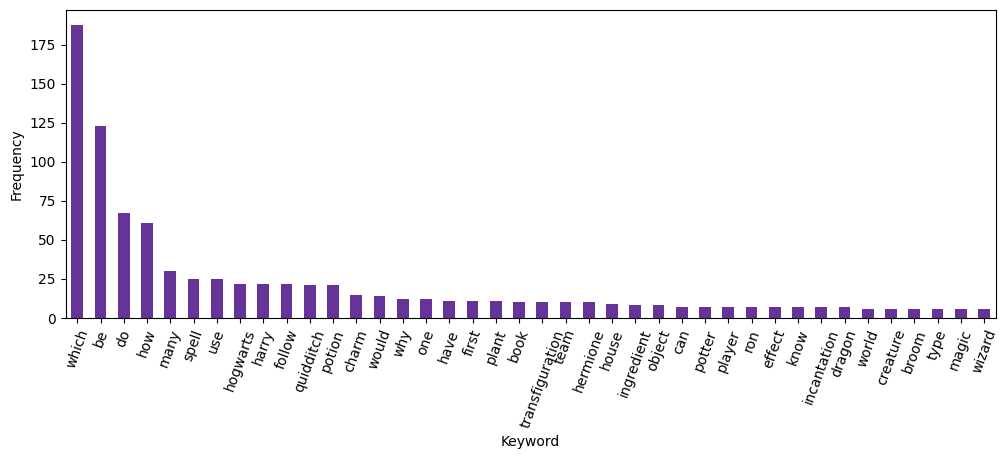

In [55]:
# Filter for values greater than a threshold so the chart isn't cluttered by the tail
threshold = 5
high_frequency_tokens = na_q_counts[na_q_counts > threshold]

high_frequency_tokens.plot(kind='bar', figsize=(12,4), color='rebeccapurple')
plt.xlabel('Keyword')
plt.ylabel('Frequency')
# plt.title(f"Figure {figure_count}. Kewyords that occur with a frequency greater then {frequency_cutoff} in the dataset (question and answer combined)")
plt.xticks(rotation=70)
plt.show()

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-63-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.3 Quick Links</a>

### 7.3.1. What do the "which" questions look like?

## Analysis for Keyword: 'WHICH'

Number of Questions: 194 (17.9% of total)

Descriptive Statistics for Question and Answer lengths (word count):


,Question Length,Answer Length
Mean,10.22,2.14
Median,9.00,2.00
Std Dev,3.74,1.50
Min,4.00,1.00
Max,24.00,9.00
Skew,1.51,2.17



Correlation between Question and Answer Length:
* Interpretation: Statistically significant (correlation is Very Weak)
* Pearson's r = 0.150, P-value = 0.036

Scatter Plot with Regression Line:


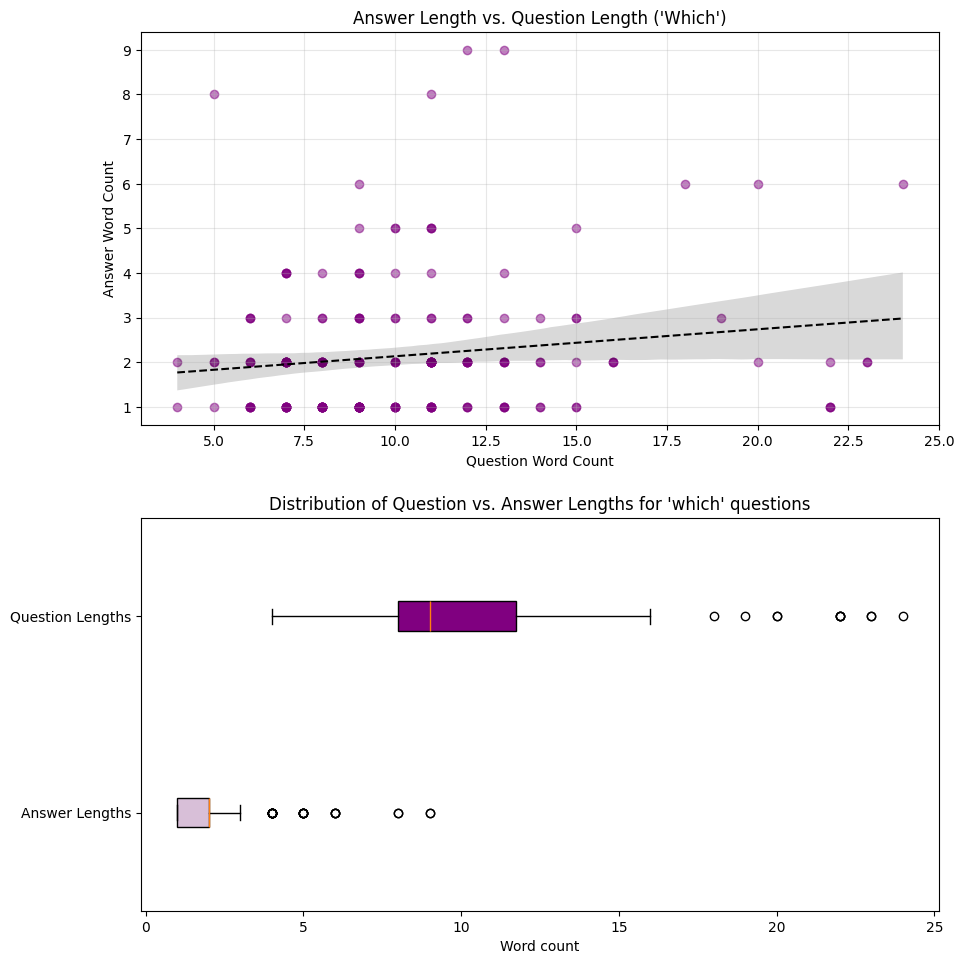


Random Sample (5) of 'which' Questions:


,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword
1007,1007,Which incantation banishes an object?,Depulso,"[which, incantation, banishes, object]",[depulso],"[which, incantation, banishes, object, depulso]",N/A
625,625,Which of the plants is prone to slapping people in the face?,Bouncing Bulbs,"[which, plant, be, prone, slap, people, face]","[bounce, bulb]","[which, plant, be, prone, slap, people, face, bounce, bulb]",N/A
1080,1080,Which of these plants are prone to slapping people in the face?,Bouncing Bulbs,"[which, plant, be, prone, slap, people, face]","[bounce, bulb]","[which, plant, be, prone, slap, people, face, bounce, bulb]",N/A
279,279,Screechsnaps are capable of doing which of the following?,Move & Make Noise,"[screechsnaps, be, capable, which, follow]","[move, make, noise]","[screechsnaps, be, capable, which, follow, move, make, noise]",N/A
246,246,Which potion grants the drinker incredible luck?,Felix Felicis,"[which, potion, grant, drinker, incredible, luck]","[felix, felicis]","[which, potion, grant, drinker, incredible, luck, felix, felicis]",N/A


----------------------------------------------------------------------


In [56]:
q_keyword = "which"
which_q_metrics = eda.calculate_keyword_metrics(q_keyword, df_for_analysis)
eda.display_keyword_analysis(which_q_metrics, n_samples)

In [57]:
eda.print_keyword_ngrams(df_for_analysis['question'],'which',(2,4))


Analyzing common phrases (n-grams) starting with 'which' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'which':
- 'which of': 65
- 'which of these': 38
- 'which of the': 25
- 'which of the following': 22
- 'which of these is': 11
- 'which is': 10
- 'which of these spells': 8
- 'which potion': 7
- 'which spell': 7
- 'which incantation': 6


In [58]:
eda.print_keyword_ngrams(df_for_analysis['question'],"which",(5,10))


Analyzing common phrases (n-grams) starting with 'which' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'which':
- 'which of the following is': 8
- 'which of these is not': 6
- 'which of the following is not': 5
- 'which of these spells is': 4
- 'which of these is an': 3
- 'which of these is not type': 3
- 'which of these is not type of': 3
- 'which of these scenarios would': 3
- 'which of these scenarios would you': 3
- 'which of these scenarios would you use': 3


**Observations: "Which" type questions**

- Marjority of the 'N/A' tagged questions are `which` type questions (194 questions). 
- In general we can expect `which` questions to be open-ended questions, but a closer look at these questions in the dataset confirms that they are also another form of a `factual recall question`.
- This in turn means that, with the inclusion of `which` into the keyword list, the vast majority of the questions (97%) can be considered as 'factual recall type questions' within this dataset.
- The longest answer is a list of characters full names.
- The sampled question generally seem to be difficult.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-63-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.3 Quick Links</a>

### 7.3.2. What do the "why" questions look like?

## Analysis for Keyword: 'WHY'

Number of Questions: 12 (1.1% of total)

Descriptive Statistics for Question and Answer lengths (word count):


,Question Length,Answer Length
Mean,9.33,5.67
Median,8.50,4.00
Std Dev,2.84,4.19
Min,5.00,2.00
Max,15.00,14.00
Skew,0.88,1.36



Correlation between Question and Answer Length:
* Interpretation: Not statistically significant (r=-0.059)
* Pearson's r = -0.059, P-value = 0.856

Scatter Plot with Regression Line:


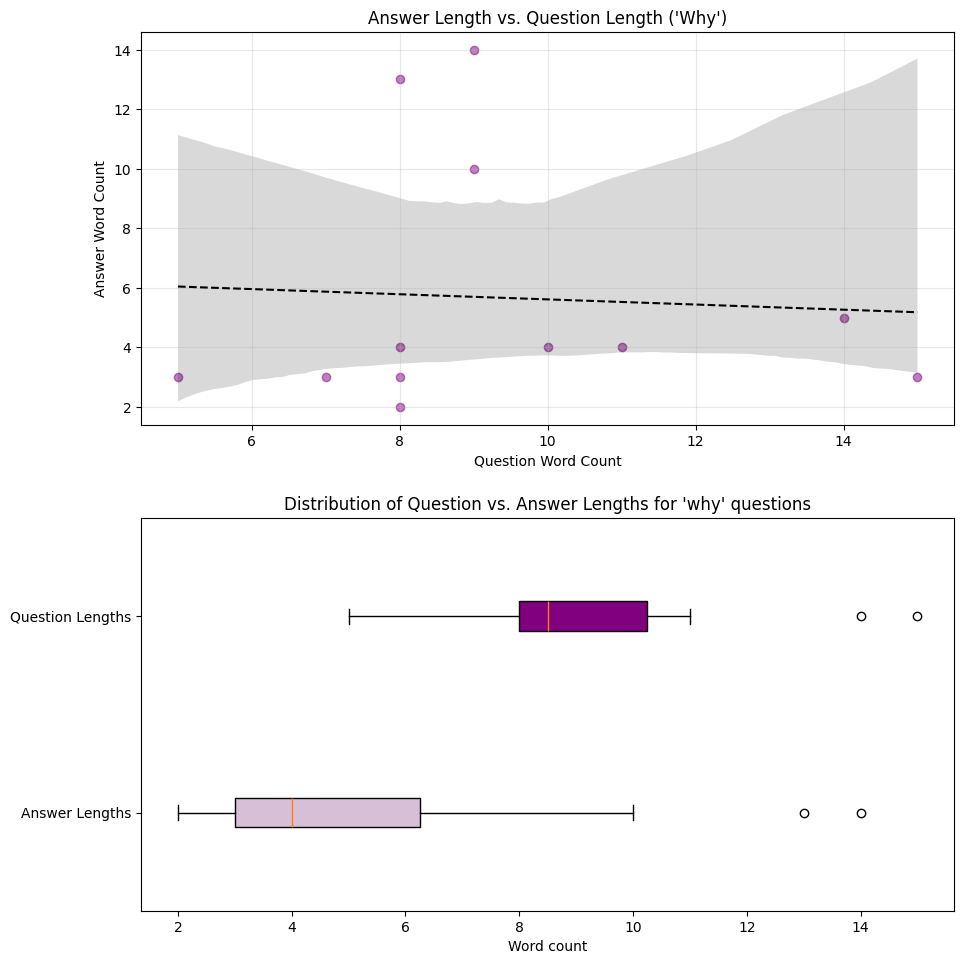


Random Sample (5) of 'why' Questions:


,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword
673,673,Why does Neville Longbottom faint in Herbology class?,"His earmuffs were loose, so he heard the cry of the baby mandrake.","[why, do, neville, longbottom, faint, herbology, class]","[earmuff, be, loose, heard, cry, baby, mandrake]","[why, do, neville, longbottom, faint, herbology, class, earmuff, be, loose, heard, cry, baby, mandrake]",N/A
9,9,Why did student initially think Harry was the Heir of Slytherin?,He can speak Parseltongue,"[why, do, student, initially, think, harry, be, heir, slytherin]","[can, speak, parseltongue]","[why, do, student, initially, think, harry, be, heir, slytherin, can, speak, parseltongue]",N/A
960,960,Why did Hermione miss the lesson on Cheering Charms?,Draco's cruel behavior led her to miss the class.,"[why, do, hermione, miss, lesson, cheer, charm]","[draco, cruel, behavior, lead, miss, class]","[why, do, hermione, miss, lesson, cheer, charm, draco, cruel, behavior, lead, class]",N/A
117,117,Why would you need to switch brooms midair?,Broom failure,"[why, would, need, switch, broom, midair]","[broom, failure]","[why, would, need, switch, broom, midair, failure]",N/A
365,365,Why did students think Harry was the Heir of Slytherin?,He can speak Parseltongue.,"[why, do, student, think, harry, be, heir, slytherin]","[can, speak, parseltongue]","[why, do, student, think, harry, be, heir, slytherin, can, speak, parseltongue]",N/A


----------------------------------------------------------------------


In [59]:
q_keyword = "why"
why_q_metrics = eda.calculate_keyword_metrics(q_keyword, df_for_analysis)
eda.display_keyword_analysis(why_q_metrics, n_samples)

In [60]:
eda.print_keyword_ngrams(df_for_analysis['question'],'why', (2,4),5)


Analyzing common phrases (n-grams) starting with 'why' in this set of questions:
Using stop_words: None
Top 5 common n-grams starting with 'why':
- 'why did': 6
- 'why did the': 2
- 'why did the werewolf': 2
- 'why would': 2
- 'why would you': 2


In [61]:
stop_words = ['did', 'the', 'would' ,'do', 'does']
eda.print_keyword_ngrams(df_for_analysis['question'],'why',(2,3), 3, stop_words=stop_words)


Analyzing common phrases (n-grams) starting with 'why' in this set of questions:
Using stop_words: ['did', 'the', 'would', 'do', 'does']
Top 3 common n-grams starting with 'why':
- 'why werewolf': 2
- 'why werewolf code': 2
- 'why you': 2


**Observations:"why" type questions**
- From the token count we know that there are 12 `why` type questions in the filtered dataset and the full dataset (1% of the total).
- The answers to these questions are generally long, ranging between 13 to 87 words in general.
- These questions seem more open-ended with answers that can vary for players and would require interpretation.

[[Back to TOC]](#table-of-contents)

### 7.3.3. What do the "how" type questions look like?

## Analysis for Keyword: 'HOW'

Number of Questions: 70 (6.5% of total)

Descriptive Statistics for Question and Answer lengths (word count):


,Question Length,Answer Length
Mean,10.47,3.41
Median,9.00,2.00
Std Dev,4.67,4.70
Min,4.00,1.00
Max,27.00,25.00
Skew,1.30,3.14



Correlation between Question and Answer Length:
* Interpretation: Not statistically significant (r=0.049)
* Pearson's r = 0.049, P-value = 0.687

Scatter Plot with Regression Line:


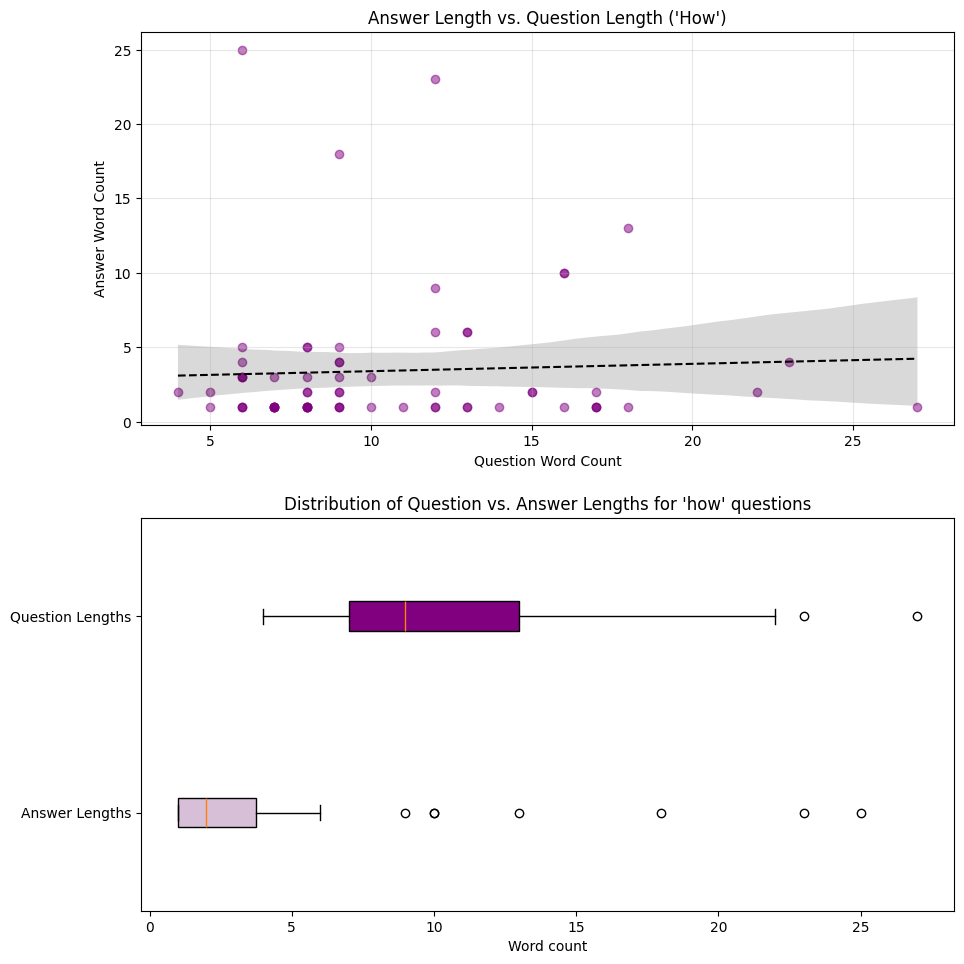


Random Sample (5) of 'how' Questions:


,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword
629,629,How is Bellatrix related to Tonks?,Tonks is Bellatrix's niece.,"[how, be, bellatrix, related, tonks]","[tonks, be, bellatrixs, niece]","[how, be, bellatrix, related, tonks, bellatrixs, niece]",N/A
555,555,How many Principal Exceptions are there to Gamp's Law of Elemental Transfiguration?,Five,"[how, many, principal, exception, be, gamps, law, elemental, transfiguration]",[five],"[how, many, principal, exception, be, gamps, law, elemental, transfiguration, five]",N/A
521,521,How many Muggles see the flying Ford Anglia as Harry and Ron make their way to school?,Seven,"[how, many, muggles, see, fly, ford, anglia, harry, ron, make, way, school]",[seven],"[how, many, muggles, see, fly, ford, anglia, harry, ron, make, way, school, seven]",N/A
271,271,How do you tell if a door is Imperturbable?,Chuck stuff at it,"[how, do, tell, door, be, imperturbable]","[chuck, stuff]","[how, do, tell, door, be, imperturbable, chuck, stuff]",N/A
389,389,How long was You-Know-Who in power?,11 Years,"[how, long, be, youknowwho, power]",[year],"[how, long, be, youknowwho, power, year]",N/A


----------------------------------------------------------------------


In [62]:
q_keyword = "how"
how_q_metrics = eda.calculate_keyword_metrics(q_keyword, df_for_analysis)
eda.display_keyword_analysis(how_q_metrics, n_samples)

In [63]:
eda.print_keyword_ngrams(df_for_analysis['question'],'how',(2,4))


Analyzing common phrases (n-grams) starting with 'how' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'how':
- 'how many': 31
- 'how do': 7
- 'how old': 6
- 'how does': 5
- 'how is': 5
- 'how did': 4
- 'how many times': 4
- 'how old was': 4
- 'how do you': 3
- 'how long': 3


In [64]:
stop_words = ['is', 'do', 'does', 'did', 'was', 'do']
eda.print_keyword_ngrams(df_for_analysis['question'],'how',(2,4), 5, stop_words=stop_words)


Analyzing common phrases (n-grams) starting with 'how' in this set of questions:
Using stop_words: ['is', 'do', 'does', 'did', 'was', 'do']
Top 5 common n-grams starting with 'how':
- 'how many': 31
- 'how old': 6
- 'how many times': 4
- 'how long': 3
- 'how many players': 3


**Observations: "how" type questions**: 


The "How" questions are a bit of a mixed bag. The distribution of the answer lengths is slightly larger than the typical factual recall type questions. We can see that in the box plot and also compare the descriptive statistics. In the typical factual recall questions the median and mean are close (approximately 2 words) and the standard deviation is also around 2. For the "how" questions, although many questions are short 1-2 words (median =2 words) the mean is higher (3.4 words) and double the standard deviation (std =4) with a skew of 3 (long tail towards the longer answers, right side of the graph). 

Looking at the N-grams, especially after the typical stop words were removed - majority seem to be factual recall type (how many, how old, how long). However the random sample from the "how" questions (e.g. Q282.How did Fred and George get the money to open their shop? A: They won a bet on the Quidditch World Cup), the unfiltered N-grams ("how do.." and its variations) and the longer tail indicate presence of open-ended questions.

At this stage, the "how" questions can be considered "factual-recall" type questions and will be typed as such. This does miss nuanced questions so during the manual review / data quality checks specific "how" questions that don't fit the trend can be classified as open - ended.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-63-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.3 Quick Links</a>

### 7.3.4. How many questions contain multiple keywords?

In [65]:
## How many questions have multiple keywords?
condition_1 = trivia_keywords_df['factual_recall_keyword']!='N/A'
condition_2 = trivia_keywords_df['factual_recall_keyword'].str.len() > 1

filter = trivia_keywords_df[condition_1 & condition_2]
percentage = (filter['question'].count() / trivia_keywords_df.shape[0]) * 100
print(f"There are {filter.shape[0]} ({percentage: .0f}% of total) questions with multiple factual type keywords. \n")
print("Data frame preview: ")
filter.sample(20)

There are 139 ( 13% of total) questions with multiple factual type keywords. 

Data frame preview: 


,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword
867,What is the name of the spell used to conjure the Patronus Charm?,Expecto Patronum,"[what, be, name, spell, use, conjure, patronus, charm]","[expecto, patronum]","[what, be, name, spell, use, conjure, patronus, charm, expecto, patronum]","[what, name]"
1074,What is the name of the Apparition instructor who comes to Hogwarts in Harry’s sixth year?,Wilkie Twycross.,"[what, be, name, apparition, instructor, who, come, hogwarts, harrys, sixth, year]","[wilkie, twycross]","[what, be, name, apparition, instructor, who, come, hogwarts, harrys, sixth, year, wilkie, twycross]","[what, name, who]"
708,"What was the name of the house where the Weasleys once lived, which became a second home to Harry Potter?",The Burrow,"[what, be, name, house, where, weasleys, live, which, become, second, home, harry, potter]",[burrow],"[what, be, name, house, where, weasleys, live, which, become, second, home, harry, potter, burrow]","[what, name, where]"
599,What is the name of Hagrid's pet dragon?,Norbert,"[what, be, name, hagrids, pet, dragon]",[norbert],"[what, be, name, hagrids, pet, dragon, norbert]","[what, name]"
909,What name does Buckbeak get after being saved from execution?,Witherwings,"[what, name, do, buckbeak, get, saved, execution]",[witherwings],"[what, name, do, buckbeak, get, saved, execution, witherwings]","[what, name]"
209,What do all the hands on the Weasleys’s magical clock point to when Harry gets to the Burrow?,“Mortal peril”,"[what, do, hand, weasleyss, magical, clock, point, when, harry, get, burrow]","[mortal, peril]","[what, do, hand, weasleyss, magical, clock, point, when, harry, get, burrow, mortal, peril]","[what, when]"
239,"What is the middle name of Harry's daughter, Lily?",Luna,"[what, be, middle, name, harrys, daughter, lily]",[luna],"[what, be, middle, name, harrys, daughter, lily, luna]","[what, name]"
902,What is the name of the Weasley twins’ magic joke shop?,Weasleys’ Wizard Wheezes,"[what, be, name, weasley, twin, magic, joke, shop]","[weasleys, wizard, wheeze]","[what, be, name, weasley, twin, magic, joke, shop, weasleys, wizard, wheeze]","[what, name]"
609,What is the name of the Weasley twins' magical joke shop?,Weasleys' Wizard Wheezes.,"[what, be, name, weasley, twin, magical, joke, shop]","[weasleys, wizard, wheeze]","[what, be, name, weasley, twin, magical, joke, shop, weasleys, wizard, wheeze]","[what, name]"
234,What did Hermione use to help heal Ron's arm when it got splinched?,Essence of Dittany,"[what, do, hermione, use, help, heal, ron, arm, when, get, splinched]","[essence, dittany]","[what, do, hermione, use, help, heal, ron, arm, when, get, splinched, essence, dittany]","[what, when]"


Not surprising that 'what' and 'name' appear together several times, with 'where' popping up too — so there's some overlap between these keywords. However, in these overlapping cases, the question always starts with 'what' — the dominant keyword.

It's fairly clear that the majority of questions in this dataset are factual recall (74%), and among those, what questions (49%) related to objects, events, facts, and character names are the most common.

>**NOTE**:
>A second pass that includes combinations of two or more keywords would be useful. Considering counts without overlap?
<br>

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-63-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.3 Quick Links</a>

### 7.3.5 What do the remaining 'N/A' questions look like?

We will use the `q_filter_df` because this dataframe only contain the questions that were tagged as 'N/A' in the 'factual_recall_keywords' column. Here we only want columns that do not have `which` or `why` as a keyword.

In [66]:
# Filter condition:
remaining_na_condition = q_filtered_df['question tokens'].apply(
    lambda x: all(word not in x for word in ['why', 'which','how'])
)
remaining_na_questions_df = q_filtered_df.loc[remaining_na_condition]

# Display results
print("Number of questions that are not 'which' or 'why' type but tagged as 'N/A': ", remaining_na_questions_df.shape[0])
print("Sample of questions: \n")
remaining_na_questions_df

Number of questions that are not 'which' or 'why' type but tagged as 'N/A':  23
Sample of questions: 



,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword
28,"""Lemon Drop"" is the password to whose office?",Dumbledore,"[lemon, drop, be, password, whose, office]",[dumbledore],"[lemon, drop, be, password, whose, office, dumbledore]",N/A
103,Did Muggles use ancient runes as well?,They did.,"[do, muggles, use, ancient, rune, well]",[do],"[do, muggles, use, ancient, rune, well]",N/A
135,"On his first ride aboard the Hogwarts Express, whose card did Harry get with his chocolate frog?",Dumbledore,"[first, ride, aboard, hogwarts, express, whose, card, do, harry, get, chocolate, frog]",[dumbledore],"[first, ride, aboard, hogwarts, express, whose, card, do, harry, get, chocolate, frog, dumbledore]",N/A
355,True or false: Harry Potter and the Deathly Hallows: Part Two is the shortest Harry Potter movie.,True! The run time is just 130 minutes.,"[true, false, harry, potter, deathly, hallows, part, two, be, short, movie]","[true, run, time, be, minute]","[true, false, harry, potter, deathly, hallows, part, two, be, short, movie, run, time, minute]",N/A
380,Where's one place you would not find any gnomes?,Antarctica,"[wheres, one, place, would, find, gnome]",[antarctica],"[wheres, one, place, would, find, gnome, antarctica]",N/A
489,Fill in the blank: Petrificus Totalus is the incantation for the Full Body-Bind curse.,Bind (Got this in the Petrificus Totalus lesson.),"[fill, blank, petrificus, totalus, be, incantation, full, bodybind, curse]","[bind, get, petrificus, totalus, lesson]","[fill, blank, petrificus, totalus, be, incantation, full, bodybind, curse, bind, get, lesson]",N/A
535,True or false: This is the longest movie in the franchise.,"False! Harry Potter and the Chamber of Secrets is the longest movie, at 161 minutes.","[true, false, be, long, movie, franchise]","[false, harry, potter, chamber, secret, be, long, movie, minute]","[true, false, be, long, movie, franchise, harry, potter, chamber, secret, minute]",N/A
565,Wich of these creatures is notable proud and easy to offend if not treated politely?,Hippogriff,"[wich, creature, be, notable, proud, easy, offend, treat, politely]",[hippogriff],"[wich, creature, be, notable, proud, easy, offend, treat, politely, hippogriff]",N/A
591,The Bouncy Bulb is extremely difficult to...,Pot.,"[bouncy, bulb, be, extremely, difficult]",[pot],"[bouncy, bulb, be, extremely, difficult, pot]",N/A
603,"Whose teeth did Nearly Headless Nick accidentally turn into tusks, leading to his death?",Lady Grieve,"[whose, teeth, do, nearly, headless, nick, accidentally, turn, tusk, lead, death]","[lady, grieve]","[whose, teeth, do, nearly, headless, nick, accidentally, turn, tusk, lead, death, lady, grieve]",N/A



##### What are the remaining questions like?

- The use other keywords such as 'whose', 'can', 'did', 'does', 'do' , 'is it',  'wheres', 'whom' (variation not caught in list). Some of these words can be added to the list e.g. "whom", "wheres", "whose" but the other words are very ambiguous and may introduce noise in the keywords.
- indicative statements instead of questions - e.g. "Dittany, mixed with this ingredient, can cure a Werewolf bite." Ans: "Powdered Silver"
- nonsensical questions (not for trivia), e.g. Q: "Will you serve the great nation of Peevesland, soldier?", Ans: "Sir, yes, sir!"
- 2x True / false type.
- 1x fill-in-the-blank, e.g. Q:"Fill in the blank: Petrificus Totalus is the incantation for the Full Body-Bind curse." Ans: "Bind (Got this in the Petrificus Totalus lesson.)" <- thre is an error here though - no blank given in the question and it is very unclear what is being asked.
x

##### What can we do with these remaining questions?

There are now only 23 questions that have a 'N/A' questions. 
Should these questions be modified so one of the `factual_recall_keywords` can be applied?  This would mean changing the question wording to lead with an appropriate `factual_recall_keyword` where possible. But that would reduce variety and nuance in the dataset even if, right now, these type are only a small percentage of the questions. This also makes the analysis / game more flexible towards expanding the trivia Q&A dataset in future project phases.


> NOTES: 
>- some questions are fill-in-the blanks (e.g q id 667: "The Bouncy Bulb is extremely difficult to ...")
>- others are random "fun" questions? e.g. (Q1271. "Will you serve the great nation of Peevesland, soldier?" - Ans: 'Sir, yes, sir!')
>- presented as statements (Q929: "Dittany, mixed with this ingredient, can cure a Werewolf bite.", Ans: "Powdered Silver")
>- Q.644 "Why did the Werewolf Code of Conduct fail?" and Q.1228 appear to be duplicates.
>- Q.437 - typo: should be "house-elf" instead of "house-eld"
>- Q.726 - seems to be a truncated multiple choice question.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-63-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.3 Quick Links</a>

### 7.3.6. Plan of Action

**Decision**: will not modify questions instead add additional keyword columns for other types of questions (open-ended, yes/no etc). 
    
So the **plan of action** is:

1. Filter/Remove: Identify and remove/flag 'Nonsensical' and known 'Problematic' (like the bad fill-in-the-blank and only one of its type) questions first.
2. Classify Yes/No: Check if the first word of the question is in your yes_no_keywords list. Tag as Yes/No.
3. Classify True/False: Check if answer text is 'True'/'False'. Also tag this as a Yes/No type.
4. Classify Factual Recall: Expand the factual_recall_keywords list and use it for tagging the dataset again (including what, who, where, when, which, whose, whom, wheres, name, how many etc.). Tag with Factual keyword.
5. Classify open-ended: Check if the first word is 'Why' or potentially 'How'<pending>. Tag as Explanatory.
6. Recheck remainder manually after tagging and decide what to do (tag unassigned? keep it flexible for future addition that way?
7. Determine the logic for then categorizing the questions using binary tag columns for each question type. Clarify logic for assigning tag. How will conflicts be handled when there are tags present from multiple question type categories? --> consider hierarchical, rule based approach.
8. With the addition of new columns, create a data dictionary of the finalized dataframe. Create the final data save checkpoint for the game version dataset to be used in the CLI MVP. Also create an accompanying data dictionary json file for the csv.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-63-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.3 Quick Links</a>

## 7.4. Corrleation summary: Q&A lengths filtered by question keyword

In [67]:
# Keywords list of which terms to summarize in the table
keywords_list = ['what', 'who', 'where', 'when', 'which', 'why', 'how']
# List of keywords that will be categorized as 'factual recall'
FR_keywords = ['what', 'who', 'where', 'when', 'which']
# Create a master summary table based on keyword lists using a custom function from teh eda_scripts module
full_keyword_summary_df = eda.create_comprehensive_summary_df(keywords_list, FR_keywords, df_for_analysis)
# Display the correlation summary table using a view helper function from the eda_scripts module
eda.display_correlation_summary(full_keyword_summary_df)
# full_keyword_summary_df.columns


Correlation Summary Table by Question Keywords:


,Question Keyword,question_type,Keyword Count,(%) of total,Mean Question Length,Mean Anwer Length,Pearson's r,P-value,Interpretation
0,what,Factual-Recall,531,48.940092,10.099812,2.548023,0.076,0.078,Not statistically significant (r=0.076)
4,which,Factual-Recall,194,17.880184,10.216495,2.144330,0.150,0.036,Statistically significant (correlation is Very Weak)
1,who,Factual-Recall,166,15.299539,9.572289,2.524096,0.104,0.184,Not statistically significant (r=0.104)
6,how,Non-Factual,70,6.451613,10.471429,3.414286,0.049,0.687,Not statistically significant (r=0.049)
2,where,Factual-Recall,62,5.714286,9.451613,3.177419,0.236,0.064,Not statistically significant (r=0.236)
3,when,Factual-Recall,57,5.253456,11.964912,2.824561,0.092,0.498,Not statistically significant (r=0.092)
5,why,Non-Factual,12,1.105991,9.333333,5.666667,-0.059,0.856,Not statistically significant (r=-0.059)


## 7.5. N-gram analysis

### 7.5.1. Top 20 n-grams in the questions
- custom method uses the raw question column and look at a range of n-grams and find top 20. (unlike earlier processing that used keyword columns)
- Uses countvecotrizer - explain why.
- findings

In [68]:
eda.print_common_ngrams(df_for_analysis['question'],(2,4), top_n=20)


Analyzing common phrases (n-grams) in this series:
Top 20 common n-grams:
- 'harry potter': 48
- 'does harry': 17
- 'sorcerer stone': 13
- 'ministry magic': 12
- 'magical creature': 11
- 'triwizard tournament': 11
- 'quidditch team': 10
- 'did harry': 9
- 'draco malfoy': 9
- 'harry potter series': 9
- 'potter series': 9
- 'chamber secrets': 8
- 'common room': 8
- 'did hermione': 8
- 'professor snape': 8
- 'harry ron': 7
- 'hermione granger': 7
- 'polyjuice potion': 7
- 'does hermione': 6
- 'fred george': 6


### 7.5.2. Top 20 n-grams in the answers

- custom method uses the raw answer column and look at a range of n-grams and find top 20. (unlike earlier processing that used keyword columns)
- Uses countvecotrizer - explain why.
- findings

In [69]:
eda.print_common_ngrams(df_for_analysis['answer'],(2,4), top_n=20)


Analyzing common phrases (n-grams) in this series:
Top 20 common n-grams:
- 'bloody baron': 8
- 'ministry magic': 6
- 'moaning myrtle': 6
- 'severus snape': 6
- 'sirius black': 6
- 'armando dippet': 5
- 'hermione granger': 5
- 'albus dumbledore': 4
- 'gilderoy lockhart': 4
- 'harry potter': 4
- 'horace slughorn': 4
- 'mimsy porpington': 4
- 'nicholas mimsy': 4
- 'nicholas mimsy porpington': 4
- 'patronus charm': 4
- 'wizard wheezes': 4
- '10th century': 3
- 'cho chang': 3
- 'chudley cannons': 3
- 'daily prophet': 3


### 7.5.3. N-gram analysis with TF-IDF
- cusotm function - uses keywords joined in a string to leverage the tokenizing already done by the custome tokenizer.
- TF-IDF vs. CountVectorizer - more nuance. Learn about obscure terms and overall importance of certain n-grams
- findings 

In [70]:
column_name = "answer tokens"

# Custom function
answer_tfidf_ngrams = eda.rank_ngrams_by_tfidf(df_for_analysis, column_name,(2,3))

# descriptive statistics
print('Descriptive statistics:\n', answer_tfidf_ngrams[['idf_score','summed_tfidf_score']].describe().round(2))

print('\n\nAnswer tokens n-grams sorted by rarity of n-gram (idf_score):\n\n', 
      answer_tfidf_ngrams.sort_values(by='idf_score', ascending=False).head(5))
print('\n\nAnswer tokens n-grams sorted by overall importance of n-gram (summed_tfidf_score):\n\n', 
      answer_tfidf_ngrams.sort_values(by='summed_tfidf_score', ascending=False).head(5))

Descriptive statistics:
        idf_score  summed_tfidf_score
count    1313.00             1313.00
mean        7.24                0.66
std         0.18                0.60
min         5.79                0.18
25%         7.30                0.30
50%         7.30                0.45
75%         7.30                1.00
max         7.30                8.00


Answer tokens n-grams sorted by rarity of n-gram (idf_score):

                           n-gram  idf_score  summed_tfidf_score
0                 ability change        7.3                0.58
843            oxford university        7.3                0.45
850         partially sever neck        7.3                0.58
849              partially sever        7.3                0.58
848  parseltongue lord voldemort        7.3                0.58


Answer tokens n-grams sorted by overall importance of n-gram (summed_tfidf_score):

                 n-gram  idf_score  summed_tfidf_score
118       bloody baron       5.79                8.

In [71]:
column_name = "question tokens"
question_tfidf_ngrams = eda.rank_ngrams_by_tfidf(df_for_analysis, column_name,(2,4))
question_tfidf_ngrams[['idf_score','summed_tfidf_score']].describe().round(2)

,idf_score,summed_tfidf_score
count,12448.00,12448.00
mean,7.24,0.32
std,0.22,0.36
min,2.62,0.15
25%,7.30,0.22
50%,7.30,0.27
75%,7.30,0.34
max,7.30,24.28


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 8. Content similarity analysis

Cosine similarity can give us another angle to understand the dataset. 

1. **Question-Answer pairwise comparison**:<br>
We can compare the similarity in the vocabulary of the questions to their answers. Because the answers are short and explicit and unlikely to rephrase the question, the similarity is likely to be low. We can confirm this by looking at the distribution of similarity scores. Any outliers would be interesting - possibly a flag for a closer review in case there is an error or if the question is too easy.

2. **Question-Question comparison**:<br>
By looking at the vocabulary shared among the questions can help understand diversity and identify common groupings (e.g. character, location, spells) which can be formalized through clustering to understand their relative sizes. This can help set a baseline for the dataset and further inform the phase 2 NER work. It will give an idea of the main entities / categories that can help focus the NER work regarding the custom categories to create for a deeper semantic understanding. Very high similarities could indicate almost identical question that weren't caught earlier and a flag for review.

3. **Answer-Answer comparison**:<br>
The answer vocabulary can similarly give an idea of what the common themes are and an idea of the dataset diversity and reveal more contextual and specific beyond the questions alone. 

4. **Question-Answer matrix comparison**:<br>
This would compare all questions to all answers. This could show how the vocabulary of a question relates to other answers in the dataset and not just its own answer. And vice versa for the answers. This can enhance the understanding of thematic groupings. Depending on the outcome of the first three comparison, this can be deferred to the next phase. 

The vocabulary here will be built by combining the tokens from the questions and answers. The vocabulary will use the `question tokens` and `answer tokens` columns since they contain the tokens generated from the custom tokenizer. A common TF-IDF vectorizer will ensure consistency (same features and IDF weights) so that results between the cosine similarity analyses are comparable against each other. We can consider a range of n-grams (1 to 3) to capture some common phrases to enrich the vocabulary. We can expect to see common bi-grams such as "Harry Potter" and "Professor Dumbledore". The tri-grams can capture more specific phrases such as parts of "Defense against Dark Arts".

**Setup a common vectorizer**:

In [72]:
# Key variables
column_name = 'combined_unique_tokens'
ngram_range = (1,3)
stop_words = [] # in case there are additional words.
# Default min_df and max_df

# 1. combine the combined unique keyword column into a string.
df_tfidf_cs = trivia_keywords_df.copy()
df_tfidf_cs['all_keywords_str'] = df_tfidf_cs[column_name].apply(lambda token_list: ' '.join(token_list))

# 2. Initialize the tf-idf vectorizer:
vectorizer = TfidfVectorizer(stop_words= stop_words, ngram_range= ngram_range)

# 3.Fit the vectorizer on the combined tokens
vectorizer.fit(df_tfidf_cs['all_keywords_str'])

TfidfVectorizer(ngram_range=(1, 3), stop_words=[])

**Fit the the vectorizer on the question and answer tokens columns**:

In [73]:
# # 4. convert the `question tokens` and `answer tokens` from a list of tokens to a string 
# df_tfidf_cs['question_tokens_str'] = df_tfidf_cs['question tokens'].apply(lambda token_list: ' '.join(token_list))
# df_tfidf_cs['answer_tokens_str'] = df_tfidf_cs['answer tokens'].apply(lambda token_list: ' '.join(token_list))

# # 5. Transform the columns with the vectorizer
# X_questions = vectorizer.transform(df_tfidf_cs['question_tokens_str'])
# Y_answers = vectorizer.transform(df_tfidf_cs['answer_tokens_str'])

X_questions, Y_answers = eda.transform_for_similarity_check(df_tfidf_cs, vectorizer)

Now we can proceed with our similarity analysis.

### 8.1. Question-Answer (Q-A) pairwise comparison

To buid the vocabulary, we would need to use to look at the vocabulary of both the question and answer. So we will fit the tf-idf vectorizer on both the questions and answers and then use cosine similarity score to compare the question to its score.

In [74]:
# 1. Create a full similarity matrix
full_qa_similarity_matrix = cosine_similarity(X_questions, Y_answers)
# 2. The pair-wise comparison of question and its answer = to the diagonal of the matrix
paired_qa_similarity = pd.Series(full_qa_similarity_matrix.diagonal(), index=df_for_analysis.index)
paired_qa_similarity.describe()

count    1085.000000
mean        0.012856
std         0.045872
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.398775
dtype: float64

In [75]:
df_for_analysis.head()

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword
0,0,What are the three European wizarding schools that participate in the Triwizard Tournament?,"Hogwarts, Beauxbatons, and Durmstrang.","[what, be, three, european, wizarding, school, participate, triwizard, tournament]","[hogwarts, beauxbatons, durmstrang]","[what, be, three, european, wizarding, school, participate, triwizard, tournament, hogwarts, beauxbatons, durmstrang]",[what]
1,1,When was Hogwarts founded?,10th century,"[when, be, hogwarts, found]","[th, century]","[when, be, hogwarts, found, th, century]",[when]
2,2,What is a Wronski Feint?,Pretending to dive for the Snitch,"[what, be, wronski, feint]","[pretend, dive, snitch]","[what, be, wronski, feint, pretend, dive, snitch]",[what]
3,3,You wouldn't know anything about this. Name a method to make your broom go faster.,Using polish,"[wouldnt, know, anything, name, method, make, broom, go, faster]","[use, polish]","[wouldnt, know, anything, name, method, make, broom, go, faster, use, polish]",[name]
4,4,Harry first took the Knight Bus in The Prisoner of Azkaban. How much does a ticket cost if it includes hot chocolate?,14 sickles.,"[harry, first, take, knight, bus, prisoner, azkaban, how, much, do, ticket, cost, include, hot, chocolate]",[sickle],"[harry, first, take, knight, bus, prisoner, azkaban, how, much, do, ticket, cost, include, hot, chocolate, sickle]",N/A


In [76]:
# Filter the trivia dataframe where the cosine similarity score is not 0
df_nonzero_qa_similarity = df_for_analysis.loc[(paired_qa_similarity != 0)].copy()
# Append the cosine simiilarity score for analysis
df_nonzero_qa_similarity['cosine_score'] = paired_qa_similarity
 
# categorized the rows into similarity score bins based on describe / barchart results
bins = [0, 0.1, 0.2, 0.3, 0.5] 
labels = ['(0.0, 0.1]', '(0.1, 0.2]', '(0.2, 0.3]', '(0.3, 0.5]']
df_nonzero_qa_similarity['similarity_bin'] = pd.cut(df_nonzero_qa_similarity['cosine_score'],
                                                        bins=bins,
                                                        labels=labels,
                                                        right=True) # Includes the right edge

# df_nonzero_qa_similarity[['question', 'answer', 'question tokens', 'answer tokens']].head(5)
df_nonzero_qa_similarity.head()

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword,cosine_score,similarity_bin
22,22,What potion allows a witch or wizard to disguise themselves as someone else for a limited amount of time?,Polyjuice Potion.,"[what, potion, allow, witch, wizard, disguise, someone, else, limited, amount, time]","[polyjuice, potion]","[what, potion, allow, witch, wizard, disguise, someone, else, limited, amount, time, polyjuice]",[what],0.044510,"(0.0, 0.1]"
48,48,Who becomes the Charms professor after Professor Flitwick?,Filius Flitwick remains the Charms professor throughout the series.,"[who, become, charm, professor, flitwick]","[filius, flitwick, remain, charm, professor, throughout, series]","[who, become, charm, professor, flitwick, filius, remain, throughout, series]",[who],0.285131,"(0.2, 0.3]"
103,103,Did Muggles use ancient runes as well?,They did.,"[do, muggles, use, ancient, rune, well]",[do],"[do, muggles, use, ancient, rune, well]",N/A,0.095001,"(0.0, 0.1]"
109,109,"What is the primary school attended by Harry Potter's son, Albus Severus Potter?",Hogwarts School of Witchcraft and Wizardry,"[what, be, primary, school, attend, harry, potter, son, albus, severus]","[hogwarts, school, witchcraft, wizardry]","[what, be, primary, school, attend, harry, potter, son, albus, severus, hogwarts, witchcraft, wizardry]",[what],0.066194,"(0.0, 0.1]"
110,110,The Medieval Assembly of European Wizards gives out which award?,Bravery Against Fantastic Beasts Award,"[medieval, assembly, european, wizard, give, which, award]","[bravery, fantastic, beast, award]","[medieval, assembly, european, wizard, give, which, award, bravery, fantastic, beast]",N/A,0.084569,"(0.0, 0.1]"


In [77]:
#  High-level counts
total_records = df_for_analysis.shape[0]
zero_qa_similarity = df_for_analysis.loc[paired_qa_similarity == 0]['question'].count()
print(f"* There are {zero_qa_similarity} ({(zero_qa_similarity/total_records)*100:.2f} %) question-answer pairs with a similarity score of 0.\n"
      f"* There are {df_nonzero_qa_similarity.shape[0]} question-answer pairs with a cosine similarity score greater than 0.")
# summary of counts for each bin
summary_df = df_nonzero_qa_similarity.groupby('similarity_bin', observed=False).agg(qa_pair_count=('question', 'count'))
summary_df['Percentage of non-zero similarity scores (%)']= ((summary_df['qa_pair_count']/summary_df['qa_pair_count'].sum())*100).round(1)
summary_df['Percentage of trivia df (%)'] = ((summary_df['qa_pair_count']/total_records)*100).round(2)

summary_df

* There are 976 (89.95 %) question-answer pairs with a similarity score of 0.
* There are 109 question-answer pairs with a cosine similarity score greater than 0.


,qa_pair_count,Percentage of non-zero similarity scores (%),Percentage of trivia df (%)
similarity_bin,,,
"(0.0, 0.1]",53,48.6,4.88
"(0.1, 0.2]",37,33.9,3.41
"(0.2, 0.3]",14,12.8,1.29
"(0.3, 0.5]",5,4.6,0.46


In [78]:
# since the bins are categorical, can use query
df_nonzero_qa_similarity[['question','answer','question tokens', 'answer tokens','factual_recall_keyword','cosine_score','similarity_bin']].sample(5)

,question,answer,question tokens,answer tokens,factual_recall_keyword,cosine_score,similarity_bin
697,"In the Quidditch World Cup, Ireland's team had three main chasers: Mullet, Troy, and Moran. Which one scored the first goal?",Troy.,"[quidditch, world, cup, irelands, team, three, main, chaser, mullet, troy, moran, which, one, score, first, goal]",[troy],N/A,0.159870,"(0.1, 0.2]"
845,Who created the International Statute of Wizarding Secrecy?,International Confederation of Wizards,"[who, create, international, statute, wizarding, secrecy]","[international, confederation, wizard]",[who],0.092113,"(0.0, 0.1]"
758,Which clause in the Code of Wand Use prohibits non-humans from using wands?,Clause Three,"[which, clause, code, wand, use, prohibits, nonhumans]","[clause, three]",N/A,0.204488,"(0.2, 0.3]"
311,What is the name of the magical hospital?,St. Mungo's Hospital for Magical Maladies and Injuries.,"[what, be, name, magical, hospital]","[st, mungos, hospital, magical, malady, injury]","[what, name]",0.130212,"(0.1, 0.2]"
482,What is the last line of the last book?,“All was well.”,"[what, be, last, line, book]","[be, well]",[what],0.020856,"(0.0, 0.1]"


In [79]:
max_cs_score = df_nonzero_qa_similarity.loc[df_nonzero_qa_similarity['cosine_score'].idxmax()]
max_cs_score

original_question_id                                                                                       535
question                                            True or false: This is the longest movie in the franchise.
answer                    False! Harry Potter and the Chamber of Secrets is the longest movie, at 161 minutes.
question tokens                                                      [true, false, be, long, movie, franchise]
answer tokens                                 [false, harry, potter, chamber, secret, be, long, movie, minute]
combined_unique_tokens       [true, false, be, long, movie, franchise, harry, potter, chamber, secret, minute]
factual_recall_keyword                                                                                     N/A
cosine_score                                                                                          0.398775
similarity_bin                                                                                      (0.3, 0.5]
N

1. Majority of the words have no words in common (90.5%). This is as expected for most trivia answers. The answers are short, explicit statements (typically 1-2 words) that don't repeat any phrases from the question.
2. Sampling the rest, majority have 1-2 words overlapping and makes contextual sense. The answers remain succinct. 
3. A few unidentified multiple choice and True/ False questions appeared in record sampling where some cosine similarity is noted - makes sense that there would be overlap there. Several of the mulitiple choice words had the word "not" in it - search for it could help flag others? currently "not" is in the  english stop words list. Should remove it in the custom tokenizer or search the raw question strings in data quality check.

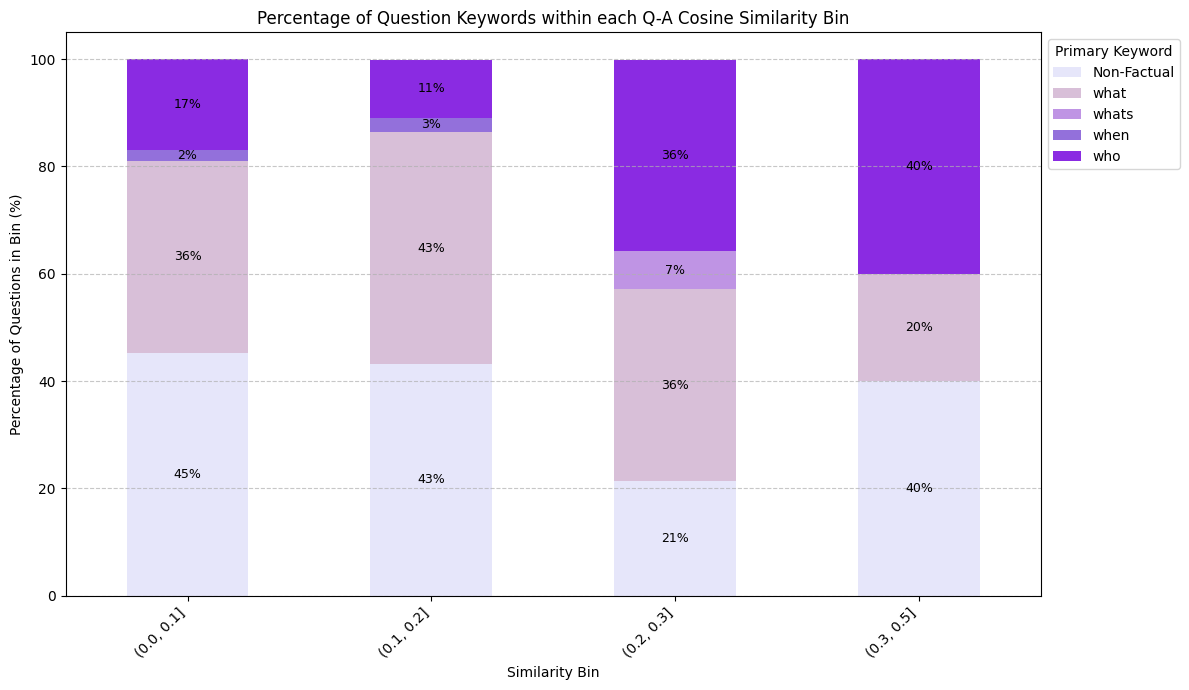

In [80]:
# Use a custom function from eda_scripts to extract the main (first) keyword from the 'factual recall keywords' column
df_nonzero_qa_similarity['main_keyword_for_grouping'] = df_nonzero_qa_similarity['factual_recall_keyword'].apply(eda.get_main_keyword)

# Perform the groupby using this new column:
keyword_distribution_by_bin = df_nonzero_qa_similarity.groupby(
    ['similarity_bin', 'main_keyword_for_grouping'], 
    observed=True
).size().unstack(fill_value=0)

keyword_dist_by_bin_percent = keyword_distribution_by_bin.apply(lambda x: (x / x.sum() * 100), axis=1).round(1) 
# Color Palette (shades of purple)
purple_shades = ['#E6E6FA', '#D8BFD8', '#BF94E4', '#9370DB', '#8A2BE2', '#800080', '#4B0082'] 
num_keywords = len(keyword_dist_by_bin_percent.columns)
colors_to_use = purple_shades[:num_keywords] 

# Create the plot and get the Axes object
ax = keyword_dist_by_bin_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7), # Increased height slightly for labels
    color=colors_to_use, # Apply your custom color palette
    title="Percentage of Question Keywords within each Q-A Cosine Similarity Bin"
)
ax.set_ylabel("Percentage of Questions in Bin (%)")
ax.set_xlabel("Similarity Bin") # Added xlabel for clarity
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7) # Added y-axis grid for readability

# Add percentage labels for the stacks for each bin
for i, sim_bin_label in enumerate(keyword_dist_by_bin_percent.index):
    cumulative_height = 0
    # Iterate over each keyword (each segment in the stack for that bin)
    for keyword_col in keyword_dist_by_bin_percent.columns:
        percentage_value = keyword_dist_by_bin_percent.loc[sim_bin_label, keyword_col]

        # Only add label if the percentage is greater than a small threshold (e.g., 1%)
        # to avoid cluttering with tiny labels. Adjust threshold as needed.
        if percentage_value > 1: # You can adjust this threshold
            # Calculate the y position for the label (center of the segment)
            label_y_position = cumulative_height + (percentage_value / 2)
            ax.text(
                i,                             # x-coordinate (bar index)
                label_y_position,              # y-coordinate (center of segment)
                f"{percentage_value:.0f}%",    # Text label (integer percentage)
                ha='center',                   # Horizontal alignment
                va='center',                   # Vertical alignment
                color='black',                 # Label color (adjust if needed for contrast)
                fontsize=9,                    # Font size for labels
            )
        cumulative_height += percentage_value

ax.legend(title='Primary Keyword', bbox_to_anchor=(1, 1), loc='upper left')

fig = ax.get_figure()
plt.tight_layout()
plt.show()

1. Within the trivia dataset, the majority of the records (91%) have no overlap (similarity score = 0) in important keywords between questions and their answers.
2. Of the remaining 9% of dataset with non-zero q-a similarity scores, majority of the scores are in bin 1 (0,0.1]  and bin 2 (0.1,0.2] with 42 and 43 q-a pairs, respectively. This is 82.5% of all the non-zero q-a similarity scores.
3. In bin 1, with the lowest similarity scores, 52% are non-factual questions. These typically can have more open-ended, wordier answers so there is a little overlap in the vocabulary between the question and answers. 
4. As the similarity score increases, the proportion of non-factual questions drops gradually to the lowest in bin 4 with a score range of (0.3, 0.5]. Non-factual account for 20% of the records in the bin and the remainder are factual-recall types. This is likely due to the factual-type questions being tied to their answers and require repeating certain keywords in the answer. For example, the q-a with the highest similarity score share two keywords in common "safe" and "drink". Although technically a "Yes" alone would have been ok but a complete sentence requires repeating words from the question.

The high prevalence of zero or very low Q-A cosine similarity scores, combined with our earlier findings that both questions and answers are typically short, suggests a desirable characteristic for trivia. This means the answers are generally not just rephrasings of the questions. Instead, questions appear to be concise and answers provide specific information often using distinct terminology not explicitly found in the question itself. The overall quality of phrasing, clarity, and correctness will be assessed during the manual review phase.

### 8.2. Question-Question (Q-Q) comparison

In [81]:
# 1. Create a full similarity matrix
qq_similarity_matrix = cosine_similarity(X_questions, X_questions)
# Print summary descriptive statistics for the similarity matrix:
eda.print_similarity_matrix_stats(qq_similarity_matrix)


--- Statistics for Pairwise Similarity ---
* Original matrix shape: (1085, 1085)
* Number of unique pairwise scores (off-diagonal): 588070
* Percentage of non-zero scores: 53.50%

Descriptive statistics for non-diagonal scores:
 --------------------------------------------------
count    588070.0000
mean          0.0074
std           0.0194
min           0.0000
25%           0.0000
50%           0.0033
65%           0.0053
66%           0.0055
75%           0.0073
90%           0.0189
95%           0.0309
99%           0.0733
max           1.0000
dtype: float64
--------------------------------------------------


#### 8.2.1. Identifying near-duplicate questions with cosine similarity
The question-to-question (Q-Q) cosine similarity, calculated using TF-IDF scores of 1-to-3-word N-grams, showed a sparse relationship matrix. At least 65% of unique question pairs have a similarity score of 0 (with the overall median also being 0), the mean is just 0.005. The standard deviation (0.0178) is larger than the mean indicating that the few non-zero scores have a large spread. Furthermore, 99% of the q-q pairs have a score of 0.062 or less, which is a negligible similarity score. 

The initial idea was to see if any common groupings could be identified in the questions based clustering of the key entities from the TF-IDF vectors. However since the scores are so low it is not worthwile. The additional effort in modelling would negate any gains or insights at this stage. The NER analysis in phase 2 is likely to be a better approach to categorization.

It is interesting to see that the max similarity score is 1.00. This means that there is at least one pair of questions where the wording is identical. These duplicate were somehow missed in the [data preparation section](#4-data-preparation). We need to have a closer look at these rows and then likely drop the redundant ones. 

#### 8.2.2 Approach
A pairwise comparison of the questions with similarity scores close to "1" was used to find the missed (near) duplicates. These questions were missed in the [data preparation](#4-data-preparation) because of small differences between the questions such as capitalization, punctuation, minor wording, typos and other spelling / grammar mistakes (like 'Gamekeeper' vs. 'gamekeeper', or the presence/absence of an article like 'a' or 'the'). When the text is normalized with the tokenizer these differences disappear. 

While this pairwise view highlights many potential duplicates, it doesn't fully capture scenarios where more than two questions are identical. Consider a question 'A' that is identical to question 'B', and B is identical to question 'C', and A and C could be nearly identical but not identified (score=0.998) in the pairwise comparison. However, for the purposes of the game, these near-identical questions are also essentially the same. We've already seen in the data preparation section that there could be 5 copies of a given question. To address this and identify complete sets of duplicate or near-duplicate questions, we will now use a graph-based approach to consolidate these pairwise findings into distinct groups. These groups can then be handled separately and more easily and efficiently than analyzing pairs of questions.

So to summarize, to further investigate the redundancy, the Question-Question (Q-Q) cosine similarity matrix was analyzed using the pairwise comparison and graph analysis sequentially with various similarity score thresholds (1.0, >=0.98, >=0.95, and >=0.90). 

To avoid redundancy,  the results with only a **similarity score of >=0.98** are included here.

In [82]:
threshold_list= [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1]

qq_duplicate_groups_detailed_df, qq_threshold_summary_df = eda.get_duplicates_with_graph(df_for_analysis, 
                                                                                threshold_list, 
                                                                                qq_similarity_matrix)

In [83]:
qq_threshold_summary_df

,threshold,total_pairs_found,new_pairs_at_this_threshold,total_distinct_groups,new_groups_at_this_threshold,total_questions_in_groups,new_questions_in_groups
0,1.00,33,33,25,25,54,54
1,0.95,37,4,29,4,62,8
2,0.90,38,1,30,1,64,2
3,0.85,41,3,33,3,70,6
4,0.80,46,5,36,3,77,7
5,0.75,52,6,42,6,89,12
6,0.70,57,5,47,5,99,10
7,0.60,75,18,61,14,129,30
8,0.50,103,28,77,16,168,39


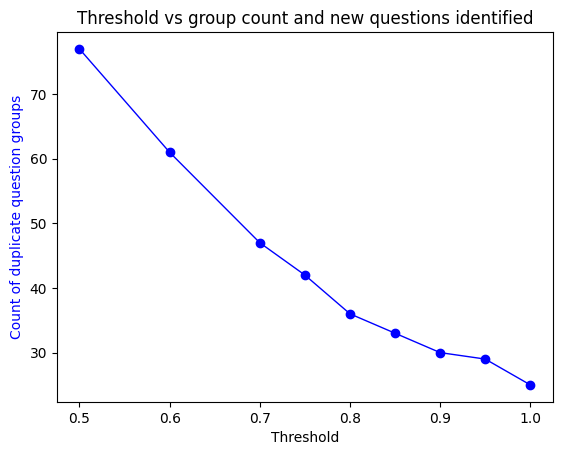

In [84]:
x = qq_threshold_summary_df['threshold']
y = qq_threshold_summary_df['total_distinct_groups']

plt.figure()
plt.plot(x, y, color='blue', linestyle='-', linewidth=1)  
plt.scatter(x, y, color='blue', marker='o', label='Distinct Groups') 
plt.ylabel('Count of duplicate question groups', color='blue')
plt.xlabel('Threshold')
plt.title('Threshold vs group count and new questions identified')
plt.show()

In [85]:
filtered_df = qq_duplicate_groups_detailed_df.loc[qq_duplicate_groups_detailed_df['threshold']==1]
new_groups_df = filtered_df.loc[(filtered_df['newly_grouped_q']== True)|(filtered_df['new_or_expanded_group']== True)]

In [86]:
qq_duplicate_groups_detailed_df.head()

,threshold,group_id,group_size,original_question_id,matrix_position,question_text,answer_text,newly_grouped_q,new_or_expanded_group
0,1.0,Thresh1.00_Group1,2,2,2,What is a Wronski Feint?,Pretending to dive for the Snitch,True,True
1,1.0,Thresh1.00_Group1,2,235,235,What is Wronski Feint?,Pretending to dive for the Snitch.,True,True
19,1.0,Thresh1.00_Group10,3,212,212,How many players are on a quidditch team?,7,True,True
20,1.0,Thresh1.00_Group10,3,446,446,How many players are on a Quidditch team?,7,True,True
21,1.0,Thresh1.00_Group10,3,686,686,How many players are on a Quidditch team?,Seven,True,True


Based on the action plan, we can create a list of the questions that need to be dropped:

In [87]:
# List of questions identified to be tagged as 'is_duplicate' based on the q-q similarity analysis (25 gropugs, 30 questions in total)
# Note: remaining 6 groups are not duplicates but incomplete or incorrect questions - that will be deleted and some replaced with new ones as per action plan.
qlist_tag_duplicate = [405, 885, 263, 752, 894, 432, 697, 1055, 1043, 397, 
                       73, 425, 261,  268, 1075, 1045, 505, 343, 731, 235,
                       113, 667, 123, 499, 1020, 212, 446, 719, 890]

df_for_analysis['is_duplicate'] = df_for_analysis.index.isin(qlist_tag_duplicate)
# Sanity check
print(df_for_analysis['is_duplicate'].value_counts()) # should be 29 True
display(df_for_analysis[df_for_analysis['is_duplicate'] == True].head())

is_duplicate
False    1056
True       29
Name: count, dtype: int64


,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword,is_duplicate
73,73,"Before Dumbledore, who was Headmaster of Hogwarts?",Armando Dippet,"[dumbledore, who, be, headmaster, hogwarts]","[armando, dippet]","[dumbledore, who, be, headmaster, hogwarts, armando, dippet]",[who],True
113,113,What is the Name of America’s Magical Government?,MACUSA,"[what, be, name, americas, magical, government]",[macusa],"[what, be, name, americas, magical, government, macusa]","[what, name]",True
123,123,What is the name of the Wizard village near Hogwarts?,Hogsmeade,"[what, be, name, wizard, village, near, hogwarts]",[hogsmeade],"[what, be, name, wizard, village, near, hogwarts, hogsmeade]","[what, name]",True
212,212,How many players are on a quidditch team?,7,"[how, many, player, be, quidditch, team]",[],"[how, many, player, be, quidditch, team]",N/A,True
235,235,What is Wronski Feint?,Pretending to dive for the Snitch.,"[what, be, wronski, feint]","[pretend, dive, snitch]","[what, be, wronski, feint, pretend, dive, snitch]",[what],True


In [88]:
qq_duplicate_groups_detailed_df['is_duplicate'] = qq_duplicate_groups_detailed_df['original_question_id'].isin(qlist_tag_duplicate)
# sanity check
print(qq_duplicate_groups_detailed_df['is_duplicate'].value_counts())
display(qq_duplicate_groups_detailed_df[qq_duplicate_groups_detailed_df['is_duplicate']==True].head())

is_duplicate
False    572
True     240
Name: count, dtype: int64


,threshold,group_id,group_size,original_question_id,matrix_position,question_text,answer_text,newly_grouped_q,new_or_expanded_group,is_duplicate
1,1.0,Thresh1.00_Group1,2,235,235,What is Wronski Feint?,Pretending to dive for the Snitch.,True,True,True
19,1.0,Thresh1.00_Group10,3,212,212,How many players are on a quidditch team?,7,True,True,True
20,1.0,Thresh1.00_Group10,3,446,446,How many players are on a Quidditch team?,7,True,True,True
22,1.0,Thresh1.00_Group11,2,263,263,Where is the entrance to the Chamber of Secrets?,Moaning Myrtle's bathroom,True,True,True
25,1.0,Thresh1.00_Group12,2,1043,1043,Who is the Flying instructor?,Madam Hooch,True,True,True


In [89]:
threshold_list= [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1]
for threshold in threshold_list:
    count = qq_duplicate_groups_detailed_df.loc[(qq_duplicate_groups_detailed_df['threshold']==threshold) &
                                    (qq_duplicate_groups_detailed_df['is_duplicate']==True)]['group_id'].count()
    print(f"{threshold}: {count}")

0.5: 27
0.6: 27
0.7: 27
0.75: 27
0.8: 27
0.85: 27
0.9: 27
0.95: 27
1: 24


In [90]:
filtered_df = qq_duplicate_groups_detailed_df.loc[
                                    (qq_duplicate_groups_detailed_df['threshold']==0.85)
                                    # (qq_duplicate_groups_detailed_df['threshold']==0.80)|
                                    # (qq_duplicate_groups_detailed_df['threshold']==0.75)|
                                    # (qq_duplicate_groups_detailed_df['threshold']==0.7)|
                                    # (qq_duplicate_groups_detailed_df['threshold']==0.6)
                                    # (qq_duplicate_groups_detailed_df['threshold']==0.5)
                                    ]

new_groups_df = filtered_df.loc[(filtered_df['newly_grouped_q']== True)|(filtered_df['new_or_expanded_group']== True)]
new_groups_df

,threshold,group_id,group_size,original_question_id,matrix_position,question_text,answer_text,newly_grouped_q,new_or_expanded_group,is_duplicate
214,0.85,Thresh0.85_Group17,2,340,340,Do you know what kind of creature a Boggart is? Because I [Merula] do.,Non-being,True,True,False
215,0.85,Thresh0.85_Group17,2,570,570,Do you know what kind of creature a Boggart is?,Non-being,True,True,False
182,0.85,Thresh0.85_Group2,2,16,16,Cedric Diggory let Harry use the prefect's bathroom in The Goblet of Fire. What man's statue is next to the special lavatory entrance?,Boris the Bewildered.,True,True,False
183,0.85,Thresh0.85_Group2,2,650,650,Cedric Diggory let Harry use the prefect's bathroom in The Goblet of Fire. What man's statue is next to the lavatory entrance?,Boris the Bewildered,True,True,False
233,0.85,Thresh0.85_Group26,2,541,541,"Ever the eccentric, Dumbledore has a scar above his left knee that is a perfect map of what?",The London Underground.,True,True,False
234,0.85,Thresh0.85_Group26,2,714,714,Dumbledore has a scar above his left knee that is a perfect map of what?,The London Underground,True,True,False


In [91]:
df_for_analysis.head()

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword,is_duplicate
0,0,What are the three European wizarding schools that participate in the Triwizard Tournament?,"Hogwarts, Beauxbatons, and Durmstrang.","[what, be, three, european, wizarding, school, participate, triwizard, tournament]","[hogwarts, beauxbatons, durmstrang]","[what, be, three, european, wizarding, school, participate, triwizard, tournament, hogwarts, beauxbatons, durmstrang]",[what],False
1,1,When was Hogwarts founded?,10th century,"[when, be, hogwarts, found]","[th, century]","[when, be, hogwarts, found, th, century]",[when],False
2,2,What is a Wronski Feint?,Pretending to dive for the Snitch,"[what, be, wronski, feint]","[pretend, dive, snitch]","[what, be, wronski, feint, pretend, dive, snitch]",[what],False
3,3,You wouldn't know anything about this. Name a method to make your broom go faster.,Using polish,"[wouldnt, know, anything, name, method, make, broom, go, faster]","[use, polish]","[wouldnt, know, anything, name, method, make, broom, go, faster, use, polish]",[name],False
4,4,Harry first took the Knight Bus in The Prisoner of Azkaban. How much does a ticket cost if it includes hot chocolate?,14 sickles.,"[harry, first, take, knight, bus, prisoner, azkaban, how, much, do, ticket, cost, include, hot, chocolate]",[sickle],"[harry, first, take, knight, bus, prisoner, azkaban, how, much, do, ticket, cost, include, hot, chocolate, sickle]",N/A,False


In [92]:
df_for_analysis.iloc[340]

original_question_id                                                                         340
question                  Do you know what kind of creature a Boggart is? Because I [Merula] do.
answer                                                                                 Non-being
question tokens                            [do, know, what, kind, creature, boggart, be, merula]
answer tokens                                                                         [nonbeing]
combined_unique_tokens           [do, know, what, kind, creature, boggart, be, merula, nonbeing]
factual_recall_keyword                                                                    [what]
is_duplicate                                                                               False
Name: 340, dtype: object

In [93]:
# List of new questions to be tagged based on manual review of new groups added or expanded between thresholds of 0.8 and 0.5: 38 new questions
qlist_tag_duplicate_2 = [45, 541, 937, 1016, 102, 1001, 897, 631, 873, 82,
                         1067, 221, 807, 931, 546, 365, 858,596, 701, 280,
                         507, 572, 496, 1011, 600, 785,477, 52, 922, 605, 
                         660, 692, 207, 987, 189, 995, 370, 650]

# all questions to be deleted based on action plant: 24 quesitons.
qq_qids_del = [93, 460, 271, 433, 203, 259, 625, 1080, 219, 658,
               64, 95, 340, 570, 763, 878, 144, 502, 403, 267,
               1047, 998, 1017, 1054]

all_ids_to_flag_as_duplicate = list(set(qlist_tag_duplicate + qlist_tag_duplicate_2))
print(f"Total unique IDs to flag as duplicate: {len(all_ids_to_flag_as_duplicate)}")

df_for_analysis['is_duplicate'] = df_for_analysis.index.isin(all_ids_to_flag_as_duplicate)
# Sanity check
print(df_for_analysis['is_duplicate'].value_counts()) # should be 67 True
display(df_for_analysis[df_for_analysis['is_duplicate'] == True].head()) 

Total unique IDs to flag as duplicate: 67
is_duplicate
False    1018
True       67
Name: count, dtype: int64


,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword,is_duplicate
45,45,Who previously held Snape's post?,Horace Slughorn,"[who, previously, hold, snapes, post]","[horace, slughorn]","[who, previously, hold, snapes, post, horace, slughorn]",[who],True
52,52,What is the core of Draco Malfoy's wand?,Unicorn hair,"[what, be, core, draco, malfoys, wand]","[unicorn, hair]","[what, be, core, draco, malfoys, wand, unicorn, hair]",[what],True
73,73,"Before Dumbledore, who was Headmaster of Hogwarts?",Armando Dippet,"[dumbledore, who, be, headmaster, hogwarts]","[armando, dippet]","[dumbledore, who, be, headmaster, hogwarts, armando, dippet]",[who],True
82,82,Who created the Sorcerer's Stone?,Nicolas Flamel,"[who, create, sorcerer, stone]","[nicolas, flamel]","[who, create, sorcerer, stone, nicolas, flamel]",[who],True
102,102,What Quidditch players fend off the Bludgers?,The Beaters,"[what, quidditch, player, fend, bludgers]",[beater],"[what, quidditch, player, fend, bludgers, beater]",[what],True


In [94]:
# Sanity check before removing questions
print(f"Total number of questions before removing incorrect / incomplete questions: {df_for_analysis.shape[0]}")
print(f"Total number of questions to be removed: {len(qq_qids_del)}")

# Deleting documents tagged in qq_qids_del list
df_for_analysis = df_for_analysis[~df_for_analysis['original_question_id'].isin(qq_qids_del)].reset_index(drop=True)

# Sanity check after removing questions
print(f"Total number of questions after removal: {df_for_analysis.shape[0]}")
print("Confirming if the original_question_ids from deletion list still exist in the dataframe:")

# Check if any original_question_id from deletion list still exists
remaining = set(qq_qids_del).intersection(set(df_for_analysis['original_question_id']))
print(f"Intersecting IDs (should be empty set): {remaining}\n")

# Sanity check
print(df_for_analysis['is_duplicate'].value_counts())  # should be 67 True
display(df_for_analysis[df_for_analysis['is_duplicate'] == True].head())

Total number of questions before removing incorrect / incomplete questions: 1085
Total number of questions to be removed: 24
Total number of questions after removal: 1061
Confirming if the original_question_ids from deletion list still exist in the dataframe:
Intersecting IDs (should be empty set): set()

is_duplicate
False    994
True      67
Name: count, dtype: int64


,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword,is_duplicate
45,45,Who previously held Snape's post?,Horace Slughorn,"[who, previously, hold, snapes, post]","[horace, slughorn]","[who, previously, hold, snapes, post, horace, slughorn]",[who],True
52,52,What is the core of Draco Malfoy's wand?,Unicorn hair,"[what, be, core, draco, malfoys, wand]","[unicorn, hair]","[what, be, core, draco, malfoys, wand, unicorn, hair]",[what],True
72,73,"Before Dumbledore, who was Headmaster of Hogwarts?",Armando Dippet,"[dumbledore, who, be, headmaster, hogwarts]","[armando, dippet]","[dumbledore, who, be, headmaster, hogwarts, armando, dippet]",[who],True
81,82,Who created the Sorcerer's Stone?,Nicolas Flamel,"[who, create, sorcerer, stone]","[nicolas, flamel]","[who, create, sorcerer, stone, nicolas, flamel]",[who],True
99,102,What Quidditch players fend off the Bludgers?,The Beaters,"[what, quidditch, player, fend, bludgers]",[beater],"[what, quidditch, player, fend, bludgers, beater]",[what],True


In [95]:
cleaned_trivia_df = df_for_analysis.copy()
cleaned_trivia_df.reset_index(drop=True, inplace=True)
cleaned_trivia_df = cleaned_trivia_df[cleaned_trivia_df['is_duplicate']==False]
cleaned_trivia_df.shape

(994, 8)

In [96]:
cleaned_trivia_df.head()

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword,is_duplicate
0,0,What are the three European wizarding schools that participate in the Triwizard Tournament?,"Hogwarts, Beauxbatons, and Durmstrang.","[what, be, three, european, wizarding, school, participate, triwizard, tournament]","[hogwarts, beauxbatons, durmstrang]","[what, be, three, european, wizarding, school, participate, triwizard, tournament, hogwarts, beauxbatons, durmstrang]",[what],False
1,1,When was Hogwarts founded?,10th century,"[when, be, hogwarts, found]","[th, century]","[when, be, hogwarts, found, th, century]",[when],False
2,2,What is a Wronski Feint?,Pretending to dive for the Snitch,"[what, be, wronski, feint]","[pretend, dive, snitch]","[what, be, wronski, feint, pretend, dive, snitch]",[what],False
3,3,You wouldn't know anything about this. Name a method to make your broom go faster.,Using polish,"[wouldnt, know, anything, name, method, make, broom, go, faster]","[use, polish]","[wouldnt, know, anything, name, method, make, broom, go, faster, use, polish]",[name],False
4,4,Harry first took the Knight Bus in The Prisoner of Azkaban. How much does a ticket cost if it includes hot chocolate?,14 sickles.,"[harry, first, take, knight, bus, prisoner, azkaban, how, much, do, ticket, cost, include, hot, chocolate]",[sickle],"[harry, first, take, knight, bus, prisoner, azkaban, how, much, do, ticket, cost, include, hot, chocolate, sickle]",N/A,False


In [97]:
# cleaned_trivia_df['question_tokens_str'] = cleaned_trivia_df['question tokens'].apply(lambda token_list: ' '.join(token_list))
# X_questions_clean =  vectorizer.transform(cleaned_trivia_df['question_tokens_str'])

X_questions_clean, Y_answers_clean = eda.transform_for_similarity_check(cleaned_trivia_df, vectorizer)
qq_similarity_matrix_cleaned = cosine_similarity(X_questions_clean, X_questions_clean)
eda.print_similarity_matrix_stats(qq_similarity_matrix_cleaned)


--- Statistics for Pairwise Similarity ---
* Original matrix shape: (994, 994)
* Number of unique pairwise scores (off-diagonal): 493521
* Percentage of non-zero scores: 52.81%

Descriptive statistics for non-diagonal scores:
 --------------------------------------------------
count    493521.0000
mean          0.0071
std           0.0162
min           0.0000
25%           0.0000
50%           0.0031
65%           0.0052
66%           0.0054
75%           0.0072
90%           0.0184
95%           0.0305
99%           0.0705
max           0.7579
dtype: float64
--------------------------------------------------


In [98]:
eda.print_max_simscore_record(qq_similarity_matrix_cleaned, cleaned_trivia_df, "Pairwise similarity for cleaned q-q pairs")


--- Analyzing Maximum Similarity for: Pairwise similarity for cleaned q-q pairs ---
The exact maximum off-diagonal similarity score to search for is: 0.7578698507108

Question pair(s) with the max similarity score:

--- Max Score Pair 1 (Score: 0.7579) ---

  Q.85: What does it mean when a magical creature is classified as XXX by the Ministry of Magic?
  Answer: Competent Wizards Should Cope
  Q.426: What does it mean when a magical creature is classified as X by the Ministry of Magic?
  Answer: Boring

--------------------------------------------------


#### 8.2.3. Results

Questions with a similarity score of 1.0 represented items that became identical after the text normalization (e.g., due to capitalization or minor punctuation differences). For example, some identical questions show minor answer variations like punctuation differences (e.g., one answer ending with a full stop, another not) or semantic equivalencies (e.g., an answer being "Seven" versus "7"). In other cases, truly identical questions are paired with slightly different answer phrasings or levels of detail, all of which require careful review. Expanding the threshold to >=0.98 included these, plus a few additional pairs representing very strong paraphrases or extremely minor textual variations (e.g., "bottled memories" vs. "bottled up memories"). Interestingly, further lowering the threshold to >=0.95 and then to >=0.90 did not identify any new pairs beyond those already captured. 

This suggests that the max score of "1"  will disappear once the duplicates are removed. The 99% score (0.0617) would then be the max. So it can be generalized that the similarities between the questions is negligible. This shows that the dataset is diverse and has non-repeating quesions.
  
With a threshold score of 0.98, the pairwise comparison identified 40 pairs of questions. When these pairs were input to the graph analysis, 32 distinct groups (68 unique questions) were flagged for manual evaluation. The question groups can be categorized into four groups:
1. Identical or near identical questions and answers - minor differences such as capitalization or stop words (groups 1-3, 5-13, 15-20, 26-32),
2. Identical questions with semantically similar answers - the answers are slightly different for example "7" vs. "seven" (groups 4, 14, 23)
3. Identical questions but different answers - questions with different phrasing or even completely different (groups 22, 24, 25)
4. Identical questions by a typo in the answer - both answers are correct but one spelt incorrectly (group 21).

Since there is an overlap between the q-q and a-a analysis, the redundant questions will be handled now rather then flagged and dealt collectively in the [manual review section](#10-data-quality-assurance-and-finalization). This is because it will introduce noise into the a-a similarity comparison. It will be hard to distinguish which answers are repeated but from different questions (different questions can ask about the same character, e.g. Dumbledore or Hermione) or because of the duplicates are still present in the dataset. 

#### 8.2.4. Action plan to handle redundancy

**Guiding principles**:
- concise, correct, and clear questions and answers. Use the best canonical answer
- Appropriate trivia question - make sure they make sense in the gameplay.
- player / game experience - fairness, variety, interesting, reasonable level of difficulty.
- standardization - questions like mcq, true/false, and fill in the blank have a set approach in phrasing. Consistent format, makes the dataset more navigable. Answer standardization e.g. answers like "Seven" are standardized to "7" (as strings).

**Outcome**:
The manual review of the 32 groups identified a total of 42 unique questions for removal. Of these:
- 2 groups (group no. 13, 23 with 2 questions each) were removed without replacement because they were not appropriate trivia questions (joke or too vague).
- 4 groups were removed completely but will be replaced by 4 new questions. This was typically because it was either an incomplete multiple-choice question or the answer was too ambiguous (groups 6, 12, 24, 26). This was also an opportunity to standardize the format of multiple-choice questions.
- for the remaining groups, one question was selected from each group and the remaining were deleted.

The detailed action plan can be found here. 

>pipeline to transform dataset?

### 8.3. Answer-Answer (A-A) comparison

In [99]:
# 1. Create a full similarity matrix. Y_answers_clean created earlier
aa_similarity_matrix_clean = cosine_similarity(Y_answers_clean, Y_answers_clean)
eda.print_similarity_matrix_stats(aa_similarity_matrix_clean)


--- Statistics for Pairwise Similarity ---
* Original matrix shape: (994, 994)
* Number of unique pairwise scores (off-diagonal): 493521
* Percentage of non-zero scores: 0.28%

Descriptive statistics for non-diagonal scores:
 --------------------------------------------------
count    493521.0000
mean          0.0009
std           0.0232
min           0.0000
25%           0.0000
50%           0.0000
65%           0.0000
66%           0.0000
75%           0.0000
90%           0.0000
95%           0.0000
99%           0.0000
max           1.0000
dtype: float64
--------------------------------------------------


In [100]:
threshold_list= [1.00]
aa_duplicate_groups_detailed_df, aa_threshold_summary_df = eda.get_duplicates_with_graph(cleaned_trivia_df, threshold_list, aa_similarity_matrix_clean)
aa_duplicate_groups_detailed_df.shape[0]
aa_duplicate_groups_detailed_df.head()

,threshold,group_id,group_size,original_question_id,matrix_position,question_text,answer_text,newly_grouped_q,new_or_expanded_group
0,1.0,Thresh1.00_Group1,3,1,1,When was Hogwarts founded?,10th century,True,True
1,1.0,Thresh1.00_Group1,3,754,692,When did Godric's fellow founders and Godric found Hogwarts?,10th Century,True,True
2,1.0,Thresh1.00_Group1,3,1068,979,When did Rowena Ravenclaw's fellow Founders and her found Hogwarts?,10th Century,True,True
23,1.0,Thresh1.00_Group10,2,34,34,What eavesdropping tool did Fred and George invent in Harry Potter and the Order of the Phoenix?,Extendable Ears,True,True
24,1.0,Thresh1.00_Group10,2,383,354,What did Fred and George Weasley use to spy on Order of the Phoenix meetings?,Extendable Ears,True,True


In [101]:
# quesitons that have a similarity score of 0.5 or higher:
ids_with_qq_similarityscore_above_0_5 = qq_duplicate_groups_detailed_df['original_question_id'].unique().tolist()
ids_with_qq_similarityscore_above_0_5.sort()
print(len(ids_with_qq_similarityscore_above_0_5))

# sanity check
print(qq_duplicate_groups_detailed_df[qq_duplicate_groups_detailed_df['threshold']==0.5]['group_id'].count())

168
168


In [102]:
# first we need to filter the aa_duplicate_groups_detailed_df to include only the questions that were listed in the qq_duplicate_groups_detailed_df with
# a similarity score of 0.5 or higher.
filter_aa_detailed_df = aa_duplicate_groups_detailed_df[aa_duplicate_groups_detailed_df['original_question_id'].isin(ids_with_qq_similarityscore_above_0_5)]
# Display the num questions identified.
print(f"Number of questions tagged with a similarity score >= 0.5 and and a answer similarity score = 1: {filter_aa_detailed_df.shape[0]}")

# let's get the group_ids of the groups that the tagged questions belong
aa_groups_to_check = filter_aa_detailed_df['group_id'].unique().tolist()
# create a dataframe where the identified groups so we can see the related questions with the same answer
qq_and_aa_overlap_check = aa_duplicate_groups_detailed_df[aa_duplicate_groups_detailed_df['group_id'].isin(aa_groups_to_check)]
# Display the total num of questions in the identified groups
print(f"Total number of questions with the same answer (A-A score = 1) and similar questions (Q-Q score >= 0.5): {qq_and_aa_overlap_check.shape[0]}")

Number of questions tagged with a similarity score >= 0.5 and and a answer similarity score = 1: 30
Total number of questions with the same answer (A-A score = 1) and similar questions (Q-Q score >= 0.5): 59


In [103]:
qq_and_aa_overlap_check


,threshold,group_id,group_size,original_question_id,matrix_position,question_text,answer_text,newly_grouped_q,new_or_expanded_group
30,1.0,Thresh1.00_Group13,2,63,61,What spell duplicates an item?,Geminio,True,True
31,1.0,Thresh1.00_Group13,2,1076,986,Which of these spells is not a charm?,Geminio,True,True
32,1.0,Thresh1.00_Group14,2,68,65,Professor Snape is the head of which Hogwarts house?,Slytherin,True,True
33,1.0,Thresh1.00_Group14,2,743,682,"What is the name of the Hogwarts house known for its ambition, cunning, and resourcefulness?",Slytherin,True,True
53,1.0,Thresh1.00_Group23,2,101,94,A Nimbus is a type of what?,Broom,True,True
54,1.0,Thresh1.00_Group23,2,111,103,A Firebolt is a type of what?,Broom,True,True
55,1.0,Thresh1.00_Group24,2,107,99,What is the name of the wizard village near Hogwarts?,Hogsmeade,True,True
56,1.0,Thresh1.00_Group24,2,357,330,What's the only all-wizard village in Britain?,Hogsmeade,True,True
57,1.0,Thresh1.00_Group25,2,112,104,Who is the Gamekeeper of Hogwarts?,Rubeus Hagrid,True,True
58,1.0,Thresh1.00_Group25,2,977,902,What is the name of the gamekeeper and Care of Magical Creatures professor during Harry's first year at Hogwarts?,Rubeus Hagrid,True,True


Manual review of `qq_and_aa_overlap_check` identified an additional 7 questions that can be tagged as `is_duplicate' and one that is a duplicate and incorrect so needs to be deleted.

In [104]:
overlap_qid_isduplicate = [362, 643, 554, 870, 420, 742, 549]

In [105]:
df_for_analysis[df_for_analysis['original_question_id'].isin(overlap_qid_isduplicate)]

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword,is_duplicate
352,362,Where was Harry born?,Godric's Hollow,"[where, be, harry, born]","[godrics, hollow]","[where, be, harry, born, godrics, hollow]",[where],False
409,420,What did Fred and George Weasley call their joke shop?,Weasleys’ Wizard Wheezes,"[what, do, fred, george, weasley, call, joke, shop]","[weasleys, wizard, wheeze]","[what, do, fred, george, weasley, call, joke, shop, weasleys, wizard, wheeze]",[what],False
535,549,What is Lockhart's favorite color?,Lilac,"[what, be, lockharts, favorite, color]",[lilac],"[what, be, lockharts, favorite, color, lilac]",[what],False
540,554,Who is the giant three-headed dog that guards the trapdoor leading to the Philosopher's Stone in the first book?,Fluffy,"[who, be, giant, threeheaded, dog, guard, trapdoor, lead, philosopher, stone, first, book]",[fluffy],"[who, be, giant, threeheaded, dog, guard, trapdoor, lead, philosopher, stone, first, book, fluffy]",[who],False
627,643,What does solitary 'X' classification mean?,Boring,"[what, do, solitary, classification, mean]",[boring],"[what, do, solitary, classification, mean, boring]",[what],False
725,742,What subject foes Headmistress McGonagall teach?,Transfiguration,"[what, subject, foes, headmistress, mcgonagall, teach]",[transfiguration],"[what, subject, foes, headmistress, mcgonagall, teach, transfiguration]",[what],False
852,870,Who is the Headmaster of Hogwarts when Harry arrives?,Albus Dumbledore.,"[who, be, headmaster, hogwarts, when, harry, arrive]","[albus, dumbledore]","[who, be, headmaster, hogwarts, when, harry, arrive, albus, dumbledore]","[who, when]",False


In [106]:
df_for_analysis.loc[df_for_analysis['original_question_id'].isin(overlap_qid_isduplicate), 'is_duplicate'] = True
# Sanity check
print(df_for_analysis['is_duplicate'].value_counts()) # should be 67 + 7 = 74 True

is_duplicate
False    987
True      74
Name: count, dtype: int64


In [107]:
# Update the cleaned_trivia_df to reflect the changes
cleaned_trivia_df = df_for_analysis.copy()
cleaned_trivia_df.reset_index(drop=True, inplace=True)
cleaned_trivia_df = cleaned_trivia_df[cleaned_trivia_df['is_duplicate']==False]
cleaned_trivia_df.shape

(987, 8)

In [108]:
# 1. Create a full similarity matrix
# cleaned_trivia_df['answer_tokens_str'] = cleaned_trivia_df['answer tokens'].apply(lambda token_list: ' '.join(token_list))
# Y_answers_clean2 =  vectorizer.transform(cleaned_trivia_df['answer_tokens_str'])

# Create the full similarity matrix again:
X_questions_clean2, Y_answers_clean2 = eda.transform_for_similarity_check(cleaned_trivia_df, vectorizer= vectorizer)
aa_similarity_matrix_clean = cosine_similarity(Y_answers_clean2, Y_answers_clean2)
eda.print_similarity_matrix_stats(aa_similarity_matrix_clean)


--- Statistics for Pairwise Similarity ---
* Original matrix shape: (987, 987)
* Number of unique pairwise scores (off-diagonal): 486591
* Percentage of non-zero scores: 0.28%

Descriptive statistics for non-diagonal scores:
 --------------------------------------------------
count    486591.0000
mean          0.0008
std           0.0229
min           0.0000
25%           0.0000
50%           0.0000
65%           0.0000
66%           0.0000
75%           0.0000
90%           0.0000
95%           0.0000
99%           0.0000
max           1.0000
dtype: float64
--------------------------------------------------


In [109]:
threshold_list= [1.00]
aa_duplicate_groups_detailed_df, aa_threshold_summary_df = eda.get_duplicates_with_graph(cleaned_trivia_df, threshold_list, aa_similarity_matrix_clean)
print(f" There are {aa_duplicate_groups_detailed_df.shape[0]} questions tagged using the A-A similarity score of 1.00.\n")
aa_duplicate_groups_detailed_df.head()

 There are 231 questions tagged using the A-A similarity score of 1.00.



,threshold,group_id,group_size,original_question_id,matrix_position,question_text,answer_text,newly_grouped_q,new_or_expanded_group
0,1.0,Thresh1.00_Group1,3,1,1,When was Hogwarts founded?,10th century,True,True
1,1.0,Thresh1.00_Group1,3,754,686,When did Godric's fellow founders and Godric found Hogwarts?,10th Century,True,True
2,1.0,Thresh1.00_Group1,3,1068,972,When did Rowena Ravenclaw's fellow Founders and her found Hogwarts?,10th Century,True,True
23,1.0,Thresh1.00_Group10,2,34,34,What eavesdropping tool did Fred and George invent in Harry Potter and the Order of the Phoenix?,Extendable Ears,True,True
24,1.0,Thresh1.00_Group10,2,383,353,What did Fred and George Weasley use to spy on Order of the Phoenix meetings?,Extendable Ears,True,True


In [110]:
# aa_duplicate_groups_detailed_df.sort_values(by=['group_id', 'original_question_id'])

In [111]:
aa_isduplicate_qids2 = [754, 1068, 383, 1004, 39, 137, 7, 190, 952, 306, 
                        899, 8, 823, 896, 205, 209, 517, 376, 689, 599,
                        530, 264, 769, 1022, 750, 386, 473, 772, 850, 917,
                        738, 589, 454, 949, 617, 827, 1060, 739, 708,
                        740, 939]

aa_qid_del = [1076, 977, 663, 154, 369, 448, 787, 215, 413, 257,
              297, 21, 358, 784, 409, 1077, 424, 526, 694, 584,
              979, 771, 854, 645, 906
              ]

print(f"Review of A-A similarity score of 1.00 identified {len(aa_isduplicate_qids2)} questions to be tagged as duplicates.\n"
      f"Review of A-A similarity score of 1.00 identified {len(aa_qid_del)} questions to be deleted.\n")

Review of A-A similarity score of 1.00 identified 41 questions to be tagged as duplicates.
Review of A-A similarity score of 1.00 identified 25 questions to be deleted.



In [112]:
# # iteration 2: 
df_for_analysis.loc[df_for_analysis['original_question_id'].isin(aa_isduplicate_qids2), 'is_duplicate'] = True
# # Sanity check
print(df_for_analysis['is_duplicate'].value_counts()) # should be 74 + 41 = 115 True

is_duplicate
False    946
True     115
Name: count, dtype: int64


In [113]:
print(set(aa_isduplicate_qids2).intersection(set(overlap_qid_isduplicate)))

set()


Now deleting the incomplete / incorrect questions identfied in list `aa_qid_del` during the analysis

In [114]:
# Sanity check before removing questions
print(f"Total number of questions before removing incorrect / incomplete questions: {df_for_analysis.shape[0]}")
print(f"Total number of questions to be removed: {len(aa_qid_del)}")

# Deleting documents tagged in qq_qids_del list
df_for_analysis = df_for_analysis[~df_for_analysis['original_question_id'].isin(aa_qid_del)].reset_index(drop=True)

# Sanity check after removing questions
print(f"Total number of questions after removal: {df_for_analysis.shape[0]}")
print("Confirming if the original_question_ids from deletion list still exist in the dataframe:")

# Check if any original_question_id from deletion list still exists
remaining = set(aa_qid_del).intersection(set(df_for_analysis['original_question_id']))
print(f"Intersecting IDs (should be empty set): {remaining}\n")

# Sanity check
print(df_for_analysis['is_duplicate'].value_counts())  # should be 117 True
display(df_for_analysis[df_for_analysis['is_duplicate'] == True].head())

Total number of questions before removing incorrect / incomplete questions: 1061
Total number of questions to be removed: 25
Total number of questions after removal: 1036
Confirming if the original_question_ids from deletion list still exist in the dataframe:
Intersecting IDs (should be empty set): set()

is_duplicate
False    921
True     115
Name: count, dtype: int64


,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword,is_duplicate
7,7,What magical creature runs guards wand wood trees?,Bowtruckles,"[what, magical, creature, run, guard, wand, wood, tree]",[bowtruckles],"[what, magical, creature, run, guard, wand, wood, tree, bowtruckles]",[what],True
8,8,Name all seven Weasley children.,"Bill, Charlie, Percy, Fred, George, Ron, and Ginny.","[name, seven, weasley, child]","[bill, charlie, percy, fred, george, ron, ginny]","[name, seven, weasley, child, bill, charlie, percy, fred, george, ron, ginny]",[name],True
38,39,What does 'Colloportus' do?,Lock and seal doors,"[what, do, colloportus]","[lock, seal, door]","[what, do, colloportus, lock, seal, door]",[what],True
44,45,Who previously held Snape's post?,Horace Slughorn,"[who, previously, hold, snapes, post]","[horace, slughorn]","[who, previously, hold, snapes, post, horace, slughorn]",[who],True
51,52,What is the core of Draco Malfoy's wand?,Unicorn hair,"[what, be, core, draco, malfoys, wand]","[unicorn, hair]","[what, be, core, draco, malfoys, wand, unicorn, hair]",[what],True


In [115]:
cleaned_trivia_df = df_for_analysis.copy()
cleaned_trivia_df.reset_index(drop=True, inplace=True)
cleaned_trivia_df = cleaned_trivia_df[cleaned_trivia_df['is_duplicate']==False]
cleaned_trivia_df.shape

(921, 8)

In [116]:
# # 1. Create a full similarity matrix
# cleaned_trivia_df['answer_tokens_str'] = cleaned_trivia_df['answer tokens'].apply(lambda token_list: ' '.join(token_list))
# Y_answers_clean3 =  vectorizer.transform(cleaned_trivia_df['answer_tokens_str'])
X_questions_clean3, Y_answers_clean3 = eda.transform_for_similarity_check(cleaned_trivia_df, vectorizer= vectorizer)
aa_similarity_matrix_clean = cosine_similarity(Y_answers_clean3, Y_answers_clean3)
eda.print_similarity_matrix_stats(aa_similarity_matrix_clean)


--- Statistics for Pairwise Similarity ---
* Original matrix shape: (921, 921)
* Number of unique pairwise scores (off-diagonal): 423660
* Percentage of non-zero scores: 0.28%

Descriptive statistics for non-diagonal scores:
 --------------------------------------------------
count    423660.0000
mean          0.0007
std           0.0188
min           0.0000
25%           0.0000
50%           0.0000
65%           0.0000
66%           0.0000
75%           0.0000
90%           0.0000
95%           0.0000
99%           0.0000
max           1.0000
dtype: float64
--------------------------------------------------


In [117]:
eda.print_max_simscore_record(aa_similarity_matrix_clean, cleaned_trivia_df, "A-A pairwise comparison")


--- Analyzing Maximum Similarity for: A-A pairwise comparison ---
The exact maximum off-diagonal similarity score to search for is: 1.0000000000000004

Question pair(s) with the max similarity score:

--- Max Score Pair 1 (Score: 1.0000) ---

  Q.10: Vipera Evanesca is used to vaporize what kind of creature?
  Answer: Snake
  Q.230: What does 'Serpensortia' conjure?
  Answer: Snakes


--- Max Score Pair 2 (Score: 1.0000) ---

  Q.10: Vipera Evanesca is used to vaporize what kind of creature?
  Answer: Snake
  Q.872: Harry uses Parseltongue to speak to which creatures?
  Answer: Snake


--- Max Score Pair 3 (Score: 1.0000) ---

  Q.18: Who destroyed the Horcrux in Helga Hufflepuff's Cup?
  Answer: Hermione Granger
  Q.141: Who was the Rook in the Chessboard Chamber?
  Answer: Hermione Granger

--------------------------------------------------


The new questions to replace incomplete or incorrect questions are saved in a csv file. The questions will be merged with the main dataframe once the trivia columns have been standardized based on the in-depth findings from the EDA. 

In [118]:
# upload the new questions csv file as a dataframe - TO BE MERGED WITH DF in section 9
new_questions_df = pd.read_csv('02_EDA_Section8_NewQuestions.csv')
new_questions_df

,question,answer,question_type
0,"Which of the following is NOT a form of Transfiguration: Switching, Vanishing, Enchantment, Conjuration.",Enchantment,MC
1,How do you tell if a door is Imperturbable?,Test if it repels objects and sounds,EX
2,"Which of the following plants is known for its tendency to slap people: Fanged Geranium, Bubotuber, Bouncing Bulbs, Snargaluff?",Bouncing Bulbs,MC
3,"Which of the following is NOT a type of broom? Nimbus, Cleansweep Seven, Occamy, Firebolt.",Occamy,MC
4,"According to the Ministry of Magic's classification system, what type of entity is a Boggart?",Non-being,FR
5,Where is the best place to buy flesh-eating slug repellent?,Knockturn Alley,FR
6,"In Harry Potter and the Half-Blood Prince, which amusingly titled book did Ron Weasley worry his mother might have sent him for Slughorn's N.E.W.T. Potions class by mistake? Madcap Magic for Wacky Warlocks, Charm Your Own Cheese, Where There's a Wand, There's a Way, Basic Hexes for the Busy and Vexed.",Charm Your Own Cheese,MC
7,How many times did Wendelin the Weird allow herself to be caught by witch-hunters?,47,FR
8,"Which of these words best describes Slytherin House: Daring, Patient, Resourceful, or Witty?",Resourceful,MC
9,"Which of these spells is NOT primarily classified as a standard utility Charm? Accio, Lumos, Geminio, Alohomora.",Geminio,MC


In [119]:
# convert columns from 'object` to `str`
new_questions_df = new_questions_df.astype({'question': 'string', 'answer': 'string', 'question_type': 'string'})
new_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   question       13 non-null     string
 1   answer         13 non-null     string
 2   question_type  13 non-null     string
dtypes: string(3)
memory usage: 440.0 bytes


In [120]:
# correct question type - MC to MCQ:
print(f"'MC' count before replacement = {new_questions_df[new_questions_df['question_type']=='MC']['question_type'].count()}")
print(f"'MCQ' count before replacement = {new_questions_df[new_questions_df['question_type']=='MCQ']['question_type'].count()}\n")
new_questions_df['question_type'] = new_questions_df['question_type'].replace('MC', 'MCQ')
print(f"'MC' count after replacement = {new_questions_df[new_questions_df['question_type']=='MC']['question_type'].count()}")
print(f"'MCQ' count after replacement = {new_questions_df[new_questions_df['question_type']=='MCQ']['question_type'].count()}")

'MC' count before replacement = 9
'MCQ' count before replacement = 0

'MC' count after replacement = 0
'MCQ' count after replacement = 9


In [121]:
search_terms = ['yes', 'no', 'true', 'false', 'fill']
df = pd.DataFrame()

for search_term in search_terms:
    filter_condition = lambda x: isinstance(x, list) and search_term in x
    result_df = df_for_analysis.loc[df_for_analysis['combined_unique_tokens'].apply(filter_condition)]
    df = pd.concat([df, result_df], ignore_index=True)
df

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword,is_duplicate
0,651,Is it safe to drink water conjured by Aguamenti?,"Yes, it's safe to drink.","[be, safe, drink, water, conjure, aguamenti]","[yes, safe, drink]","[be, safe, drink, water, conjure, aguamenti, yes]",N/A,False
1,676,Can the Extinguishing Charm be used to put out dragon fire?,"Yes, it can.","[can, extinguish, charm, use, put, dragon, fire]","[yes, can]","[can, extinguish, charm, use, put, dragon, fire, yes]",N/A,False
2,797,Can Ascendio be used underwater?,"Yes, it can","[can, ascendio, use, underwater]","[yes, can]","[can, ascendio, use, underwater, yes]",N/A,False
3,1079,"Will you serve the great nation of Peevesland, soldier?","Sir, yes, sir!","[will, serve, great, nation, peevesland, soldier]","[sir, yes]","[will, serve, great, nation, peevesland, soldier, sir, yes]",N/A,False
4,165,What is true about tortoises?,Some live over 200 years.,"[what, be, true, tortoise]","[live, year]","[what, be, true, tortoise, live, year]",[what],False
5,355,True or false: Harry Potter and the Deathly Hallows: Part Two is the shortest Harry Potter movie.,True! The run time is just 130 minutes.,"[true, false, harry, potter, deathly, hallows, part, two, be, short, movie]","[true, run, time, be, minute]","[true, false, harry, potter, deathly, hallows, part, two, be, short, movie, run, time, minute]",N/A,False
6,535,True or false: This is the longest movie in the franchise.,"False! Harry Potter and the Chamber of Secrets is the longest movie, at 161 minutes.","[true, false, be, long, movie, franchise]","[false, harry, potter, chamber, secret, be, long, movie, minute]","[true, false, be, long, movie, franchise, harry, potter, chamber, secret, minute]",N/A,False
7,593,Which statement is true about conjured objects?,They vanish in time,"[which, statement, be, true, conjured, object]","[vanish, time]","[which, statement, be, true, conjured, object, vanish, time]",N/A,False
8,717,Who wrote The Owl Airforce: True Life Tales of War in Europe?,Simon Dentata,"[who, write, owl, airforce, true, life, tale, war, europe]","[simon, dentata]","[who, write, owl, airforce, true, life, tale, war, europe, simon, dentata]",[who],False
9,974,What is true about gerbils?,They like to burrow,"[what, be, true, gerbil]","[like, burrow]","[what, be, true, gerbil, like, burrow]",[what],False


In [122]:
questions_to_remove = [1079, 165, 535, 593, 717, 974, 489]
# New MCQ question to replace original_qid 593
new_mcq = {
    'question' : 'Which statement is true about conjured objects: They are permanent if the caster is powerful enough, Food is the easiest thing to conjure perfectly, They vanish in time, or They are always invisible to Muggles?',
    'answer' : 'They vanish in time',
    'question_type' : 'MCQ',
}

# drop the questions that are in the `questions_to_remove` list
print(f"Number of questions before removing the ones in the `questions_to_remove` list: {df_for_analysis.shape[0]}")
df_for_analysis = df_for_analysis[~df_for_analysis['original_question_id'].isin(questions_to_remove)].reset_index(drop=True)
print(f"Number of questions after removing the ones in the `questions_to_remove` list: {df_for_analysis.shape[0]}")

# Add the new MCQ question to the new_questions_df
new_row = pd.DataFrame([new_mcq])
new_questions_df = pd.concat([new_questions_df, new_row], ignore_index=True) 
print(f"Number of new questions to add: {new_questions_df.shape[0]}")

Number of questions before removing the ones in the `questions_to_remove` list: 1036
Number of questions after removing the ones in the `questions_to_remove` list: 1029
Number of new questions to add: 14


In [123]:
new_questions_df.tail(1)

,question,answer,question_type
13,"Which statement is true about conjured objects: They are permanent if the caster is powerful enough, Food is the easiest thing to conjure perfectly, They vanish in time, or They are always invisible to Muggles?",They vanish in time,MCQ


In [124]:
search_terms = ['yes', 'no', 'true', 'false']
df = pd.DataFrame()

for search_term in search_terms:
    filter_condition = lambda x: isinstance(x, list) and search_term in x
    result_df = df_for_analysis.loc[df_for_analysis['combined_unique_tokens'].apply(filter_condition)]
    df = pd.concat([df, result_df], ignore_index=True)
df

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword,is_duplicate
0,651,Is it safe to drink water conjured by Aguamenti?,"Yes, it's safe to drink.","[be, safe, drink, water, conjure, aguamenti]","[yes, safe, drink]","[be, safe, drink, water, conjure, aguamenti, yes]",N/A,False
1,676,Can the Extinguishing Charm be used to put out dragon fire?,"Yes, it can.","[can, extinguish, charm, use, put, dragon, fire]","[yes, can]","[can, extinguish, charm, use, put, dragon, fire, yes]",N/A,False
2,797,Can Ascendio be used underwater?,"Yes, it can","[can, ascendio, use, underwater]","[yes, can]","[can, ascendio, use, underwater, yes]",N/A,False
3,355,True or false: Harry Potter and the Deathly Hallows: Part Two is the shortest Harry Potter movie.,True! The run time is just 130 minutes.,"[true, false, harry, potter, deathly, hallows, part, two, be, short, movie]","[true, run, time, be, minute]","[true, false, harry, potter, deathly, hallows, part, two, be, short, movie, run, time, minute]",N/A,False
4,355,True or false: Harry Potter and the Deathly Hallows: Part Two is the shortest Harry Potter movie.,True! The run time is just 130 minutes.,"[true, false, harry, potter, deathly, hallows, part, two, be, short, movie]","[true, run, time, be, minute]","[true, false, harry, potter, deathly, hallows, part, two, be, short, movie, run, time, minute]",N/A,False


In [125]:
df_for_analysis.shape[0]

1029

In [126]:
df_for_analysis[df_for_analysis['is_duplicate']==False]['original_question_id'].count()


np.int64(914)

In [127]:
# percentage of datasets that were found to be duplicates / incorrect / incomplete
100- (914 * 100 / 1279) 
# 914 * 100 / 1085

28.53792025019547

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

# 9. Feature Engineering from In-depth EDA Findings

Dataset standardization based on findings from in-depth EDA

## 9.1. Classify questions into types





In [128]:
## Updated keyword lists for searching different types of questions.

# Factual recall: expanded list of words to look for when identifying 'factual recall' questions 
expanded_factual_recall_list = ['what', 'name', 'who', 'where', 'wheres', 'when', 'whats', 'whose','which','how', 'whom']

# Open-ended: new list
explanatory_list = ['why']

# Yes/No: new list
yesno_list = ['yes', 'no', 'true', 'false', 'fill']

In [129]:
#1. Apply the expanded_factual_recall_list to update the factual_recall_keyword column
df_for_analysis = eda.tag_questions_by_keyword_list(df_for_analysis,'question tokens', expanded_factual_recall_list, 'factual_recall_keyword')

#2. if factual_recall_keyword is not 'N/A', then question type is FR
df_for_analysis['question_type'] = df_for_analysis['factual_recall_keyword'].apply(lambda x: 'FR' if x != 'N/A' else 'N/A')

#3. if question_type is 'N/A', then check if the question contains any of the explanatory_list keywords, if so, then question type is 'explanatory'
filter_na_type = (df_for_analysis['question_type'] == 'N/A')
explanatory_tags = df_for_analysis.loc[filter_na_type, 'question tokens'].apply(
    lambda tokens: 'EX' if isinstance(tokens, list) and any(keyword in tokens for keyword in explanatory_list) else 'N/A')
# Update question_type ONLY for these 'N/A' rows
df_for_analysis.loc[filter_na_type, 'question_type'] = explanatory_tags

#4. if factual_recall_keyword is 'N/A', then check if the question contains any of the yesno_list keywords, if so, then question type is 'yesno'
remaining_na_type = (df_for_analysis['question_type'] == 'N/A')
# For these rows, check if they match the yes/no list
yesno_tags = df_for_analysis.loc[remaining_na_type, 'answer tokens'].apply(
    lambda tokens: 'YN' if isinstance(tokens, list) and any(keyword in tokens for keyword in yesno_list) else 'N/A')
# Update question_type ONLY for these 'N/A' rows
df_for_analysis.loc[remaining_na_type, 'question_type'] = yesno_tags

#5. Tag the remaining 'N/A' question types as 'Other'
df_for_analysis.loc[df_for_analysis['question_type'] == 'N/A', 'question_type'] = 'Other'

#6. Check the value counts of the question_type column
df_for_analysis['question_type'].value_counts()

question_type
FR       1006
EX         11
Other       8
YN          4
Name: count, dtype: int64

### Examine the "Other" question types

In [130]:
df_for_analysis[df_for_analysis['question_type'] == 'Other']

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword,is_duplicate,question_type
99,103,Did Muggles use ancient runes as well?,They did.,"[do, muggles, use, ancient, rune, well]",[do],"[do, muggles, use, ancient, rune, well]",N/A,False,Other
536,565,Wich of these creatures is notable proud and easy to offend if not treated politely?,Hippogriff,"[wich, creature, be, notable, proud, easy, offend, treat, politely]",[hippogriff],"[wich, creature, be, notable, proud, easy, offend, treat, politely, hippogriff]",N/A,False,Other
560,591,The Bouncy Bulb is extremely difficult to...,Pot.,"[bouncy, bulb, be, extremely, difficult]",[pot],"[bouncy, bulb, be, extremely, difficult, pot]",N/A,False,Other
689,727,"You may have heard that Luna Lovegood wears shoes to bed, but does anyone know the reason?",She sleepwalks,"[may, have, hear, luna, lovegood, wear, shoe, bed, do, anyone, know, reason]",[sleepwalks],"[may, have, hear, luna, lovegood, wear, shoe, bed, do, anyone, know, reason, sleepwalks]",N/A,False,Other
761,803,"Dittany, mixed with this ingredient, can cure a Werewolf bite.",Powdered Silver,"[dittany, mixed, ingredient, can, cure, werewolf, bite]","[powder, silver]","[dittany, mixed, ingredient, can, cure, werewolf, bite, powder, silver]",N/A,False,Other
763,805,Did the werewolf code of conduct work?,No,"[do, werewolf, code, conduct, work]",[],"[do, werewolf, code, conduct, work]",N/A,False,Other
862,907,Is it safe to eat mistletoe berries?,"No, they're poisonous.","[be, safe, eat, mistletoe, berry]","[theyre, poisonous]","[be, safe, eat, mistletoe, berry, theyre, poisonous]",N/A,False,Other
888,933,Do ancient runes have magical properties themselves?,"No, they don't.","[do, ancient, rune, have, magical, property]",[dont],"[do, ancient, rune, have, magical, property, dont]",N/A,False,Other


In [131]:
# 1. delete the documents that incomplete, incorrect, or need to be replaced / rephrased. 
others_to_delete = [103, 565, 591,727, 803, 907]
print(f"Number of questions before removing the ones in the `others_to_delete` list: {df_for_analysis.shape[0]}")
df_for_analysis = df_for_analysis[~df_for_analysis['original_question_id'].isin(others_to_delete)].reset_index(drop=True)
print(f"Number of questions after removing the ones in the `others_to_delete` list: {df_for_analysis.shape[0]}\n")

# 2. reclassify types as YN:
reclassify_yn = [805, 933]
for index in reclassify_yn:
    df_for_analysis.loc[df_for_analysis['original_question_id'] == index, 'question_type'] = 'YN'
    print(f"Q{index} question_type reclassified as: {df_for_analysis.loc[df_for_analysis['original_question_id'] == index, 'question_type'].values[0]}")

# 2. Add replacement questions to new_questions_df:
new_questions = [
    {
        'question': 'Which of these creatures is notably proud and easy to offend if not treated politely: Niffler, Grindylow, Hippogriff, Bowtruckle?',
        'answer': 'Hippogriff',
        'question_type': 'MCQ'
    },
    {
        'question': 'Bouncing Bulbs are notoriously difficult for which of these Herbology actions: Watering, Pruning, Potting, or Fertilizing?',
        'answer': 'Potting',
        'question_type': 'MCQ'
    },
    {
        'question': 'Why does Luna Lovegood wear shoes to bed?',
        'answer': 'She sleepwalks',
        'question_type': 'EX'
    },
    {
        'question': 'What ingredient do you need to mix with Dittany to cure Werewolf bites?',
        'answer': 'Powdered Silver',
        'question_type': 'FR'
    },
    {
        'question': 'Did Muggles use ancient runes as well??',
        'answer': 'Yes, they did',
        'question_type': 'YN'
    }
]
print(f"The number of questions in new_questions_df before addition: {new_questions_df.shape[0]}")
new_questions_df = pd.concat([new_questions_df, pd.DataFrame(new_questions)], ignore_index=True)
print(f"\nNumber of new questions in new_questions_df: {new_questions_df.shape[0]}\n")
print("The tail ten rows of the new_questions_df are displayed below:\n")
display(new_questions_df.tail(10))

Number of questions before removing the ones in the `others_to_delete` list: 1029
Number of questions after removing the ones in the `others_to_delete` list: 1023

Q805 question_type reclassified as: YN
Q933 question_type reclassified as: YN
The number of questions in new_questions_df before addition: 14

Number of new questions in new_questions_df: 19

The tail ten rows of the new_questions_df are displayed below:



,question,answer,question_type
9,"Which of these spells is NOT primarily classified as a standard utility Charm? Accio, Lumos, Geminio, Alohomora.",Geminio,MCQ
10,"Which of the following spells is not used in Transfiguration Class: Vera Verto, Evanesco, Confundo, or Avis?",Confundo,MCQ
11,"Which of these potions does NOT contain Valerian Sprigs as a listed ingredient? Draught of Living Death, Elixir to Induce Euphoria, Sleeping Draught, Polyjuice Potion.",Polyjuice Potion,MCQ
12,"Which of these spells is most similar to Flipendo, the Knockback Jinx? Depulso, Accio, Incendio, Stupefy.",Depulso,MCQ
13,"Which statement is true about conjured objects: They are permanent if the caster is powerful enough, Food is the easiest thing to conjure perfectly, They vanish in time, or They are always invisible to Muggles?",They vanish in time,MCQ
14,"Which of these creatures is notably proud and easy to offend if not treated politely: Niffler, Grindylow, Hippogriff, Bowtruckle?",Hippogriff,MCQ
15,"Bouncing Bulbs are notoriously difficult for which of these Herbology actions: Watering, Pruning, Potting, or Fertilizing?",Potting,MCQ
16,Why does Luna Lovegood wear shoes to bed?,She sleepwalks,EX
17,What ingredient do you need to mix with Dittany to cure Werewolf bites?,Powdered Silver,FR
18,Did Muggles use ancient runes as well??,"Yes, they did",YN


In [132]:
# Check the value counts of the question_type column after the updates
print("Updated question_type value counts after changes:\n")
print(f"Total number of questions in the df_for_analysis: {df_for_analysis.shape[0]}")
df_for_analysis['question_type'].value_counts()


Updated question_type value counts after changes:

Total number of questions in the df_for_analysis: 1023


question_type
FR    1006
EX      11
YN       6
Name: count, dtype: int64

three categories - although from EDA we know there is multiple choice questions (MCQ) present as well but are not in the categorized ones above. The incomplete ones found in the EDA were deleted and will be replaced with new questions from new_questions_df. There are likely other MCQ that have been missed. 

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 9.2. Standardize numeric answers

In [133]:
numbers_as_words = ['one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'ten']
# filter answers that have numbers as words
numbers_as_words_filter = df_for_analysis['answer tokens'].apply(
    lambda x: isinstance(x, list) and any(word in x for word in numbers_as_words)
)
num_ans_df = df_for_analysis.loc[numbers_as_words_filter]
num_ans_df


,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword,is_duplicate,question_type
12,12,How old was Luna when she lost her mom?,Nine,"[how, old, be, luna, when, lose, mom]",[nine],"[how, old, be, luna, when, lose, mom, nine]","[when, how]",False,FR
55,56,How did I become a metamorphagus?,You were born one.,"[how, do, become, metamorphagus]","[be, bear, one]","[how, do, become, metamorphagus, be, bear, one]",[how],False,FR
87,89,How many Horcruxes did Voldemort create intentionally?,Six,"[how, many, horcruxes, do, voldemort, create, intentionally]",[six],"[how, many, horcruxes, do, voldemort, create, intentionally, six]",[how],False,FR
221,232,How many Philosopher's Stones have been known to exist?,One,"[how, many, philosopher, stone, have, know, exist]",[one],"[how, many, philosopher, stone, have, know, exist, one]",[how],False,FR
272,287,How many points is a goal worth?,Ten,"[how, many, point, be, goal, worth]",[ten],"[how, many, point, be, goal, worth, ten]",[how],False,FR
300,316,How many presents did Dudley Dursley receive on his birthday in total?,"38. It was 36 (one less than last year), but then Mrs. Dursley bought him two new presents to make up for it.","[how, many, present, do, dudley, dursley, receive, birthday, total]","[be, one, less, last, year, mrs, dursley, buy, two, new, present, make]","[how, many, present, do, dudley, dursley, receive, birthday, total, be, one, less, last, year, mrs, buy, two, new, make]",[how],False,FR
319,335,How many Lionfish Spines are used in one batch of Herbicide Potion?,Four,"[how, many, lionfish, spine, be, use, one, batch, herbicide, potion]",[four],"[how, many, lionfish, spine, be, use, one, batch, herbicide, potion, four]",[how],False,FR
363,382,How long did the longest Quidditch game last?,Six months,"[how, long, do, quidditch, game, last]","[six, month]","[how, long, do, quidditch, game, last, six, month]",[how],False,FR
439,465,How many siblings does Ron Weasley have?,Six,"[how, many, sibling, do, ron, weasley, have]",[six],"[how, many, sibling, do, ron, weasley, have, six]",[how],False,FR
463,490,What is the first line of the book?,"“Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you very much.”","[what, be, first, line, book]","[mr, dursley, number, four, privet, drive, be, proud, say, perfectly, normal, thank, much]","[what, be, first, line, book, mr, dursley, number, four, privet, drive, proud, say, perfectly, normal, thank, much]",[what],False,FR


- some questions are imprecise / not phrased clearly -> tagged to be reviewed in manual review.

In [134]:
num_ans_list = num_ans_df['original_question_id'].to_list()
ignore_list = [597, 693, 758, 882, 926, 969, 1018] # through manual review of num_ans_df -> not truely numeric answers
num_ans_list = [qid for qid in num_ans_list if qid not in ignore_list]
print(f"Total number of questions filtered with numbers-as-words as answers: {num_ans_df.shape[0]} documents.")
print("After review or num_ans_df:")
print(f"* Original question id numbers with numbers-as-words as answers: {len(num_ans_list)} documents\n",  num_ans_list)
print(f"* Exceptions (original qid list): {len(ignore_list)} documents\n", ignore_list)

Total number of questions filtered with numbers-as-words as answers: 25 documents.
After review or num_ans_df:
* Original question id numbers with numbers-as-words as answers: 18 documents
 [12, 56, 89, 232, 287, 316, 335, 382, 465, 490, 521, 555, 621, 686, 954, 962, 992, 996]
* Exceptions (original qid list): 7 documents
 [597, 693, 758, 882, 926, 969, 1018]


In [135]:
# questions to replace with new questions are original qids: [56, 316, 490, 992]

new_questions_1 = [
    {
        'question': 'How does one typically become a Metamorphmagus? Casting a transformation spell, Using a magical potion, Born with the ability, or Learning from a skilled Metamorphmagus?',
        'answer': 'Born with the ability',
        'question_type': 'MCQ'
    },
    {
        'question': 'On his 11th birthday, how many presents did Dudley Dursley receive on in total?',
        'answer': '38',
        'question_type': 'FR'
    },
    {
        'question': "In Harry Potter and the Philosopher's Stone, what is the first line of the book?",
        'answer': 'Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you very much.',
        'question_type': 'FR'
    },
    {
        'question': 'How many Horcruxes have been destroyed at the end of Harry Potter and the Half-Blood Prince?',
        'answer': "2 (Tom Riddle's diary and Marvolo Gaunt's ring)",
        'question_type': 'FR'
    }
]
print(f"The number of questions in new_questions_df before addition: {new_questions_df.shape[0]}")
new_questions_df = pd.concat([new_questions_df, pd.DataFrame(new_questions_1)], ignore_index=True)
print(f"\nNumber of questions now in new_questions_df: {new_questions_df.shape[0]}\n")
print("The tail ten rows of the new_questions_df are displayed below:\n")
display(new_questions_df.tail(10))

The number of questions in new_questions_df before addition: 19

Number of questions now in new_questions_df: 23

The tail ten rows of the new_questions_df are displayed below:



,question,answer,question_type
13,"Which statement is true about conjured objects: They are permanent if the caster is powerful enough, Food is the easiest thing to conjure perfectly, They vanish in time, or They are always invisible to Muggles?",They vanish in time,MCQ
14,"Which of these creatures is notably proud and easy to offend if not treated politely: Niffler, Grindylow, Hippogriff, Bowtruckle?",Hippogriff,MCQ
15,"Bouncing Bulbs are notoriously difficult for which of these Herbology actions: Watering, Pruning, Potting, or Fertilizing?",Potting,MCQ
16,Why does Luna Lovegood wear shoes to bed?,She sleepwalks,EX
17,What ingredient do you need to mix with Dittany to cure Werewolf bites?,Powdered Silver,FR
18,Did Muggles use ancient runes as well??,"Yes, they did",YN
19,"How does one typically become a Metamorphmagus? Casting a transformation spell, Using a magical potion, Born with the ability, or Learning from a skilled Metamorphmagus?",Born with the ability,MCQ
20,"On his 11th birthday, how many presents did Dudley Dursley receive on in total?",38,FR
21,"In Harry Potter and the Philosopher's Stone, what is the first line of the book?","Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you very much.",FR
22,How many Horcruxes have been destroyed at the end of Harry Potter and the Half-Blood Prince?,2 (Tom Riddle's diary and Marvolo Gaunt's ring),FR


In [136]:
boolean_mask = df_for_analysis['answer tokens'].apply(eda.find_answer_with_number_word_gt_10)
df_to_review = df_for_analysis[boolean_mask]
df_to_review

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword,is_duplicate,question_type
96,100,How many Rogue Planets exist in the Milky Way?,Billions.,"[how, many, rogue, planet, exist, milky, way]",[billion],"[how, many, rogue, planet, exist, milky, way, billion]",[how],False,FR
186,194,How old was Harry when he got his first letter from Hogwarts?,Eleven,"[how, old, be, harry, when, get, first, letter, hogwarts]",[eleven],"[how, old, be, harry, when, get, first, letter, hogwarts, eleven]","[when, how]",False,FR
372,391,How many teams are in the British and Irish Quidditch League?,Thirteen,"[how, many, team, be, british, irish, quidditch, league]",[thirteen],"[how, many, team, be, british, irish, quidditch, league, thirteen]",[how],False,FR
374,393,What did the Dursleys give Harry for Christmas in his first year at Hogwarts?,Fifty Pence,"[what, do, dursleys, give, harry, christmas, first, year, hogwarts]","[fifty, penny]","[what, do, dursleys, give, harry, christmas, first, year, hogwarts, fifty, penny]",[what],False,FR


In [137]:
new_num_ans = [194, 391, 393]
num_ans_list.extend(new_num_ans)
# Q.100 (original qid 100) is not a HP trivia question, but a general question about the series, so it will be deleted. 
# Append `original_question_id`=100 to the list from others to delete and handle together.
others_to_delete.append(100)

In [138]:
# Sanity check
print(num_ans_list)
print(others_to_delete)

[12, 56, 89, 232, 287, 316, 335, 382, 465, 490, 521, 555, 621, 686, 954, 962, 992, 996, 194, 391, 393]
[103, 565, 591, 727, 803, 907, 100]


convert identified numeric-answer questions to standardized "number-as-str" format.

In [139]:
# since we know that the specific numbers-as-words are present in the dataset - the easiest way to standardize is to map to numbers.
NUMBER_WORD_TO_DIGIT_MAP = {
    "One": "1", "Two": "2", "Three": "3", "Four": "4", "Five": "5",
    "Six": "6", "Seven": "7", "Eight": "8", "Nine": "9", "Ten": "10",
    "Eleven": "11", "Thirteen": "13", "Fifty": "50"}

# create a temporary df to standardize the numeric answers outside of the main df_for_analysis
df_standardized_numeric_ans_subset = df_for_analysis.loc[df_for_analysis['original_question_id'].isin(num_ans_list),['question', 'answer']].copy()

for word_to_replace, digit_replacement in NUMBER_WORD_TO_DIGIT_MAP.items():
        # Create a case-insensitive regex pattern that matches the whole word
        # \b ensures word boundaries, so "one" in "someone" isn't replaced.
        # re.escape handles any special characters if they were in word_to_replace (not an issue here).
        # (?i) makes the pattern case-insensitive.
        pattern = r'(?i)\b' + re.escape(word_to_replace) + r'\b'
        
        df_standardized_numeric_ans_subset['answer'] = \
            df_standardized_numeric_ans_subset['answer'].str.replace(
                pattern,
                digit_replacement,
                regex=True
            )

df_standardized_numeric_ans_subset['question_type']= 'FR' # since these are factual recall questions
df_standardized_numeric_ans_subset['is_numeric_answer'] = True # flag to indicate that these are numeric answers
df_standardized_numeric_ans_subset.head()

,question,answer,question_type,is_numeric_answer
12,How old was Luna when she lost her mom?,9,FR,True
55,How did I become a metamorphagus?,You were born 1.,FR,True
87,How many Horcruxes did Voldemort create intentionally?,6,FR,True
186,How old was Harry when he got his first letter from Hogwarts?,11,FR,True
221,How many Philosopher's Stones have been known to exist?,1,FR,True


In [140]:
new_questions_df['is_numeric_answer'] = False # flag to indicate that these are not numeric answers
print(f"The number of questions in new_questions_df before addition: {new_questions_df.shape[0]}")
new_questions_df = pd.concat([new_questions_df, pd.DataFrame(df_standardized_numeric_ans_subset)], ignore_index=True)
print(f"\nNumber of new questions after addition to new_questions_df: {df_standardized_numeric_ans_subset.shape[0]}\n")
print("The tail ten rows of the new_questions_df are displayed below:\n")
display(new_questions_df.tail(10))

The number of questions in new_questions_df before addition: 23

Number of new questions after addition to new_questions_df: 21

The tail ten rows of the new_questions_df are displayed below:



,question,answer,question_type,is_numeric_answer
34,How many siblings does Ron Weasley have?,6,FR,True
35,What is the first line of the book?,"“Mr. and Mrs. Dursley, of number 4, Privet Drive, were proud to say that they were perfectly normal, thank you very much.”",FR,True
36,How many Muggles see the flying Ford Anglia as Harry and Ron make their way to school?,7,FR,True
37,How many Principal Exceptions are there to Gamp's Law of Elemental Transfiguration?,5,FR,True
38,How many Deathly Hallows did Albus Dumbledore possess?,3,FR,True
39,How many players are on a Quidditch team?,7,FR,True
40,Switching spells simultaneously transfigure how many objects?,2,FR,True
41,How long should a Polyjuice Potion stew before usage?,1 Month,FR,True
42,How many Horcruxes have been destroyed at the end of this story?,2: the diary and the ring,FR,True
43,How many times did Gilderoy Lockhart win Witch Weekly's Most Charming Smile Award?,5,FR,True


In [141]:
# Drop the questions in the num_ans_list from the main df_for_analysis now
print(f"The number list before addition to others_to_delete: {len(others_to_delete)}")
others_to_delete.extend(num_ans_list)
print(f"The number list after addition to others_to_delete: {len(others_to_delete)}")

The number list before addition to others_to_delete: 7
The number list after addition to others_to_delete: 28


In [142]:
df_for_analysis['is_numeric_answer'] = False # ensure the column is present in the main df_for_analysis
df_for_analysis.sample(5)

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword,is_duplicate,question_type,is_numeric_answer
345,363,The Medieval Assembly of European Wizards is related to which convention?,International Warlock Convention,"[medieval, assembly, european, wizard, be, relate, which, convention]","[international, warlock, convention]","[medieval, assembly, european, wizard, be, relate, which, convention, international, warlock]",[which],False,FR,False
215,226,Which books details the history of Quidditch?,Quidditch Through the Ages,"[which, book, detail, history, quidditch]","[quidditch, age]","[which, book, detail, history, quidditch, age]",[which],False,FR,False
306,322,Which incantation cancels all spell effects?,Finite Incantatem,"[which, incantation, cancel, spell, effect]","[finite, incantatem]","[which, incantation, cancel, spell, effect, finite, incantatem]",[which],False,FR,False
288,304,Which of Voldemort’s Horcruxes do Harry and Dumbledore track down—but it turns out to be a fake?,Slytherin’s locket,"[which, voldemorts, horcruxes, do, harry, dumbledore, track, downbut, turn, fake]","[slytherins, locket]","[which, voldemorts, horcruxes, do, harry, dumbledore, track, downbut, turn, fake, slytherins, locket]",[which],False,FR,False
877,928,Who is the autor of 'Beginners Guide to Transfigurations'?,Emeric Switch,"[who, be, autor, beginner, guide, transfiguration]","[emeric, switch]","[who, be, autor, beginner, guide, transfiguration, emeric, switch]",[who],False,FR,False


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 9.3. Reclassify open-ended "how" questions 

In [143]:
tokens = ['many', 'old', 'long', 'much']

filter_mask = df_for_analysis['question tokens'].apply(
    lambda x: isinstance(x, list) and 'how' in x and all(token not in x for token in tokens)
)
df_for_analysis.loc[filter_mask]

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword,is_duplicate,question_type,is_numeric_answer
11,11,"When Riding Facing Backwards, how does steering work?",Turn to the opposite direction.,"[when, rid, face, backwards, how, do, steer, work]","[turn, opposite, direction]","[when, rid, face, backwards, how, do, steer, work, turn, opposite, direction]","[when, how]",False,FR,False
39,40,How is Quodpot different from Quidditch?,The ball explodes,"[how, be, quodpot, different, quidditch]","[ball, explodes]","[how, be, quodpot, different, quidditch, ball, explodes]",[how],False,FR,False
46,47,How often does a Streeler's shell change colour?,Every Hour,"[how, often, do, streelers, shell, change, colour]","[every, hour]","[how, often, do, streelers, shell, change, colour, every, hour]",[how],False,FR,False
55,56,How did I become a metamorphagus?,You were born one.,"[how, do, become, metamorphagus]","[be, bear, one]","[how, do, become, metamorphagus, be, bear, one]",[how],False,FR,False
161,169,How is the Grey Lady related to Rowena Ravenclaw?,She's Rowena's daughter.,"[how, be, grey, lady, related, rowena, ravenclaw]","[shes, rowenas, daughter]","[how, be, grey, lady, related, rowena, ravenclaw, shes, rowenas, daughter]",[how],False,FR,False
163,171,How do you greet a Hippogriff?,With a bow,"[how, do, greet, hippogriff]",[bow],"[how, do, greet, hippogriff, bow]",[how],False,FR,False
181,189,How is Quodpot different from Quiddtich?,The ball explodes.,"[how, be, quodpot, different, quiddtich]","[ball, explodes]","[how, be, quodpot, different, quiddtich, ball, explodes]",[how],True,FR,False
185,193,"In Harry Potter and the Prisoner of Azkaban, how do Hermione, Harry, and Ron find Crookshanks?",He jumps on Ron's head at the Magical Menagerie.,"[harry, potter, prisoner, azkaban, how, do, hermione, ron, find, crookshanks]","[jump, ron, head, magical, menagerie]","[harry, potter, prisoner, azkaban, how, do, hermione, ron, find, crookshanks, jump, head, magical, menagerie]",[how],False,FR,False
267,282,How did Fred and George get the money to open their shop?,They won a bet on the Quidditch World Cup,"[how, do, fred, george, get, money, open, shop]","[bet, quidditch, world, cup]","[how, do, fred, george, get, money, open, shop, bet, quidditch, world, cup]",[how],False,FR,False
268,283,Who did Harry overhear in the Three Broomsticks talking about how Sirius Black betrayed his parents?,"Professor Flitwick, Professor McGonagall, Hagrid, Cornelius Fudge and Madam Rosmerta","[who, do, harry, overhear, three, broomstick, talk, how, sirius, black, betrayed, parent]","[professor, flitwick, mcgonagall, hagrid, cornelius, fudge, madam, rosmerta]","[who, do, harry, overhear, three, broomstick, talk, how, sirius, black, betrayed, parent, professor, flitwick, mcgonagall, hagrid, cornelius, fudge, madam, rosmerta]","[who, how]",False,FR,False


In [144]:
# 1. Identify and reclassify any "how" questions that should be Explanatory (EX) types instead of Factual Recall (FR).
change_to_EX_type = [40, 169, 171, 193, 282, 453, 475, 522, 601, 629, 706, 718, 817, 819, 882, 981, 1042]

filter_condition = df_for_analysis['original_question_id'].isin(change_to_EX_type)
df_for_analysis.loc[filter_condition, 'question_type'] = 'EX'

# 2. Delete questions that are incorrect or need to be replaced / rephrased.
q_delete = [627, 189, 11, 817]
print(f"The number list before addition to others_to_delete: {len(others_to_delete)}")
others_to_delete.extend(q_delete)
print(f"The number list after addition to others_to_delete: {len(others_to_delete)}")

new_EX_questions =[
    {
        'question': 'How does Parvati defeat the bogart during the defence against darks arts class with Professor Lupin in Harry Potter and the Prisoner of Azkaban?',
        'answer': 'In the book, the mummy trips on its wrappings. In the movie, it turns into a giant jack-in-the-box (arguably no less scary).',
        'question_type': 'EX',
        'is_numeric_answer': False
    },
    {
        'question': 'How was Hermione able to take extra lessons in Harry Potter and the Prisoner of Azkaban?',
        'answer': 'She used a time-turner',
        'question_type': 'EX',
        'is_numeric_answer': False
    }
]
print(f"The number of questions in new_questions_df before addition: {new_questions_df.shape[0]}")
new_questions_df = pd.concat([new_questions_df, pd.DataFrame(new_EX_questions)], ignore_index=True)
print(f"\nNumber of new questions now in new_questions_df: {new_questions_df.shape[0]}\n")
print("The tail ten rows of the new_questions_df are displayed below:\n")
display(new_questions_df.tail(10))

The number list before addition to others_to_delete: 28
The number list after addition to others_to_delete: 32
The number of questions in new_questions_df before addition: 44

Number of new questions now in new_questions_df: 46

The tail ten rows of the new_questions_df are displayed below:



,question,answer,question_type,is_numeric_answer
36,How many Muggles see the flying Ford Anglia as Harry and Ron make their way to school?,7,FR,True
37,How many Principal Exceptions are there to Gamp's Law of Elemental Transfiguration?,5,FR,True
38,How many Deathly Hallows did Albus Dumbledore possess?,3,FR,True
39,How many players are on a Quidditch team?,7,FR,True
40,Switching spells simultaneously transfigure how many objects?,2,FR,True
41,How long should a Polyjuice Potion stew before usage?,1 Month,FR,True
42,How many Horcruxes have been destroyed at the end of this story?,2: the diary and the ring,FR,True
43,How many times did Gilderoy Lockhart win Witch Weekly's Most Charming Smile Award?,5,FR,True
44,How does Parvati defeat the bogart during the defence against darks arts class with Professor Lupin in Harry Potter and the Prisoner of Azkaban?,"In the book, the mummy trips on its wrappings. In the movie, it turns into a giant jack-in-the-box (arguably no less scary).",EX,False
45,How was Hermione able to take extra lessons in Harry Potter and the Prisoner of Azkaban?,She used a time-turner,EX,False


In [145]:
new_questions_df.loc[new_questions_df['is_numeric_answer'].isna(), 'is_numeric_answer'] = False # Flag the missing values in the `is_numeric_answer` column as False.
new_questions_df.loc[new_questions_df['answer'] == '47', 'is_numeric_answer'] = True # Flag the answer '47' as a numeric answer.
new_questions_df.loc[new_questions_df['answer'] == '38', 'is_numeric_answer'] = True # Flag the answer '38' as a numeric answer.
new_questions_df.loc[new_questions_df['answer'] == "2 (Tom Riddle's diary and Marvolo Gaunt's ring)", 'is_numeric_answer'] = True # Flag the answer as a numeric answer.
new_questions_df[new_questions_df['is_numeric_answer'] == True].head()

,question,answer,question_type,is_numeric_answer
7,How many times did Wendelin the Weird allow herself to be caught by witch-hunters?,47,FR,True
20,"On his 11th birthday, how many presents did Dudley Dursley receive on in total?",38,FR,True
22,How many Horcruxes have been destroyed at the end of Harry Potter and the Half-Blood Prince?,2 (Tom Riddle's diary and Marvolo Gaunt's ring),FR,True
23,How old was Luna when she lost her mom?,9,FR,True
24,How did I become a metamorphagus?,You were born 1.,FR,True


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 9.4 Identify other incomplete MCQs

In [146]:
# 1. Make a list of typical starting phrases for MCQs.
mcq_indicator_phrases = {
    "which of the following",
    "which of these",
    "which one of the following",
    "which one of these",
    "select the correct",
    "choose the best answer",
    "choose the one that",
    "identify the option that",
    "all of the following are", 
    "which statement is true",
    "which statement is false",
    "who is not",
    "who of the following"
}
# 2. create a general regex pattern to match in the question column
regex_pattern = '|'.join([re.escape(phrase) for phrase in mcq_indicator_phrases])

# 3. Setup a filter condition for the DataFrame to find questions that match the regex pattern
boolean_mask = df_for_analysis['question'].str.contains(
    regex_pattern,
    case=False,  # case-insensitive
    regex=True,  # Ensures the pattern is treated as a regular expression
    na=False     # Treats NaN values as False 
)

# 4. Apply the boolean mask to filter the DataFrame
mcq_questions_df = df_for_analysis[boolean_mask].copy()
print(f"Number of questions identified as MCQ based on regex pattern: {mcq_questions_df.shape[0]}")
mcq_questions_df.sample(10, random_state=42)


Number of questions identified as MCQ based on regex pattern: 52


,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword,is_duplicate,question_type,is_numeric_answer
433,458,Which of these spells is a severing charm?,Diffindo,"[which, spell, be, sever, charm]",[diffindo],"[which, spell, be, sever, charm, diffindo]",[which],False,FR,False
830,879,Which of these being does not live on the Hogwarts grounds?,Goblins,"[which, do, live, hogwarts, ground]",[goblin],"[which, do, live, hogwarts, ground, goblin]",[which],False,FR,False
955,1010,Which of these spells does not make something smaller?,Reducto,"[which, spell, do, make, something, small]",[reducto],"[which, spell, do, make, something, small, reducto]",[which],False,FR,False
264,279,Screechsnaps are capable of doing which of the following?,Move & Make Noise,"[screechsnaps, be, capable, which, follow]","[move, make, noise]","[screechsnaps, be, capable, which, follow, move, make, noise]",[which],False,FR,False
881,932,Which of these plants has healing properties?,Dittany,"[which, plant, have, heal, property]",[dittany],"[which, plant, have, heal, property, dittany]",[which],False,FR,False
157,164,Which of these plants bloom instantly?,Puffapod,"[which, plant, bloom, instantly]",[puffapod],"[which, plant, bloom, instantly, puffapod]",[which],False,FR,False
390,411,In which of these scenarios would you use the impediment jinx?,To slow a rushing opponent.,"[which, scenario, would, use, impediment, jinx]","[slow, rushing, opponent]","[which, scenario, would, use, impediment, jinx, slow, rushing, opponent]",[which],False,FR,False
984,1040,Regerminating Potions work wonders on which of the following?,Dead plants.,"[regerminating, potion, work, wonder, which, follow]","[dead, plant]","[regerminating, potion, work, wonder, which, follow, dead, plant]",[which],False,FR,False
100,105,Which of the following was a reason why the 14th century witch burnings were pointless?,Flame-Freezing Charm,"[which, follow, be, reason, why, th, century, witch, burning, pointless]","[flamefreezing, charm]","[which, follow, be, reason, why, th, century, witch, burning, pointless, flamefreezing, charm]",[which],False,FR,False
638,677,In which of these scenarios would you use Cistem Aperio?,Blasting Open a Locked Trunk,"[which, scenario, would, use, cistem, aperio]","[blast, open, lock, trunk]","[which, scenario, would, use, cistem, aperio, blast, open, lock, trunk]",[which],False,FR,False


In [147]:
# This only had to be run once to save the csv file for manual inspection
# mcq_questions_df.to_csv("incomplete_mcq.csv")

In [148]:
# Reclassify as MCQ (already full MCQ but mistyped as "FR")
exceptions = [749, 795]
df_for_analysis.loc[df_for_analysis['original_question_id'].isin(exceptions), 'question_type'] = 'MCQ'

# Questions to replace
mcq_to_replace = mcq_questions_df['original_question_id'].to_list()
mcq_to_replace = [qid for qid in mcq_to_replace if qid not in exceptions]  # remove exceptions
print(f"Total number of MCQ questions to replace: {len(mcq_to_replace)}")  # should be 50

# Export mcq_questions_df to a CSV file to modify the questions manually
mcq_questions_df['question_type'] = 'MCQ'
mcq_questions_df[['question', 'answer','question_type','is_numeric_answer']].to_csv('02_EDA_Sec9_MCQtoUpdate.csv', index=False)

Total number of MCQ questions to replace: 50


In [149]:
# Extend the delete list with the MCQ questiosn to be replaced
print(f"The number list before addition to others_to_delete: {len(others_to_delete)}")  # is 28
others_to_delete.extend(mcq_to_replace)
print(f"The number list after addition to others_to_delete: {len(others_to_delete)}")  

The number list before addition to others_to_delete: 32
The number list after addition to others_to_delete: 82


The incomplete multiple choice queestions csv file was manually reviewed. 
- It contained 50 entries.
- 2 of this questions were complete MCQs and were removed from the csv (the `exceptions` above with `original_question_id`: 749, 795)
- 3 questions were questions not related to Harry Potter or too confusing are were deleted (`original_question_id` = [87, 217, 1012])
- All the incomplete questions had text (not numeric answers).
- 6 completely new multiple choice questions / answers were included that had numeric answers (`is_numeric = True`) to add variety to the questions.

The updated csv of the replacement mcqs will be uploaded and concatenated with `new_questions_df`

In [150]:
# Upload the complete mcq csv:
new_completed_mcq_df = pd.read_csv("Completed_MCQ.csv")
new_completed_mcq_df.sample(5)

,question,answer,question_type,is_numeric_answer,force_add_as_duplicate
25,"Which of the following books was NOT written by Rita Skeeter: The Life and Lies of Albus Dumbledore, Armando Dippet: Master or Moron?, Easy Spells to Fool Muggles, or Snape: Scoundrel or Saint?",Easy Spells to fool Muggles,MCQ,False,False
43,"Which of these spells does NOT make something smaller: Reducto, Engorgio, Reducio, or Shrinking Charm?",Engorgio,MCQ,False,False
9,"Which of the following is another dive commonly used by Seekers: Porskoff Ploy, Bludger Backbeat, Spiral Dive, or Kestrel Plunge?",Spiral Dive,MCQ,False,False
11,"Which of these titles or identities has NOT been held by Harry Potter: Seeker for Gryffindor, SPEW Treasurer, Prefect, or Triwizard Champion?",SPEW Treasurer,MCQ,False,False
51,"What was the number of the high-security Gringotts vault where the Philosopher's Stone was kept: 687, 711, 713, or 717?",713,MCQ,True,False


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 9.5 Remove incomplete or incorrect questions 

In [151]:
# Sanity check before removing questions
print(f"Number of questions before removing the ones in the `others_to_delete` list: {df_for_analysis.shape[0]}")

# remove the questions that match the 'original_question_id' in the `others_to_delete` list
df_for_analysis = df_for_analysis[~df_for_analysis['original_question_id'].isin(others_to_delete)].reset_index(drop=True)

# Sanity check after removing questions
print(f"Number of questions after removing the ones in the `others_to_delete` list: {df_for_analysis.shape[0]}\n")  # should be 72 (78 - 6 'Others' already deleted from list in section 9.1) 

Number of questions before removing the ones in the `others_to_delete` list: 1023
Number of questions after removing the ones in the `others_to_delete` list: 947



In [152]:
non_duplicate_ques_count = df_for_analysis.loc[df_for_analysis['is_duplicate'] == False,'question'].count()
total_size_reduction_from_original = ((raw_df.shape[0] - non_duplicate_ques_count)/ raw_df.shape[0])*100

# Print summary of the cleaning and EDA process
print(f"* There are {non_duplicate_ques_count} questions that are not duplicates or incorrect / incomplete.")
print(f"* Total size reduction from the original raw dataset with cleaning and EDA: {total_size_reduction_from_original:.2f}%")
display(df_for_analysis.loc[df_for_analysis['is_duplicate'] == False, 'question_type'].value_counts())


* There are 835 questions that are not duplicates or incorrect / incomplete.
* Total size reduction from the original raw dataset with cleaning and EDA: 34.71%


question_type
FR     803
EX      24
YN       6
MCQ      2
Name: count, dtype: int64

In [153]:
df_for_analysis.loc[(df_for_analysis['question_type'] != 'YN') & (df_for_analysis['factual_recall_keyword']== 'N/A')]

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,factual_recall_keyword,is_duplicate,question_type,is_numeric_answer
8,9,Why did student initially think Harry was the Heir of Slytherin?,He can speak Parseltongue,"[why, do, student, initially, think, harry, be, heir, slytherin]","[can, speak, parseltongue]","[why, do, student, initially, think, harry, be, heir, slytherin, can, speak, parseltongue]",N/A,False,EX,False
91,104,Why did Liechtenstein not attend the first meeting of the International Confederation of Wizards?,Their Stance on Troll Rights,"[why, do, liechtenstein, attend, first, meeting, international, confederation, wizard]","[stance, troll, right]","[why, do, liechtenstein, attend, first, meeting, international, confederation, wizard, stance, troll, right]",N/A,False,EX,False
103,117,Why would you need to switch brooms midair?,Broom failure,"[why, would, need, switch, broom, midair]","[broom, failure]","[why, would, need, switch, broom, midair, failure]",N/A,False,EX,False
320,365,Why did students think Harry was the Heir of Slytherin?,He can speak Parseltongue.,"[why, do, student, think, harry, be, heir, slytherin]","[can, speak, parseltongue]","[why, do, student, think, harry, be, heir, slytherin, can, speak, parseltongue]",N/A,True,EX,False
441,508,Why would you cast Alohomora?,Unlock a door.,"[why, would, cast, alohomora]","[unlock, door]","[why, would, cast, alohomora, unlock, door]",N/A,False,EX,False
495,572,Why did the Werewolf Code of Conduct fail?,No Werewolves Signed,"[why, do, werewolf, code, conduct, fail]","[werewolf, sign]","[why, do, werewolf, code, conduct, fail, sign]",N/A,True,EX,False
582,673,Why does Neville Longbottom faint in Herbology class?,"His earmuffs were loose, so he heard the cry of the baby mandrake.","[why, do, neville, longbottom, faint, herbology, class]","[earmuff, be, loose, heard, cry, baby, mandrake]","[why, do, neville, longbottom, faint, herbology, class, earmuff, be, loose, heard, cry, baby, mandrake]",N/A,False,EX,False
732,837,Why do Ron Weasley and Hermione Granger stop speaking?,"Ron blames Hermione’s cat, Crookshanks, for the disappearance of his pet rat, Scabbers.","[why, do, ron, weasley, hermione, granger, stop, speaking]","[ron, blame, hermiones, cat, crookshanks, disappearance, pet, rat, scabbers]","[why, do, ron, weasley, hermione, granger, stop, speaking, blame, hermiones, cat, crookshanks, disappearance, pet, rat, scabbers]",N/A,False,EX,False
767,876,Why shouldn't you drop Puffapod beans?,They'll bloom,"[why, shouldnt, drop, puffapod, bean]","[theyll, bloom]","[why, shouldnt, drop, puffapod, bean, theyll, bloom]",N/A,False,EX,False
843,960,Why did Hermione miss the lesson on Cheering Charms?,Draco's cruel behavior led her to miss the class.,"[why, do, hermione, miss, lesson, cheer, charm]","[draco, cruel, behavior, lead, miss, class]","[why, do, hermione, miss, lesson, cheer, charm, draco, cruel, behavior, lead, class]",N/A,False,EX,False


### Replace `factual_recall_keyword` column with more general `interrogative_keyword` column

In df_for_analysis - rename 'factual_recall_keyword' to 'Interrogative_keyword'. it has keywords for MCQ (which, why etc) and EX (how, why, etc) as well.

In [154]:
# Rename 'factual_recall_keyword` to 'Interrogative_keyword' to better reflect its purpose and clarity.
df_for_analysis.rename(columns={'factual_recall_keyword': 'interrogative_keyword'}, inplace=True)
df_for_analysis.columns

Index(['original_question_id', 'question', 'answer', 'question tokens',
       'answer tokens', 'combined_unique_tokens', 'interrogative_keyword',
       'is_duplicate', 'question_type', 'is_numeric_answer'],
      dtype='object')

In [155]:
# interrogative_keywords master list:
print(f"Master list of interrogative keywords is located in eda_scripts:\n {eda.INTERROGATIVE_KEYWORDS_LIST}")

Master list of interrogative keywords is located in eda_scripts:
 ['what', 'name', 'who', 'where', 'wheres', 'when', 'whats', 'whose', 'which', 'how', 'whom', 'why', 'is', 'are', 'was', 'were', 'do', 'does', 'did', 'can', 'could', 'will', 'would', 'should', 'has', 'have']


In [156]:
# Apply the interrogative keywords list to df_for_analysis
df_for_analysis = eda.tag_questions_by_keyword_list(
                            df = df_for_analysis, 
                            keyword_column = 'question tokens', 
                            trigger_keyword_list = eda.INTERROGATIVE_KEYWORDS_LIST,
                            new_column_name='interrogative_keyword')

In [157]:
print(df_for_analysis.loc[(df_for_analysis['question_type'] != 'YN') & (df_for_analysis['interrogative_keyword']== 'N/A')])

Empty DataFrame
Columns: [original_question_id, question, answer, question tokens, answer tokens, combined_unique_tokens, interrogative_keyword, is_duplicate, question_type, is_numeric_answer]
Index: []


## Trivia Dataset Status Map

---

### 1. Key Metrics

**- Total Unique Questions in Final Dataset:** 947<br>**- Net Change in Questions:** -332<br>   *(Note: A positive number indicates new questions were added; a negative number indicates questions were removed.)*<br>**- Total Questions with Numeric Answers:** 0 (0.0%)<br>


### 2. Breakdown by Question Type

,Question Count,Percentage (%),Unique Answer Count,Median Q Len,Median A Len,Top Answer Keywords,Top Interrogative Keywords,Unassigned Interrogative Keyword
Question Type,,,,,,,,
FR,912,96.3%,810,9.0,2.0,"professor (17), weasley (10), charm (10)","what (509), do (216), who (158)",0
EX,27,2.9%,27,8.0,4.0,"can (2), be (2), werewolf (2)","do (18), how (16), why (11)",0
YN,6,0.6%,6,8.0,3.5,"yes (3), can (2), true (1)","can (2), do (2), have (1)",2
MCQ,2,0.2%,2,14.0,2.0,"lavender (1), brown (1), draco (1)",who (2),0



Note:
Question types: FR (Factual Recall), EX (Explanatory), YN (Yes/No or True/False), MCQ (Multiple Choice Question)



### 3. Visualizations by Question Type

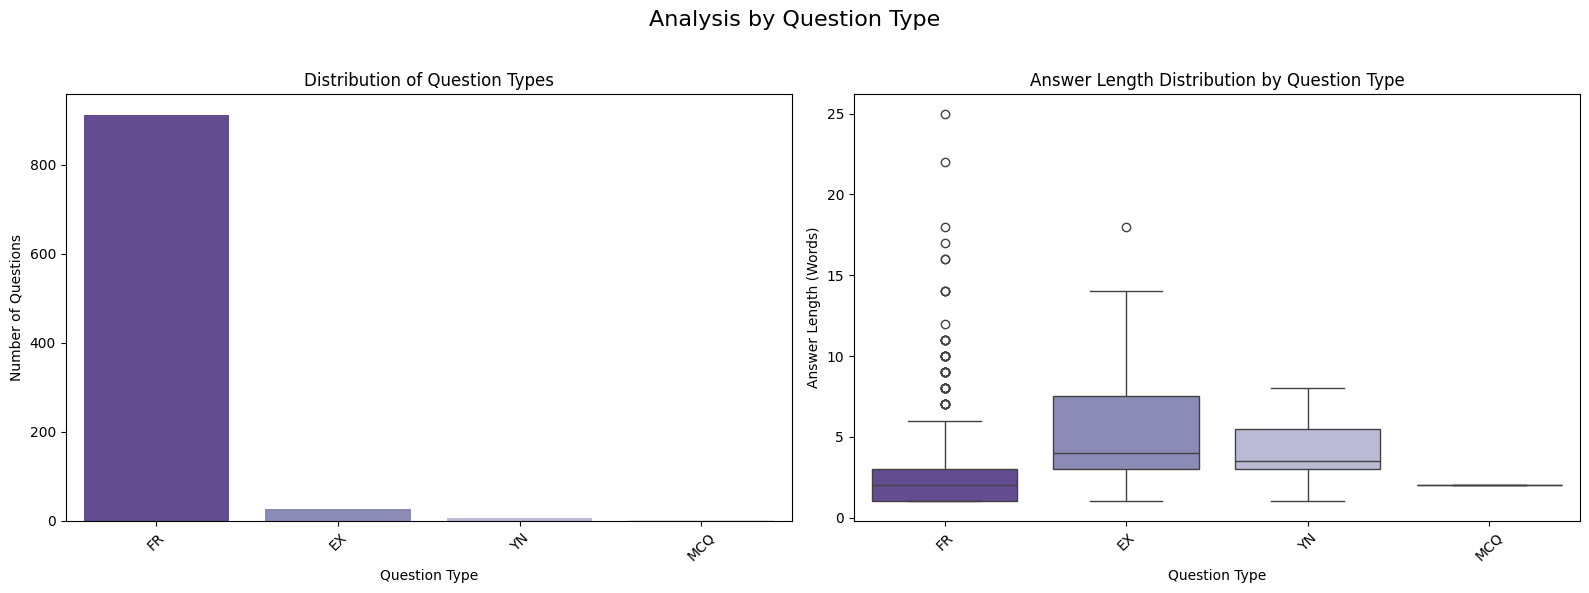


---

In [158]:
original_raw_count = raw_df.shape[0]

# need to add `question_length` and `answer_length` column when running status report without pipeline:
df = df_for_analysis.copy()
df['question_length'] = eda.get_clean_word_counts(df, 'question')
df['answer_length'] = eda.get_clean_word_counts(df, 'answer')

# Generate the status map
eda.generate_dataset_status_report(df, initial_total=original_raw_count)

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 9.6. Data ingestion pipeline to standardize addiion of new questions

### Standardized requirements for new additions to the trivia dataset:


1. The input format should be csv file or pandas data frame.

2. All entries should provide the following information:

| Column Name | Data type |Description |
|--------------------|-----------|-----------------------------------------------------------------------------------------------------------------------------------|
| `question` | str |Full question text with correct formatting and spell check that is within Harry Potter lore |
| `answer` | str |A concise, clear, and correct answer as per Harry Potter lore |
| `question_type` | str| The questions should be of the following types only and should be categorized accordingly: <br> "**FR**" : for Factual Recall <br> "**EX**": Explanatory (open-ended answers)<br> "**YN**": for Yes/No or True/False types <br> "**MCQ**": Multiple choice question |
| `is_numeric_answer`| boolean (True / False)| Tag the question as `True` if the answer is numeric; otherwise, it will be `False`. |
| `force_add_as_duplicate`| boolean (True / False)| **This should be `False`**, *iff* intentionally introducing duplicates or similar questions should be tagged `True` |


3. Perform a quality checks.

    **Questions and answers are in a standardized format**

    **MCQ**: "Question / instruction: a comma separated list of four options to pick from?" A: "One option copied exactly". Example: <br>
        <br>
        "question": "Which is not a broom: Nimbus, Comet, Occamy, Firebolt?" <br>
        "answer": "Occamy" <br>
        "question_type": "MCQ" <br>
        "is_numeric_answer": "False" <br>
        "force_add_as_duplicate": "False" <br>

    **True / False**: " True/False: Question or statement to confirm." A: "True" or "False" - as simple as possible. Example: <br>
        <br>
        "question": "True/False: Harry Potter has a son named James?" <br>
        "answer": "True" <br>
        "question_type": "YN" <br>
        "is_numeric_answer": "False" <br>
        "force_add_as_duplicate": "False" <br>

    **Yes / No**: "Question phrased to elicit a clear yes / no answer" A: "Yes" or "No". Example: <br>
        <br>
        "question": "Do you have to be at least 17 years old and pass a ministry exam to apparate independently?" <br>
        "answer": "Yes" <br>
        "question_type": "YN" <br>
        "is_numeric_answer": "False" <br>
        "force_add_as_duplicate": "False" <br>

    **Numeric answers**: "Question phrased clearly to elicit a numeric answer?" A:"Answer written numerically but of data type `str`" and also make sure flagged as `True` in `is_numeric_answer`. Example: <br>
        <br>
        "question": "How old is Harry for majority of the first book (Harry Potter and the Philosopher's Stone)?" <br>
        "answer": "11" <br>
        "question_type": "FR" <br>
        "is_numeric_answer": "True" <br>
        "force_add_as_duplicate": "False" <br>


    **Check for typos, spelling, grammar, duplicates, missing information, and other mistakes.**<br>
    **Ensure the questions and answers are correct wrt Harry Potter lore.**<br>

4. Process the new questions with the *data ingestion pipeline*. This will add the remaining required columns to match the main dataset. Review and check for warnings. **The `original_question_id` will continue to provide the unique identifier / id for each question. The last step in the "standardizing pipeline" will add new ids for the new questions that do not overlap with the existing dataset and continue from there. It will be filled automatically!**

5. Once satisfied, concatenate to the main trivia dataset."

### Data Ingestion Pipeline process steps
The following outlines the "standardizing pipeline" designed to process new questions, ensure data quality, and add them to the main trivia dataset. This process is built to be robust and repeatable, accommodating new data provided as either a pandas DataFrame or a CSV file. The pipeline follows a "status / payload" return pattern, providing a clear outcome status and relevant data at the end of each run.

#### Pipeline Steps:

1. Input Validation (get_input_df):
    - Confirm the input is either a non-empty pandas DataFrame or a valid, readable CSV file path.
    - If the input is a CSV, convert it to a DataFrame.
    - The pipeline will stop with a LOAD_ERROR status if the input is invalid.

2. Initial Quality Check (validate_new_questions_df):
    - Schema Check: Verify that the DataFrame contains the exact required columns (question, answer, question_type, is_numeric_answer, force_add_as_duplicate) and that their data types are correct, attempting to cast types where appropriate.
    - NaN Handling: Identify any rows containing missing values (NaNs). These rows will be separated and returned in a nan_rows_report and removed from the main processing flow.
    - Internal Duplicates: Remove any rows within the new data batch that are complete duplicates of each other.
    - The pipeline will stop with a VALIDATION_ERROR status if critical schema or type checks fail.

3. Tokenization (create_token_columns):Apply the standardized tokenize_text function to generate token lists for questions and answers, creating the question tokens, answer tokens, and combined_unique_tokens columns.

4. Keyword Tagging (tag_questions_by_keyword_list):Add the interrogative_keyword column by searching the question tokens for words from a master list (e.g., 'what', 'who', 'where', 'when', 'how', 'which', etc.).

5. Duplicate Check Against Main Dataset (check_for_duplicate_questions): This step uses the pre-fitted TF-IDF vectorizer and cosine similarity to check new questions against the existing main dataset. A cross-similarity matrix (N_main x N_new) is calculated between all existing questions and all new questions. For each new question, its maximum similarity score against all existing questions is determined and checked against a tiered threshold system:
    - Bypass: If the new question has a force_add_as_duplicate flag set to True, the similarity check is skipped, and its is_duplicate flag is set to True.
    - Critical Threshold (e.g., >= 0.90): If a new question's max similarity meets this threshold, it is considered a high-confidence duplicate. The pipeline aborts with a CRITICAL_DUPLICATE_ERROR status and returns a report of the problematic questions for manual removal from the input file.
    - Warning Threshold (e.g., 0.70 to < 0.90): If a new question falls into this range, a WARNING is printed, and a needs_manual_review flag is set to True for that question. The pipeline continues.
    - Low Similarity (< 0.70): The question passes the check, and its is_duplicate flag is set to False.

6. Assign New Unique Identifiers: For all new questions that have successfully passed the duplicate check, assign a new, unique original_question_id by finding the maximum ID in the existing main dataset and incrementing from there (max + 1).

7. Final Cleanup & Concatenation:
    - Drop temporary helper columns (like force_add_as_duplicate) from the new questions DataFrame.
    - add the columns for question and answer lengths for the status report.
    - Concatenate the fully processed and validated new questions DataFrame with the main DataFrame.

8. Final Quality Checks & Return:
    - Perform final sanity checks on the newly concatenated main DataFrame (e.g., for NaNs, final shape verification).
    - The pipeline concludes with a SUCCESS status. The returned payload is a dictionary containing the final updated DataFrame ('updated_trivia_dataset') and any relevant reports generated during the run ('nan_rows_report', 'caution_duplicates_review').

This structured process ensures that any new data is consistently formatted, validated for quality, and safely integrated into the main trivia dataset.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

In [159]:
# Add `force_add_as_duplicate` column where are all values are False to meet the standard ingestion schema
new_questions_df['force_add_as_duplicate'] = False
new_questions_df.head()

,question,answer,question_type,is_numeric_answer,force_add_as_duplicate
0,"Which of the following is NOT a form of Transfiguration: Switching, Vanishing, Enchantment, Conjuration.",Enchantment,MCQ,False,False
1,How do you tell if a door is Imperturbable?,Test if it repels objects and sounds,EX,False,False
2,"Which of the following plants is known for its tendency to slap people: Fanged Geranium, Bubotuber, Bouncing Bulbs, Snargaluff?",Bouncing Bulbs,MCQ,False,False
3,"Which of the following is NOT a type of broom? Nimbus, Cleansweep Seven, Occamy, Firebolt.",Occamy,MCQ,False,False
4,"According to the Ministry of Magic's classification system, what type of entity is a Boggart?",Non-being,FR,False,False


#### Add the new multiple choice questions to new_questions_df

In [160]:
# Sanity check 1:
print(f"* Number of records in `new_questions_df` before addition: {new_questions_df.shape[0]}")
print(f"* Number of records in `new_completed_mcq_df` before addition: {new_completed_mcq_df.shape[0]}")

# Add the completed MCQs to the new_questions_df:
new_questions_df = pd.concat([new_questions_df, new_completed_mcq_df], ignore_index=True)

# Sanity check 2:
print(f"\nNumber of questions now in new_questions_df: {new_questions_df.shape[0]}\n")
print("The tail ten rows of the new_questions_df are displayed below:")
display(new_questions_df.tail(5))

* Number of records in `new_questions_df` before addition: 46
* Number of records in `new_completed_mcq_df` before addition: 53

Number of questions now in new_questions_df: 99

The tail ten rows of the new_questions_df are displayed below:


,question,answer,question_type,is_numeric_answer,force_add_as_duplicate
94,"In Harry Potter and the Philosopher's Stone, how many challenges or obstacles protected the Philosopher's Stone: 3, 5, 7, or 10?",7,MCQ,True,False
95,"In wizarding currency, how many Knuts are there in one Sickle: 17, 25, 29, or 31?",29,MCQ,True,False
96,"Albus Dumbledore is famous for discovering how many uses of dragon's blood: 7, 10, 12, or 15?",12,MCQ,True,False
97,"What was the number of the high-security Gringotts vault where the Philosopher's Stone was kept: 687, 711, 713, or 717?",713,MCQ,True,False
98,"How many O.W.L. (Ordinary Wizarding Level) exams did Harry Potter pass: 5, 7, 9, or 10?",7,MCQ,True,False


To ensure the status report runs on the updated main dataframe, it will also need the `question_length` and `answer_length` columns. The Pipeline will add these columns to the new questions during ingestion. 

In [161]:
df_for_analysis['question_length'] = eda.get_clean_word_counts(df_for_analysis, 'question')
df_for_analysis['answer_length'] = eda.get_clean_word_counts(df_for_analysis, 'answer')
df_for_analysis.head(1)

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,interrogative_keyword,is_duplicate,question_type,is_numeric_answer,question_length,answer_length
0,0,What are the three European wizarding schools that participate in the Triwizard Tournament?,"Hogwarts, Beauxbatons, and Durmstrang.","[what, be, three, european, wizarding, school, participate, triwizard, tournament]","[hogwarts, beauxbatons, durmstrang]","[what, be, three, european, wizarding, school, participate, triwizard, tournament, hogwarts, beauxbatons, durmstrang]",[what],False,FR,False,13,4


### 9.6.1. Test Case 1: Input with a High-Confidence Duplicate

First, we will run the pipeline with an input file that contains a new question known to be a duplicate of an existing question in the main dataset. We expect the pipeline to detect this high-similarity match (score >= 0.90) and abort with a `CRITICAL_DUPLICATE_ERROR`.

In [162]:
# Sanity check before adding new questions:
print(f"There are {df_for_analysis.shape[0]} questions in the main dataframe before addition")

## ADD NEW QUESTIONS USING PIPELINE:

# 1. setup the arguments for the pipeline
main_df = df_for_analysis  # not using a copy because that safety step is done within the pipeline. if not sure always better to use a copy.
vectorizer = vectorizer   # NOTE: consider renaming main vectorizer to "global_vectorizer" and refactor accordingly
tokenizer = tokenize_text
critical_threshold=0.90  # Similarity score threshold - at this score and above - questions will be considered duplicates and pipeline will abort
caution_threshold=0.70   # Similarity score threshold - at this score and above (but below critical)- questions will be flagged as near-duplicates, pipeline will continue and provide a df for manually review.

# 2. Run the data ingestion pipeline to add questions from the new_questions_df to the data_for_analysis
status, payload = eda.run_data_ingestion_pipeline(new_questions_input=new_questions_df, 
                                                  main_dataframe=main_df, 
                                                  vectorizer=vectorizer,
                                                  tokenizer=tokenize_text, 
                                                  critical_threshold=0.90, 
                                                  caution_threshold=0.70)

There are 947 questions in the main dataframe before addition
--------------------------------------------------
Baseline: Main Standard Trivia Dataset before data ingestion
* The Main DataFrame size: 947 rows x 12 columns.
--------------------------------------------------
Input is already a valid DataFrame. Proceeding.
INFO: Converted column 'question' to <class 'str'>
INFO: Converted column 'answer' to <class 'str'>
INFO: Converted column 'question_type' to <class 'str'>
--------------------------------------------------
Input Validation Report for New Questions
* New DataFrame size: 99 rows x 5 columns.
* Number of rows with NaNs found: 0. These rows were removed and returned separately.
* Number of duplicate rows found and dropped: 0.
* Final validated DataFrame size: 99 rows x 5 columns.
--------------------------------------------------


CRITICAL ERROR: Pipeline stopped! 1 new question(s) are likely duplicates (score >= 0.9).
  - Refer to the returned 'critical_review_df' for d

In [163]:
# 3. Handle the Pipeline's output based on status
eda.display_pipeline_results(status, payload)


PIPELINE EXECUTION FINISHED WITH STATUS: CRITICAL_DUPLICATE_ERROR


### PIPELINE ABORTED: Critical Duplicates Found

The pipeline was stopped because new questions were found to be too similar to existing questions.
ACTION: Please remove or edit these questions from your input file and re-run the pipeline.


,question,answer,question_type,is_numeric_answer,force_add_as_duplicate,question tokens,answer tokens,combined_unique_tokens,question_length,answer_length,interrogative_keyword,max_similarity_score_TEMP,existing_q_pos_max_score_TEMP,is_duplicate,needs_manual_review_TEMP,existing_original_question_id
39,How many players are on a Quidditch team?,7,FR,True,False,"[how, many, player, be, quidditch, team]",[],"[how, many, player, be, quidditch, team]",8,1,[how],1.0,188,True,True,212


The display logic for the pipeline is useful 

In [169]:
new_q_index = 39
new_questions_df.iloc[new_q_index]

question                  How many players are on a Quidditch team?
answer                                                            7
question_type                                                    FR
is_numeric_answer                                              True
force_add_as_duplicate                                        False
Name: 39, dtype: object

In [170]:
df_for_analysis[df_for_analysis['original_question_id']==212]

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,interrogative_keyword,is_duplicate,question_type,is_numeric_answer,question_length,answer_length
188,212,How many players are on a quidditch team?,7,"[how, many, player, be, quidditch, team]",[],"[how, many, player, be, quidditch, team]",[how],True,FR,False,8,1


In [171]:
# drop question at position 36 in the new_questions_df
new_questions_df = new_questions_df.drop(index=new_q_index)
# sanity check
new_questions_df.iloc[new_q_index-1:new_q_index+2]

,question,answer,question_type,is_numeric_answer,force_add_as_duplicate
38,How many Deathly Hallows did Albus Dumbledore possess?,3,FR,True,False
40,Switching spells simultaneously transfigure how many objects?,2,FR,True,False
41,How long should a Polyjuice Potion stew before usage?,1 Month,FR,True,False


In [172]:
# reset the index for new_questions_df
new_questions_df.reset_index(drop=True, inplace=True)
# sanity check
new_questions_df.iloc[new_q_index-1:new_q_index+2]

,question,answer,question_type,is_numeric_answer,force_add_as_duplicate
38,How many Deathly Hallows did Albus Dumbledore possess?,3,FR,True,False
39,Switching spells simultaneously transfigure how many objects?,2,FR,True,False
40,How long should a Polyjuice Potion stew before usage?,1 Month,FR,True,False


### 9.6.2. Test case 2: correcting input and re-running the pipeline

The pipeline successfully identified the duplicate question. As instructed by the output, the problematic question has been removed from the input file. We will now re-run the pipeline with the corrected input. We expect a `SUCCESS` status this time.

--------------------------------------------------
Baseline: Main Standard Trivia Dataset before data ingestion
* The Main DataFrame size: 947 rows x 12 columns.
--------------------------------------------------
Input is already a valid DataFrame. Proceeding.
INFO: Converted column 'question' to <class 'str'>
INFO: Converted column 'answer' to <class 'str'>
INFO: Converted column 'question_type' to <class 'str'>
--------------------------------------------------
Input Validation Report for New Questions
* New DataFrame size: 98 rows x 5 columns.
* Number of rows with NaNs found: 0. These rows were removed and returned separately.
* Number of duplicate rows found and dropped: 0.
* Final validated DataFrame size: 98 rows x 5 columns.
--------------------------------------------------

 ACTION Recommended: Manual review of `caution_review_df'.
New questions have been added to the main dataframe. There are now 1045 questions in the trivia dataset.

--- Pipeline Completed Successfully ---


## Trivia Dataset Status Map

---

### 1. Key Metrics

**- Total Unique Questions in Final Dataset:** 1045<br>**- Net Change in Questions:** +98<br>   *(Note: A positive number indicates new questions were added; a negative number indicates questions were removed.)*<br>**- Total Questions with Numeric Answers:** 29 (2.8%)<br>


### 2. Breakdown by Question Type

,Question Count,Percentage (%),Unique Answer Count,Median Q Len,Median A Len,Top Answer Keywords,Top Interrogative Keywords,Unassigned Interrogative Keyword
Question Type,,,,,,,,
FR,939,89.9%,832,9.0,2.0,"professor (17), charm (10), weasley (10)","what (514), do (227), who (158)",0
MCQ,68,6.5%,67,19.0,1.5,"charm (4), spell (2), potion (2)","which (58), do (9), how (6)",0
EX,31,3.0%,31,9.0,4.0,"can (2), parseltongue (2), werewolf (2)","do (21), how (19), why (12)",0
YN,7,0.7%,7,7.0,3.0,"yes (4), can (2), true (1)","do (3), can (2), have (1)",2



Note:
Question types: FR (Factual Recall), EX (Explanatory), YN (Yes/No or True/False), MCQ (Multiple Choice Question)



### 3. Visualizations by Question Type

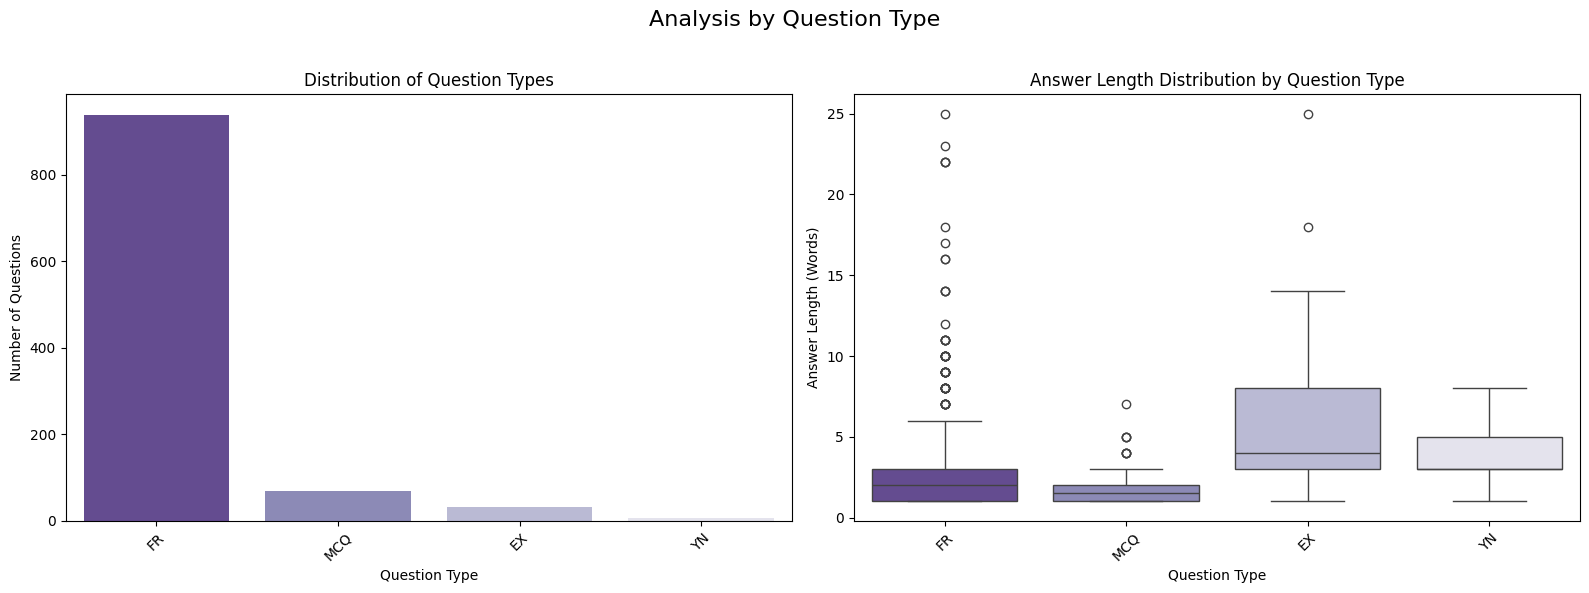


---

In [173]:
# 1. setup the arguments for the pipeline
main_df = df_for_analysis  # not using a copy because that safety step is done within the pipeline. if not sure always better to use a copy.
vectorizer = vectorizer   # NOTE: consider renaming main vectorizer to "global_vectorizer" and refactor accordingly
tokenizer = tokenize_text
critical_threshold=0.90  # Similarity score threshold - at this score and above - questions will be considered duplicates and pipeline will abort
caution_threshold=0.70   # Similarity score threshold - at this score and above (but below critical)- questions will be flagged as near-duplicates, pipeline will continue and provide a df for manually review.

# 2. Run the data ingestion pipeline to add questions from the new_questions_df to the data_for_analysis
status, payload = eda.run_data_ingestion_pipeline(new_questions_input=new_questions_df, 
                                                  main_dataframe=main_df, 
                                                  vectorizer=vectorizer,
                                                  tokenizer=tokenize_text, 
                                                  critical_threshold=0.90, 
                                                  caution_threshold=0.70)


In [174]:
# 3. Handle the Pipeline's output based on status
eda.display_pipeline_results(status, payload)


PIPELINE EXECUTION FINISHED WITH STATUS: SUCCESS


### Pipeline Successful!

The main dataset has been updated. New total questions: 1045


#### The following questions were added but are recommended for manual review:

,question,answer,question_type,is_numeric_answer,force_add_as_duplicate,question tokens,answer tokens,combined_unique_tokens,question_length,answer_length,interrogative_keyword,max_similarity_score_TEMP,existing_q_pos_max_score_TEMP,is_duplicate,needs_manual_review_TEMP,existing_original_question_id
4,"According to the Ministry of Magic's classification system, what type of entity is a Boggart?",Non-being,FR,False,False,"[accord, ministry, magic, classification, system, what, type, entity, be, boggart]",[nonbeing],"[accord, ministry, magic, classification, system, what, type, entity, be, boggart, nonbeing]",16,2,[what],0.719451,392,False,True,450


In [178]:
updated_trivia_df = payload.get('updated_trivia_dataset', pd.DataFrame())
# let's check the corresponding original questions:
original_q_id_to_check= 450
question_text = updated_trivia_df.loc[updated_trivia_df['original_question_id']==original_q_id_to_check, 'question'].values[0]
answer_text = updated_trivia_df.loc[updated_trivia_df['original_question_id']==original_q_id_to_check, 'answer'].values[0]
print(f'ID:{original_q_id_to_check}, Q:"{question_text}", A:"{answer_text}"')

ID:450, Q:"What is the Ministry of Magic classification system?", A:"A creature's danger level"


As expected, both questions are lexically similar but semantically different - they are asking different things even if they share similar words. We can keep both questions and no manual intervention is requied.


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

<div align="center" style="background-color: #f0e6f7; padding: 10px;">
    <span style="color:purple; font-size:32px;">Part 4: Quality assurance and finalization</span>
</div>

# 10. Data quality assurance and finalization

## 10.1. Automated heuristics

1. Readability Scores:
- What: Calculate standard readability scores (e.g., Flesch Reading Ease, Flesch-Kincaid Grade Level) for both the question and answer text columns. Libraries like textstat make this straightforward.
- Why: This gives you a quantitative measure of linguistic complexity. While not a direct measure of correctness or difficulty, very high or very low scores, or large discrepancies between question and answer readability, might flag items for closer inspection during manual review. It adds objective metrics about text complexity.
- Fit for Phase 1: Yes, calculation is simple and fast.

2. Outliers - questions / answers that are very long or very short (could indicate truncated data) etc

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 10.2. Manual review

**Task list:**
1. Delete Q.(1271. Q:"Will you serve the great nation of Peevesland, soldier?" - A:"Sir, yes, sir!")
2. Delete duplicate (Q. 644 & 1228 are identical and missed in earlier cleaning).
3. Edit Q. 667 (Fill in the blank: Petrificus Totalus is the incantation for the Full Body-Bind curse.) -> no missing blanks, (A: Bind (Got this in the Petrificus Totalus lesson.)) --> change to [Q: "Fill in the blank: Petrificus Totalus is the incantation for the full ____-_____ curse." / A:"Body-bind"]
4. Q.230 looks incomplete - need to have a look at question before or after in case if it was somehow split across rows?
5. Q.590 "Who do you prefer: Dust, Binns, or Peeves?" nonsensical - delete.
6. Q.861 "Who is NOT in Slytherin: Lavender Brown, Pansy Parkinson, Blaise Zabini, or Gregory Goyle?" - MC question
7. Q.198 / 921 / 372 / 796 = Multiple choice
8. Q.111 Typo "What is a potion that cause boils *of* brewed incorrectly?" -- should be if.
9. Q.1214 - incomplete multiple choice question
10. Q.742 - "What subject foes Headmistress McGonagall teach?" typo - should be "does" but is a duplicate - matters for NER phase 2.
11.Q.56 "How did I become a metamorphagus?" A"I was born one" - rephrase
12. Q316 "How many presents did Dudley Dursley receive on his birthday in total?" A:"38. It was 36 (one less than last year), but then Mrs. Dursley bought him two new presents to make up for it." -> rephrase to include book(Harry potter and the philosopher's stone) or which birthday (11th) -change answer to "38" only
13. Q490 "What is the first line of the book?" A"“Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you very much.” -> rephrase to include book reference (Book 1, Harry potter and the Philosophers Stone)
14. 992 "How many Horcruxes have been destroyed at the end of this story?" A "Two: the diary and the ring" -> rephrase question to be clear (which book? "Book 6: Harry and the Half-Blood Prince) AND change answer to "2 (the diary and the ring)"

- search for answers with yes, no in them 
- search for answers with numbers 0-9 in text and convert to number-as-string and flag as ans_is_numeric

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 10.3. Status map of the dataset

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

<div align="center" style="background-color: #f0e6f7; padding: 10px;">
    <span style="color:purple; font-size:32px;">Part 5: Dataset preparation for export to CLI-MVP</span>
</div>

# 11. Summmary and key findings

## 11.1. Summary

Answer lengths:
- Majority of the answers are 

- Signifiant analysis and categorization of the questions types was achieved just by tokenizing the question and answers and looking at the question syntax. The trivia dataset follows question pattern of what can typically be expected and could be categorized into question types.
- The vast majority of the questions are factual-recall type (97%).  The answers to factual-recall type questions are relatively simpler to analyze for correctness.
- Of the 97%, majority (49%) of the factual-recall types use 'what' as a keyword to pharse the question. 
- There are other question formats in the dataset as well:
    - True / False or Yes / No -> binary choice
    - Fill in the blank
    - open-ended or explanatory
    - question written as statements
- There were no multiple-choice questions.
- There were also spelling mistakes and problematic (nonsensical) questions that needed to be cleaned. 
- A design decision was made not to modify or remove the uncategorized questions.
- The dataset right now is sufficient for the CLI-MVP.
- However, the data analysis so far has not taken into account 'Harry Potter' specific content. This will be tackled specifically in the next project phase using custom NER classes.

>📝 **Note**: 
> 
>Understanding the dataset's answer diversity by analyzing keyword uniqueness and semantic similarity (e.g., 'Albus' vs 'Dumbledore') is important for assessing content variety and refining the requirements for the player answer semantic comparison logic. This specific dataset analysis will be undertaken in Phase 2, synergistic with NER efforts, allowing the current phase to focus on the MVP's core game loop and initial answer evaluation setup.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 11.2. Key findings

1. 97%+ successful categorization even before NER work - excellent success metric.
2. Similar contextual, "Harry Potter" centric categorization will help enrich the game experience and help make it more immersive.
2. The main distinguishing factor for questions in the dataset is whether they are 'factual-recall' type or not. These question types generally have straight forward answers. Answer comparison with user input should be relatively straight forward for the MVP.
4. When growing the dataset for next phases 
    - can balance the other question type categories (especially open-ended, nuanced questions to make NLP features shine)
    - add multiple choice questions especially for easy mode
    - Can also balance the categories within the 'factual-recall' - this will help with medium / difficult levels.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

<div align="center" style="background-color: #f0e6f7; padding: 10px;">
    <span style="color:purple; font-size:32px;">Part 5: Finalizing dataset for CLI-MVP</span>
</div>

# 12. Data dictionary

1. Data dictionary table
2. Json conversion for the csv

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

# 13. Next steps and data export

The next steps based on the work completed in this notebook:

1. **CLI MVP Input:** <br>
The dataset generated here, containing the cleaned trivia questions/answers and extracted keywords (from the second checkpoint), serves as the primary data source for the current command-line interface (CLI) MVP of the trivia game. 

2.  **Further Feature Enhancement (NER):**<br>
 The next phase of data enrichment involves applying Named Entity Recognition (NER) to potentially classify questions or extract structured information like difficulty and category. This work is planned for the [NER Implementation notebook](03-NER_implementation.ipynb)

 The processed dataset is ready to be exported for the CLI-MVP.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

---

#### 💾 Checkpoint 2: Phase-1 CLI-MVP dataset 

Saving clean dataset with keywords and question type tags
<details>
<summary> Click here for checkpoint details and <b>warning!</b> </summary>

The DataFrame is now cleaned, EDA completed, with the keywords and question-type features columns. Saving the current state.
<br>
> **⚠️ Caution: Manual Intervention Required for Saving Files**
>
> Please be aware that the `save_dataframe_to_csv` utility is designed to prevent accidental data loss. It **does not automatically overwrite** previously saved files.
>
> If you run a cell that calls this function and the output file (based on `filename_base`, `version`, and `subfolder`) already exists, the save operation will be skipped. You will see a message indicating this.
>
> **To save your latest data, you must manually intervene by either:**
> 1.  Deleting the older version of the CSV file from the file system.
> 2.  Modifying the `version` argument (or `filename_base`) in your function call to create a new, unique filename.

The following code saves the cleaned DataFrame to <code>data/project_datasets/</code> based on the selected `Save arguments` in the code below.
</div>
</details>

In [ ]:
# Using utils.paths.py module -> prevents overwritting csv file unless manually done.

# Save arguments
# dataframe_to_save = 
name_for_csvfile = 'CLI-MVP_trivia_dataset'
csv_version = 'v0'
csv_subfolder = 'project_datasets'

# Save csv  file with custom functions and defined save arguments
# up.save_dataframe_to_csv(dataframe_to_save, name_for_csvfile, csv_version, csv_subfolder)

---

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#1-introduction" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Return to the Top</a>

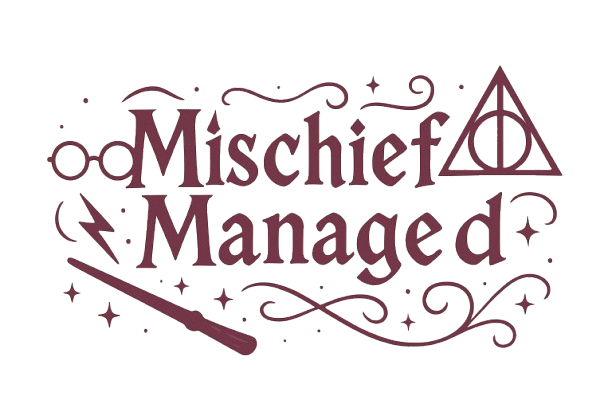